<a href="https://colab.research.google.com/github/amitgupta226571/Failure-Aware/blob/main/TrustNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Mount Google Drive and setup environment
from google.colab import drive
drive.mount('/content/drive')
print("✅ Environment setup complete")

Mounted at /content/drive
✅ Environment setup complete


In [ ]:
# Install required packages
!pip install timm opencv-python scikit-learn matplotlib seaborn tqdm optuna wandb
!pip install grad-cam  # For Grad-CAM
!pip install scipy statsmodels  # For statistical tests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 111.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=d58215918596da2f90cb89e35eddd07493fe8c8b8b757903dca5f19a8066a165
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# # Uninstall current versions
# !pip uninstall torch torchvision torchaudio timm -y

# # Install compatible versions (PyTorch 2.1.0 + timm 0.9.2)
# !pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0
# !pip install timm==0.9.2

In [ ]:
# Cell 2: Import all required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms, datasets
import timm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, roc_curve, auc,
                            roc_auc_score, classification_report)
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from tqdm import tqdm
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import random
from collections import Counter
import warnings
import json
from datetime import datetime
import optuna
import wandb

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("✅ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All libraries imported successfully
PyTorch version: 2.10.0+cu128
CUDA available: True


In [ ]:
# Cell 3: Setup directory structure and configuration
import os
import torch
from datetime import datetime

# Dataset paths
br_root = "/content/drive/MyDrive/Data/Br35H"  # BR35H dataset (Source domain)
btd_root = "/content/drive/MyDrive/Data/Brain Tumor Data"  # BTD dataset (Target domain)

# Results directories with timestamp for better organization
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_dir = "/content/drive/MyDrive/Journal_2nd_paper"
RESULTS_FOLDER = os.path.join(base_dir, f"failure_aware_results_{timestamp}")
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Subdirectories for different analyses
CKPT_DIR = os.path.join(RESULTS_FOLDER, "checkpoints")
TSNE_DIR = os.path.join(RESULTS_FOLDER, "tsne")
GRADCAM_DIR = os.path.join(RESULTS_FOLDER, "gradcam")
FAILURE_DIR = os.path.join(RESULTS_FOLDER, "failure_analysis")
RISK_DIR = os.path.join(RESULTS_FOLDER, "risk_coverage")
PRED_DIR = os.path.join(RESULTS_FOLDER, "predictions")
CONF_MATRIX_DIR = os.path.join(RESULTS_FOLDER, "confusion_matrices")
PLOTS_DIR = os.path.join(RESULTS_FOLDER, "plots")
ABLATION_DIR = os.path.join(RESULTS_FOLDER, "ablation")
STATS_DIR = os.path.join(RESULTS_FOLDER, "statistics")
SPLIT_DIR = os.path.join(base_dir, "dataset_splits")  # NEW: For saving splits

# Create all directories
for d in [CKPT_DIR, TSNE_DIR, GRADCAM_DIR, FAILURE_DIR, RISK_DIR,
          PRED_DIR, CONF_MATRIX_DIR, PLOTS_DIR, ABLATION_DIR,
          STATS_DIR, SPLIT_DIR]:
    os.makedirs(d, exist_ok=True)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Results will be saved to: {RESULTS_FOLDER}")
print(f"✅ Using device: {device}")
print(f"✅ Split directory: {SPLIT_DIR}")

# IMPROVED Configuration dictionary with better defaults for failure learning
config = {
    # Image settings
    'img_size': 224,
    'batch_size': 32,
    'num_workers': 2,

    # Training settings
    'epochs': 30,
    'patience': 15,  # Increased patience for better convergence
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,  # NEW: Added weight decay

    # Loss weights - OPTIMIZED for better failure learning
    'lambda_failure': 1.0,      # Increased from 0.5 - failure head更重要
    'lambda_domain': 0.2,        # Reduced from 0.3 - less emphasis on domain

    # Confidence settings - LOWERED for better uncertainty capture
    'confidence_threshold': 0.6,  # Reduced from 0.8 - more sensitive to uncertainty
    'failure_threshold': 0.5,     # NEW: Threshold for failure prediction

    # Model settings
    'num_classes': 2,
    'num_domains': 2,

    # Optimization settings
    'scheduler_factor': 0.5,      # NEW: LR scheduler factor
    'scheduler_patience': 5,       # NEW: LR scheduler patience
    'grad_clip': 1.0,              # NEW: Gradient clipping value

    # Augmentation settings
    'mixstyle_p': 0.5,             # NEW: MixStyle probability
    'mixstyle_alpha': 0.1,         # NEW: MixStyle alpha

    # Failure head architecture - NEW settings
    'failure_hidden_dim': 512,     # Larger failure head
    'failure_dropout': 0.3,        # Dropout for failure head

    # Dataset info
    'source_domain': 'BR35H',
    'target_domain': 'BTD',
    'random_seed': 42
}

# Print configuration in a nice format
print("\n" + "="*60)
print("📋 CONFIGURATION SETTINGS")
print("="*60)
for key, value in config.items():
    print(f"  {key:25}: {value}")
print("="*60 + "\n")

# Save configuration to file
import json
config_path = os.path.join(RESULTS_FOLDER, "config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"✅ Configuration saved to: {config_path}")

# Optional: Setup WandB for experiment tracking (uncomment if wanted)
# import wandb
# wandb.init(project="failure-aware-domain-gen", config=config)

✅ Results will be saved to: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117
✅ Using device: cuda
✅ Split directory: /content/drive/MyDrive/Journal_2nd_paper/dataset_splits

📋 CONFIGURATION SETTINGS
  img_size                 : 224
  batch_size               : 32
  num_workers              : 2
  epochs                   : 30
  patience                 : 15
  learning_rate            : 0.0001
  weight_decay             : 0.0001
  lambda_failure           : 1.0
  lambda_domain            : 0.2
  confidence_threshold     : 0.6
  failure_threshold        : 0.5
  num_classes              : 2
  num_domains              : 2
  scheduler_factor         : 0.5
  scheduler_patience       : 5
  grad_clip                : 1.0
  mixstyle_p               : 0.5
  mixstyle_alpha           : 0.1
  failure_hidden_dim       : 512
  failure_dropout          : 0.3
  source_domain            : BR35H
  target_domain            : BTD
  random_seed              : 42

✅ Configuration

In [ ]:
# Cell 4: Define data transforms with proper augmentation
img_size = config['img_size']

class Ensure3Channels:
    """Convert grayscale images to RGB"""
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

# Training transforms with augmentation (for source domain)
train_tfms = transforms.Compose([
    Ensure3Channels(),
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (no augmentation)
test_tfms = transforms.Compose([
    Ensure3Channels(),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms defined")

✅ Transforms defined


In [ ]:
# Cell 5: Create domain-aware dataset classes
class DomainAwareDataset(Dataset):
    """
    Dataset that returns images with domain labels
    domain_label: 0 for source (BR35H), 1 for target (BTD)
    """
    def __init__(self, data_dir, transform=None, domain_label=0, is_train=True):
        self.data_dir = data_dir
        self.transform = transform
        self.domain_label = domain_label
        self.is_train = is_train

        # Load dataset using ImageFolder
        self.dataset = datasets.ImageFolder(root=data_dir, transform=transform)

        print(f"Loaded {len(self.dataset)} images from {data_dir}")
        print(f"  Classes: {self.dataset.classes}")
        print(f"  Domain: {'Source' if domain_label==0 else 'Target'}")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return {
            'image': img,
            'label': torch.tensor(label, dtype=torch.long),
            'domain': torch.tensor(self.domain_label, dtype=torch.long),
            'idx': idx
        }


class BinaryBTDDataset(Dataset):
    """
    Convert BTD multi-class to binary classification
    Mapping: glioma(0), meningioma(1) → Tumor(1)
             no_tumor(2) → No Tumor(0)
             pituitary(3) → Tumor(1)
    """
    def __init__(self, original_dataset, transform=None):
        self.original_dataset = original_dataset
        self.transform = transform
        self.mapping = {0: 1, 1: 1, 2: 0, 3: 1}

        # Store binary labels
        self.labels = []
        for idx in range(len(original_dataset)):
            _, label = original_dataset[idx]
            self.labels.append(self.mapping[label])

        print(f"Binary BTD: {Counter(self.labels)}")

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, _ = self.original_dataset[idx]
        binary_label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return {
            'image': img,
            'label': torch.tensor(binary_label, dtype=torch.long),
            'domain': torch.tensor(1, dtype=torch.long),  # Target domain
            'idx': idx
        }

In [ ]:
# Cell 6: Load datasets with PERSISTENT splits + REPRODUCIBLE DataLoaders
# REPRODUCIBILITY FIX: Added generator=g and worker_init_fn to shuffled loaders

import pickle
import os
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Subset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import torch
import random

# ===== REPRODUCIBILITY: Worker init function =====
def seed_worker(worker_id):
    """Seed each DataLoader worker for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# ===== REPRODUCIBILITY: Fixed generator for shuffling =====
g = torch.Generator()
g.manual_seed(42)

# Setup directories
SPLIT_DIR = "/content/drive/MyDrive/Journal_2nd_paper/splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

print("\n" + "="*70)
print("📊 DATASET LOADING WITH PERSISTENT SPLITS + REPRODUCIBLE LOADERS")
print("="*70)

print("\n🔄 Loading BR35H dataset...")
br_full_dataset = DomainAwareDataset(
    data_dir=os.path.join(br_root, "train"),
    transform=train_tfms,
    domain_label=0,
    is_train=True
)

split_file = os.path.join(SPLIT_DIR, "br35h_split.pkl")

if os.path.exists(split_file):
    print(f"\n📂 Loading existing split from {split_file}")
    with open(split_file, 'rb') as f:
        split_data = pickle.load(f)
        train_idx = split_data['train_idx']
        val_idx = split_data['val_idx']
        print(f"   ✅ Loaded split created: {split_data.get('created', 'unknown')}")
        print(f"   Train: {len(train_idx)} images")
        print(f"   Val: {len(val_idx)} images")

        if 'train_class_dist' in split_data:
            print(f"   Train distribution: {split_data['train_class_dist']}")
            print(f"   Val distribution: {split_data['val_class_dist']}")
else:
    print("\n🆕 Creating new stratified split...")

    print("   📋 Collecting labels...")
    labels = [br_full_dataset[i]['label'].item()
              for i in range(len(br_full_dataset))]

    orig_dist = Counter(labels)
    print(f"\n   📊 Original class distribution: {dict(orig_dist)}")
    tumor_ratio = orig_dist[1] / orig_dist[0] if orig_dist[0] > 0 else float('inf')
    print(f"   Tumor:No Tumor ratio = {tumor_ratio:.2f}:1")

    print("\n   🔀 Performing stratified split (80/20)...")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))

    train_labels = [labels[i] for i in train_idx]
    val_labels = [labels[i] for i in val_idx]

    print(f"\n   ✅ Split verification:")
    print(f"      Train - Tumor: {train_labels.count(1)}, No Tumor: {train_labels.count(0)}")
    print(f"      Val   - Tumor: {val_labels.count(1)}, No Tumor: {val_labels.count(0)}")

    split_data = {
        'train_idx': train_idx,
        'val_idx': val_idx,
        'random_state': 42,
        'test_size': 0.2,
        'created': str(datetime.now()),
        'total_size': len(br_full_dataset),
        'orig_class_dist': dict(orig_dist),
        'train_class_dist': dict(Counter(train_labels)),
        'val_class_dist': dict(Counter(val_labels))
    }

    print(f"\n   💾 Saving split to {split_file}")
    with open(split_file, 'wb') as f:
        pickle.dump(split_data, f)
    print(f"   ✅ Split saved successfully")

# Create subsets
train_dataset = Subset(br_full_dataset, train_idx)
val_dataset = Subset(br_full_dataset, val_idx)

# Apply correct transforms
train_dataset.dataset.transform = train_tfms
val_dataset.dataset.transform = test_tfms

print("\n" + "="*70)
print("📊 LOADING TARGET DOMAIN DATASET (BTD)")
print("="*70)

btd_test_original = datasets.ImageFolder(
    root=os.path.join(btd_root, "test"),
    transform=None
)

print(f"\n📂 Original BTD classes: {btd_test_original.classes}")
print(f"   Class to index mapping: {btd_test_original.class_to_idx}")

full_test_dataset = BinaryBTDDataset(
    original_dataset=btd_test_original,
    transform=test_tfms
)

print("\n" + "="*70)
print("🔧 CREATING DANN TARGET LOADER")
print("="*70)

test_labels_full = [full_test_dataset[i]['label'].item() for i in range(len(full_test_dataset))]

dann_indices, eval_indices = train_test_split(
    range(len(full_test_dataset)),
    test_size=0.5,
    stratify=test_labels_full,
    random_state=42
)

print(f"\n   Total test samples: {len(full_test_dataset)}")
print(f"   → DANN target samples: {len(dann_indices)}")
print(f"   → Final test samples: {len(eval_indices)}")

dann_target_dataset = Subset(full_test_dataset, dann_indices)
final_test_dataset = Subset(full_test_dataset, eval_indices)


print("\n" + "="*70)
print("🔨 CREATING REPRODUCIBLE DATA LOADERS")
print("="*70)

# 🆕 REPRODUCIBILITY: generator=g and worker_init_fn on ALL shuffled loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True,
    generator=g,                    # 🆕 Fixed random shuffling
    worker_init_fn=seed_worker      # 🆕 Seed workers
)
print(f"✅ Created train loader: {len(train_loader)} batches (reproducible)")

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True,
    worker_init_fn=seed_worker
)
print(f"✅ Created validation loader: {len(val_loader)} batches")

# 🆕 REPRODUCIBILITY: DANN target loader also needs generator
dann_target_loader = DataLoader(
    dann_target_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True,
    generator=g,                    # 🆕 Fixed random shuffling
    worker_init_fn=seed_worker      # 🆕 Seed workers
)
print(f"✅ Created DANN target loader: {len(dann_target_loader)} batches (reproducible)")

final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True,
    worker_init_fn=seed_worker
)
print(f"✅ Created final test loader: {len(final_test_loader)} batches")


print(f"\n📊 BATCH COUNTS:")
print(f"   Train loader: {len(train_loader)} batches ✓")
print(f"   DANN target loader: {len(dann_target_loader)} batches ✓")
print(f"   Val loader: {len(val_loader)} batches ✓")
print(f"   Final test loader: {len(final_test_loader)} batches ✓")


print("\n" + "="*70)
print("📊 DATASET ANALYSIS & VALIDATION")
print("="*70)
print("\n🔍 Running comprehensive dataset analysis...")

train_labels = [train_dataset[i]['label'].item() for i in range(len(train_dataset))]
val_labels = [val_dataset[i]['label'].item() for i in range(len(val_dataset))]
dann_target_labels = [dann_target_dataset[i]['label'].item() for i in range(len(dann_target_dataset))]
final_test_labels = [final_test_dataset[i]['label'].item() for i in range(len(final_test_dataset))]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
dann_counts = Counter(dann_target_labels)
final_counts = Counter(final_test_labels)

import pandas as pd
summary_data = {
    'Dataset': ['Train (Source)', 'Validation (Source)', 'DANN Target', 'Final Test'],
    'Usage': ['Training + DANN', 'Validation only', 'Domain Adaptation', 'Final Evaluation'],
    'Total': [len(train_labels), len(val_labels), len(dann_target_labels), len(final_test_labels)],
    'No Tumor': [train_counts.get(0, 0), val_counts.get(0, 0), dann_counts.get(0, 0), final_counts.get(0, 0)],
    'Tumor': [train_counts.get(1, 0), val_counts.get(1, 0), dann_counts.get(1, 0), final_counts.get(1, 0)],
    'Tumor %': [
        f"{train_counts.get(1, 0)/len(train_labels)*100:.1f}%",
        f"{val_counts.get(1, 0)/len(val_labels)*100:.1f}%",
        f"{dann_counts.get(1, 0)/len(dann_target_labels)*100:.1f}%",
        f"{final_counts.get(1, 0)/len(final_test_labels)*100:.1f}%"
    ]
}
df_summary = pd.DataFrame(summary_data)
print("\n📈 Dataset Summary:")
print(df_summary.to_string(index=False))

# Calculate class weights
print("\n⚖️ Calculating class weights for training...")
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"   No Tumor (class 0): {class_weights[0]:.4f}")
print(f"   Tumor (class 1): {class_weights[1]:.4f}")

weights_file = os.path.join(SPLIT_DIR, "class_weights.pkl")
with open(weights_file, 'wb') as f:
    pickle.dump({
        'class_weights': class_weights,
        'train_dist': dict(train_counts),
        'val_dist': dict(val_counts),
        'dann_target_dist': dict(dann_counts),
        'final_test_dist': dict(final_counts)
    }, f)
print(f"   ✅ Class weights saved to {weights_file}")

# Dataset health check
print("\n🔍 Dataset Health Check:")
train_ratio = train_counts.get(1, 0) / len(train_labels)
final_ratio = final_counts.get(1, 0) / len(final_test_labels)
if abs(train_ratio - final_ratio) > 0.15:
    print(f"   ⚠️  WARNING: Train ({train_ratio:.2f}) and Final Test ({final_ratio:.2f}) have different distributions")
else:
    print(f"   ✅ Class distributions are consistent")

# Store for later
dataset_info = {
    'train_dataset': train_dataset, 'val_dataset': val_dataset,
    'dann_target_dataset': dann_target_dataset, 'final_test_dataset': final_test_dataset,
    'train_loader': train_loader, 'val_loader': val_loader,
    'dann_target_loader': dann_target_loader, 'final_test_loader': final_test_loader,
    'class_weights': class_weights, 'class_weights_tensor': class_weights_tensor,
}

print(f"\n✅ Dataset preparation complete with REPRODUCIBLE loaders!")
print(f"📁 Split file: {split_file}")
print(f"🔒 All shuffled loaders use generator(seed=42)")




📊 DATASET LOADING WITH PERSISTENT SPLITS + REPRODUCIBLE LOADERS

🔄 Loading BR35H dataset...
Loaded 2400 images from /content/drive/MyDrive/Data/Br35H/train
  Classes: ['no_tumor', 'tumor']
  Domain: Source

📂 Loading existing split from /content/drive/MyDrive/Journal_2nd_paper/splits/br35h_split.pkl
   ✅ Loaded split created: 2026-04-01 18:17:55.052175
   Train: 1920 images
   Val: 480 images
   Train distribution: {1: 960, 0: 960}
   Val distribution: {1: 240, 0: 240}

📊 LOADING TARGET DOMAIN DATASET (BTD)

📂 Original BTD classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
   Class to index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Binary BTD: Counter({1: 906, 0: 405})

🔧 CREATING DANN TARGET LOADER

   Total test samples: 1311
   → DANN target samples: 655
   → Final test samples: 656

🔨 CREATING REPRODUCIBLE DATA LOADERS
✅ Created train loader: 60 batches (reproducible)
✅ Created validation loader: 15 batches
✅ Created DANN target loader: 21 batche

In [ ]:
# Cell 9: Gradient Reversal Layer for Domain-Adversarial Training
class GradientReversalFn(torch.autograd.Function):
    """Gradient Reversal Layer for DANN"""
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.alpha
        return output, None

class GradientReversalLayer(nn.Module):
    """Wrapper for Gradient Reversal Layer"""
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return GradientReversalFn.apply(x, self.alpha)

In [ ]:
# Cell 10: FIXED FailureAwareDANN — timm support + correct build_model signature
# FIXES:
#   1. Uses timm for ALL backbones (consistent with your previous working code)
#   2. build_model() accepts num_domains, use_dann (Cell 20 compatibility)
#   3. Dropout(0.3) in failure head (Round 2)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import timm


class MixStyle(nn.Module):
    """MixStyle for domain generalization"""
    def __init__(self, p=0.5, alpha=0.1, eps=1e-6):
        super().__init__()
        self.p = p
        self.alpha = alpha
        self.eps = eps

    def forward(self, x):
        if not self.training or np.random.random() > self.p:
            return x

        B = x.size(0)
        mu = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True)
        sig = (var + self.eps).sqrt()
        mu, sig = mu.detach(), sig.detach()
        x_normed = (x - mu) / sig

        lmda = torch.distributions.Beta(self.alpha, self.alpha).sample((B, 1, 1, 1)).to(x.device)
        perm = torch.randperm(B)
        mu2, sig2 = mu[perm], sig[perm]
        mu_mix = mu * lmda + mu2 * (1 - lmda)
        sig_mix = sig * lmda + sig2 * (1 - lmda)

        return x_normed * sig_mix + mu_mix


class LayerNormFailureHead(nn.Module):
    """
    Failure head with LayerNorm + Dropout(0.3) for generalization.
    """
    def __init__(self, in_features, dropout_p=0.3):
        super().__init__()
        hidden = in_features // 4

        self.failure_head = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.LayerNorm(hidden),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden // 2),
            nn.LayerNorm(hidden // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_p),
            nn.Linear(hidden // 2, 1)
        )

        self.residual = nn.Linear(in_features, 1)
        self._init_weights()

        print(f"  ✅ LayerNorm failure head initialized:")
        print(f"      • LayerNorm (consistent train/eval behavior)")
        print(f"      • LeakyReLU (0.2) to prevent dead neurons")
        print(f"      • 🆕 Dropout({dropout_p}) for generalization")
        print(f"      • Residual connection for gradient flow")
        print(f"      • Xavier initialization")

    def _init_weights(self):
        for module in self.failure_head:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
        nn.init.xavier_uniform_(self.residual.weight, gain=0.1)
        nn.init.constant_(self.residual.bias, 0.0)

    def forward(self, x):
        return self.failure_head(x) + 0.1 * self.residual(x)


class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None


class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, alpha=1.0):
        return GradientReversalFunction.apply(x, alpha)


class FailureAwareDANN(nn.Module):
    """
    Domain-Adapted Neural Network with Failure-Aware Head.
    Uses timm for ALL backbones (ResNet, DenseNet, EfficientNet, ViT, DeiT, Swin).
    """
    def __init__(self, backbone_name='resnet50', num_classes=2, num_domains=2,
                 pretrained=True, use_mixstyle=True, use_dann=True,
                 failure_dropout=0.3):
        super().__init__()
        self.backbone_name = backbone_name
        self.use_mixstyle = use_mixstyle
        self.use_dann = use_dann

        # Build backbone using timm
        print(f"\n🔧 Building model with backbone: {backbone_name}")
        self.backbone, num_features = self._build_backbone(backbone_name, pretrained)
        self.num_features = num_features
        print(f"  📊 Using num_features: {num_features}")

        # MixStyle (only for CNN backbones)
        if use_mixstyle:
            self.mixstyle = MixStyle(p=0.5, alpha=0.1)
            self._insert_mixstyle()

        # Classification head
        self.cls_head = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes)
        )
        print(f"  ✅ Classification head: {num_features} → 1024 → {num_classes}")

        # Failure head (with dropout for generalization)
        self.failure_head = LayerNormFailureHead(num_features, dropout_p=failure_dropout)

        # Domain classifier (DANN)
        if use_dann:
            self.grl = GradientReversalLayer()
            self.domain_classifier = nn.Sequential(
                nn.Linear(num_features, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_domains)
            )
            print(f"  ✅ Domain classifier: {num_features} → 256 → {num_domains}")
        else:
            self.grl = None
            self.domain_classifier = None
            print(f"  ⚠️ DANN disabled")

        total_params = sum(p.numel() for p in self.parameters())
        print(f"  ✅ Total parameters: {total_params:,}")

    def _build_backbone(self, name, pretrained):
        """Build backbone using timm (supports ALL architectures)"""
        print(f"  🔄 Loading timm model: {name}")
        model = timm.create_model(name, pretrained=pretrained, num_classes=0)

        # Detect feature dimension
        num_features = model.num_features
        print(f"  ✅ Detected feature dimension: {num_features}")

        return model, num_features

    def _insert_mixstyle(self):
        """Insert MixStyle into early layers (CNN backbones only)"""
        if 'resnet' in self.backbone_name:
            if hasattr(self.backbone, 'layer1'):
                original_layer1 = self.backbone.layer1
                self.backbone.layer1 = nn.Sequential(original_layer1, self.mixstyle)
                print(f"  ✅ Added MixStyle to ResNet layer1")
            else:
                print(f"  ⚠️ ResNet layer1 not found, MixStyle skipped")
        elif 'densenet' in self.backbone_name:
            if hasattr(self.backbone, 'features') and hasattr(self.backbone.features, 'denseblock1'):
                original_block = self.backbone.features.denseblock1
                self.backbone.features.denseblock1 = nn.Sequential(original_block, self.mixstyle)
                print(f"  ✅ Added MixStyle to DenseNet block1")
            else:
                print(f"  ⚠️ DenseNet block1 not found, MixStyle skipped")
        elif 'efficientnet' in self.backbone_name:
            if hasattr(self.backbone, 'blocks') and len(self.backbone.blocks) > 0:
                original_block = self.backbone.blocks[0]
                self.backbone.blocks[0] = nn.Sequential(original_block, self.mixstyle)
                print(f"  ✅ Added MixStyle to EfficientNet blocks[0]")
            elif hasattr(self.backbone, 'features') and len(self.backbone.features) > 0:
                original_feat = self.backbone.features[0]
                self.backbone.features[0] = nn.Sequential(original_feat, self.mixstyle)
                print(f"  ✅ Added MixStyle to EfficientNet features[0]")
            else:
                print(f"  ⚠️ EfficientNet blocks not found, MixStyle skipped")
        elif 'vit' in self.backbone_name or 'deit' in self.backbone_name or 'swin' in self.backbone_name:
            # Transformers don't use MixStyle (no spatial feature maps)
            print(f"  ℹ️ MixStyle not applicable for transformer ({self.backbone_name}), skipped")
        else:
            print(f"  ⚠️ MixStyle insertion not implemented for {self.backbone_name}")

    def extract_features(self, x):
        """Extract features from backbone"""
        return self.backbone(x)

    def forward(self, x, alpha=1.0, return_features=False, return_domain=False):
        features = self.extract_features(x)

        class_logits = self.cls_head(features)
        failure_logits = self.failure_head(features)

        outputs = {
            'class_logits': class_logits,
            'failure_logits': failure_logits,
            'features': features if return_features else None
        }

        if return_domain and self.domain_classifier is not None:
            reversed_features = self.grl(features, alpha)
            domain_logits = self.domain_classifier(reversed_features)
            outputs['domain_logits'] = domain_logits
        else:
            outputs['domain_logits'] = None

        return outputs

    def get_name(self):
        name = self.backbone_name
        if self.use_mixstyle:
            name += '_mixstyle'
        if self.use_dann:
            name += '_dann'
        return name


def build_model(backbone_name, num_classes=2, num_domains=2, pretrained=True,
                use_mixstyle=True, use_dann=True, failure_dropout=0.3):
    """Build a FailureAwareDANN model (compatible with Cell 20)"""
    model = FailureAwareDANN(
        backbone_name=backbone_name,
        num_classes=num_classes,
        num_domains=num_domains,
        pretrained=pretrained,
        use_mixstyle=use_mixstyle,
        use_dann=use_dann,
        failure_dropout=failure_dropout
    )
    return model



In [ ]:
# Diagnostic Cell - Run after updating Cell 10.5
print("="*60)
print("🔍 VERIFYING MODEL ARCHITECTURE FIX")
print("="*60)

# Test with ResNet50
test_model = FailureAwareDANN(
    backbone_name='resnet50',
    num_classes=2,
    pretrained=True,
    use_mixstyle=True

)

# Create dummy input
dummy_input = torch.randn(2, 3, 224, 224)

# Forward pass test
with torch.no_grad():
    outputs = test_model(dummy_input, alpha=1.0, return_domain=True)

print(f"\n✅ Forward pass successful!")
print(f"  • Input shape: {dummy_input.shape}")
print(f"  • Class logits shape: {outputs['class_logits'].shape} (should be 2x2)")
print(f"  • Failure logits shape: {outputs['failure_logits'].shape} (should be 2x1)")
print(f"  • Domain logits shape: {outputs['domain_logits'].shape} (should be 2x2)")

if outputs['class_logits'].shape == (2, 2):
    print("\n✅ FIX WORKED! Shape mismatch resolved.")
else:
    print("\n❌ Still having issues. Check the implementation.")

🔍 VERIFYING MODEL ARCHITECTURE FIX

🔧 Building model with backbone: resnet50
  🔄 Loading timm model: resnet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  ✅ Detected feature dimension: 2048
  📊 Using num_features: 2048
  ✅ Added MixStyle to ResNet layer1
  ✅ Classification head: 2048 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initialization
  ✅ Domain classifier: 2048 → 256 → 2
  ✅ Total parameters: 27,320,134

✅ Forward pass successful!
  • Input shape: torch.Size([2, 3, 224, 224])
  • Class logits shape: torch.Size([2, 2]) (should be 2x2)
  • Failure logits shape: torch.Size([2, 1]) (should be 2x1)
  • Domain logits shape: torch.Size([2, 2]) (should be 2x2)

✅ FIX WORKED! Shape mismatch resolved.


In [ ]:
# Cell 11: UPDATED Adaptive Failure Loss — Round 2
# ROUND 2 CHANGES:
#   1. Label smoothing (0.1) on failure targets → prevents overconfident predictions
#   2. Softer boundaries: correct ≤ 0.35 (was 0.3), incorrect ≥ 0.65 (was 0.7)
#   3. Keeps margin loss from Round 1

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from collections import Counter


class AdaptiveFailureLoss(nn.Module):
    """
    ROUND 2: Adds label smoothing to prevent failure head from memorizing
    training errors. Combined with dropout in the head itself, this forces
    the failure head to learn generalizable uncertainty patterns.
    """

    def __init__(self, num_classes=2, class_weights=None,
                 tumor_boost=1.5, confidence_threshold=0.6,
                 diversity_weight=0.5, lambda_failure=3.0, lambda_domain=0.2,
                 margin=0.15, margin_weight=5.0, label_smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.diversity_weight = diversity_weight
        self.lambda_failure = lambda_failure
        self.lambda_domain = lambda_domain
        self.margin = margin
        self.margin_weight = margin_weight
        self.label_smoothing = label_smoothing  # 🆕 Round 2

        # Class weights for imbalanced data
        if class_weights is not None:
            if isinstance(class_weights, torch.Tensor):
                self.class_weights = class_weights
            else:
                self.class_weights = torch.tensor(class_weights, dtype=torch.float32)
            print(f"⚖️ Using class weights: {self.class_weights.cpu().numpy()}")
        else:
            w_no_tumor = 1.0 / tumor_boost
            w_tumor = tumor_boost / (1 + tumor_boost) * 2
            self.class_weights = torch.tensor([w_no_tumor, w_tumor], dtype=torch.float32)
            print(f"⚖️ Class weights: No Tumor={w_no_tumor:.3f}, Tumor={w_tumor:.3f} (boost={tumor_boost}x)")
            print(f"⚖️ Using class weights: {self.class_weights.numpy()}")

        # Domain loss criterion
        self.domain_criterion = nn.CrossEntropyLoss()

        # Running statistics
        self.register_buffer('running_mean', torch.tensor(0.5))
        self.register_buffer('running_std', torch.tensor(0.15))
        self.momentum = 0.99
        self.register_buffer('saturation_count', torch.tensor(0.0))
        self.register_buffer('batch_count', torch.tensor(0.0))
        self.mean_history = []
        self.std_history = []

        print(f"\n✅ Loss initialized with UNCERTAINTY + MARGIN + SMOOTHING:")
        print(f"  • Target = (1 - confidence) + 0.5 × incorrect")
        print(f"  • Incorrect forced ≥ 0.65, Correct+confident ≤ 0.35")
        print(f"  • MARGIN LOSS: incorrect_mean - correct_mean ≥ {margin}")
        print(f"  • Margin weight: {margin_weight}")
        print(f"  • 🆕 Label smoothing: {label_smoothing}")
        print(f"  • Diversity weight: {diversity_weight}")
        print(f"  • λ_failure={lambda_failure}, λ_domain={lambda_domain}")

    def generate_failure_labels(self, probs, labels):
        """
        Generate failure labels with label smoothing for better generalization.
        """
        with torch.no_grad():
            preds = torch.argmax(probs, dim=1)
            confidence = torch.max(probs, dim=1)[0]

            # Core: uncertainty
            uncertainty = 1.0 - confidence

            # Boost incorrect predictions
            incorrect = (preds != labels).float()
            target = uncertainty + incorrect * 0.5

            # Softer boundaries (Round 2: less extreme clipping)
            target = torch.where(
                incorrect == 1,
                torch.maximum(target, torch.tensor(0.65, device=probs.device)),
                target
            )

            correct_confident = (~incorrect.bool()) & (confidence > 0.8)
            target = torch.where(
                correct_confident,
                torch.minimum(target, torch.tensor(0.35, device=probs.device)),
                target
            )

            target = torch.clamp(target, 0.0, 1.0)

            # 🆕 Label smoothing: push targets toward 0.5 slightly
            # This prevents the failure head from being overconfident
            # on training samples (key for generalization)
            if self.label_smoothing > 0:
                target = target * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing

        return target

    def forward(self, outputs, labels, domains=None, is_training=True):
        device = labels.device

        class_logits = outputs['class_logits']
        failure_logits = outputs['failure_logits']

        # 1. Classification loss
        weights = self.class_weights.to(device)
        class_loss = F.cross_entropy(class_logits, labels, weight=weights)

        # 2. Get probabilities
        probs_detached = torch.softmax(class_logits.detach(), dim=1)

        # 3. Failure targets (with label smoothing)
        failure_targets = self.generate_failure_labels(probs_detached, labels)
        failure_targets = failure_targets.unsqueeze(1)

        # 4. Failure prediction loss
        failure_loss = F.binary_cross_entropy_with_logits(
            failure_logits, failure_targets
        )

        # 5. Diversity regularization
        failure_probs = torch.sigmoid(failure_logits)
        failure_std = failure_probs.std()
        diversity_reg = -torch.log(failure_std + 1e-6)

        # 6. Margin-based separation loss
        with torch.no_grad():
            preds = torch.argmax(probs_detached, dim=1)
            correct_mask = (preds == labels).float()
            incorrect_mask = 1.0 - correct_mask

        if incorrect_mask.sum() > 0 and correct_mask.sum() > 0:
            failure_probs_flat = failure_probs.squeeze()
            correct_mean = (failure_probs_flat * correct_mask).sum() / correct_mask.sum()
            incorrect_mean = (failure_probs_flat * incorrect_mask).sum() / incorrect_mask.sum()
            margin_loss = F.relu(self.margin - (incorrect_mean - correct_mean))
        else:
            margin_loss = torch.tensor(0.0, device=device)

        # 7. Total failure loss
        total_failure_loss = (
            failure_loss
            + self.diversity_weight * diversity_reg
            + self.margin_weight * margin_loss
        )

        # 8. Combined loss
        total_loss = class_loss + self.lambda_failure * total_failure_loss

        # 9. Domain loss
        domain_loss = torch.tensor(0.0, device=device)
        if domains is not None and 'domain_logits' in outputs and outputs['domain_logits'] is not None:
            domain_loss = self.domain_criterion(outputs['domain_logits'], domains)
            total_loss += self.lambda_domain * domain_loss

        # 10. Monitoring
        current_std_val = failure_std.item()
        current_mean_val = failure_probs.mean().item()
        margin_loss_val = margin_loss.item() if torch.is_tensor(margin_loss) else margin_loss

        with torch.no_grad():
            is_incorrect = (torch.argmax(probs_detached, dim=1) != labels)
            if is_incorrect.any() and (~is_incorrect).any():
                incorrect_mean_val = failure_probs[is_incorrect].mean().item()
                correct_mean_val = failure_probs[~is_incorrect].mean().item()
                separation = incorrect_mean_val - correct_mean_val
            else:
                incorrect_mean_val = 0
                correct_mean_val = current_mean_val
                separation = 0

        if is_training:
            with torch.no_grad():
                self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * current_mean_val
                self.running_std = self.momentum * self.running_std + (1 - self.momentum) * current_std_val
                self.batch_count += 1.0
                self.mean_history.append(current_mean_val)
                self.std_history.append(current_std_val)
                if len(self.mean_history) > 200:
                    self.mean_history = self.mean_history[-100:]
                    self.std_history = self.std_history[-100:]
                if current_std_val < 0.05:
                    self.saturation_count += 1.0
                else:
                    self.saturation_count = torch.max(self.saturation_count - 1.0, torch.tensor(0.0))
                if separation < -0.1 and self.batch_count % 10 == 0:
                    print(f"\n⚠️ REVERSED DIRECTION: incorrect={incorrect_mean_val:.4f} < correct={correct_mean_val:.4f}")
                if separation > 0.2 and self.batch_count % 50 == 0:
                    print(f"\n✅ CORRECT DIRECTION: incorrect={incorrect_mean_val:.4f} > correct={correct_mean_val:.4f} (sep={separation:.4f})")

        losses_dict = {
            'class': class_loss.item(),
            'failure': total_failure_loss.item(),
            'domain': domain_loss.item(),
            'failure_std': current_std_val,
            'failure_mean': current_mean_val,
            'incorrect_mean': incorrect_mean_val,
            'correct_mean': correct_mean_val,
            'separation': separation,
            'margin_loss': margin_loss_val,
        }

        return total_loss, losses_dict

    def get_health_report(self):
        report = f"\n📊 FAILURE HEAD HEALTH REPORT"
        report += f"\n{'='*40}"
        running_mean_val = self.running_mean.item()
        running_std_val = self.running_std.item()
        saturation_count_val = self.saturation_count.item()
        batch_count_val = self.batch_count.item()
        report += f"\nCurrent Status:"
        report += f"\n  • Mean: {running_mean_val:.4f}"
        report += f"\n  • Std:  {running_std_val:.4f}"
        if len(self.mean_history) > 0:
            recent_mean = sum(self.mean_history[-50:]) / min(len(self.mean_history), 50)
            recent_std = sum(self.std_history[-50:]) / min(len(self.std_history), 50)
            report += f"\n  • Running Std: {running_std_val:.4f}"
            report += f"\n  • Saturation Count: {int(saturation_count_val)}"
            report += f"\n  • Batches Processed: {int(batch_count_val)}"
            report += f"\n\nRecent History (last 50 batches):"
            report += f"\n  • Avg Mean: {recent_mean:.4f}"
            report += f"\n  • Avg Std:  {recent_std:.4f}"
        report += f"\n\nHealth Assessment:"
        if running_std_val > 0.12:
            report += f"\n  ✅ EXCELLENT: Good diversity"
        elif running_std_val > 0.08:
            report += f"\n  ✅ HEALTHY: Good diversity"
        elif running_std_val > 0.04:
            report += f"\n  ⚠️ WARNING: Moderate saturation risk"
        else:
            report += f"\n  ❌ CRITICAL: High saturation risk"
        return report


# ===== Helper function to calculate class weights =====
def calculate_class_weights(dataset, device, tumor_boost=1.5):
    from collections import Counter
    # FIX: Handle different dataset types properly
    if hasattr(dataset, 'dataset') and hasattr(dataset, 'indices'):
        # Subset dataset
        labels = [dataset.dataset[i]['label'].item() for i in dataset.indices]
    elif hasattr(dataset, 'dataset') and not hasattr(dataset, 'indices'):
        # DomainAwareDataset or similar
        labels = [dataset[i]['label'].item() for i in range(len(dataset))]
    else:
        # Direct dataset
        labels = [dataset[i]['label'].item() for i in range(len(dataset))]

    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
    original = weights_tensor.clone()
    weights_tensor[1] = weights_tensor[1] * tumor_boost
    weights_tensor[0] = weights_tensor[0] / tumor_boost
    class_counts = Counter(labels)
    total_samples = len(labels)
    print(f"\n📊 Class Distribution:")
    print(f"  Class 0 (No Tumor): {class_counts.get(0, 0)} samples ({class_counts.get(0, 0)/total_samples*100:.1f}%)")
    print(f"  Class 1 (Tumor):    {class_counts.get(1, 0)} samples ({class_counts.get(1, 0)/total_samples*100:.1f}%)")
    print(f"  Ratio (Tumor:No Tumor): {class_counts.get(1, 0)/class_counts.get(0, 1):.2f}:1")
    print(f"\n⚖️ Class Weight Adjustment:")
    print(f"  Original: No Tumor={original[0].item():.3f}, Tumor={original[1].item():.3f}")
    print(f"  Enhanced: No Tumor={weights_tensor[0].item():.3f}, Tumor={weights_tensor[1].item():.3f}")
    print(f"  Tumor emphasis factor: {tumor_boost}x")
    return weights_tensor


# ===== Initialize loss function =====
print("\n" + "="*60)
print("🔧 Initializing UPDATED Failure-Aware Loss (Round 2)")
print("="*60)

# FIX: Try to get train_dataset from dataset_info if it exists
train_dataset_for_loss = None
try:
    if 'dataset_info' in dir() and dataset_info is not None:
        train_dataset_for_loss = dataset_info.get('train_dataset', None)
    elif 'train_dataset' in dir():
        train_dataset_for_loss = train_dataset
    else:
        train_dataset_for_loss = None
except NameError:
    train_dataset_for_loss = None

if train_dataset_for_loss is not None:
    try:
        class_weights = calculate_class_weights(train_dataset_for_loss, device, tumor_boost=1.5)
        adaptive_loss_fn = AdaptiveFailureLoss(
            num_classes=2,
            class_weights=class_weights,
            confidence_threshold=0.6,
            diversity_weight=0.5,
            lambda_failure=3.0,
            lambda_domain=0.2,
            margin=0.15,
            margin_weight=5.0,
            label_smoothing=0.1       # 🆕 Round 2
        )
        print("\n✅ Adaptive loss initialized successfully!")
    except Exception as e:
        print(f"\n⚠️ Error calculating class weights: {e}")
        print("   Using default class weights...")
        adaptive_loss_fn = AdaptiveFailureLoss(
            num_classes=2,
            class_weights=None,
            tumor_boost=1.5,
            confidence_threshold=0.6,
            diversity_weight=0.5,
            lambda_failure=3.0,
            lambda_domain=0.2,
            margin=0.15,
            margin_weight=5.0,
            label_smoothing=0.1
        )
else:
    print("\n⚠️ train_dataset not defined. Run Cell 6 first.")
    print("   Using default class weights...")
    adaptive_loss_fn = AdaptiveFailureLoss(
        num_classes=2,
        class_weights=None,
        tumor_boost=1.5,
        confidence_threshold=0.6,
        diversity_weight=0.5,
        lambda_failure=3.0,
        lambda_domain=0.2,
        margin=0.15,
        margin_weight=5.0,
        label_smoothing=0.1
    )

# Store the loss function in a dictionary for later access
loss_functions = {
    'adaptive_loss_fn': adaptive_loss_fn
}
print("\n✅ Loss function stored in 'loss_functions' dictionary")


🔧 Initializing UPDATED Failure-Aware Loss (Round 2)

📊 Class Distribution:
  Class 0 (No Tumor): 960 samples (50.0%)
  Class 1 (Tumor):    960 samples (50.0%)
  Ratio (Tumor:No Tumor): 1.00:1

⚖️ Class Weight Adjustment:
  Original: No Tumor=1.000, Tumor=1.000
  Enhanced: No Tumor=0.667, Tumor=1.500
  Tumor emphasis factor: 1.5x
⚖️ Using class weights: [0.6666667 1.5      ]

✅ Loss initialized with UNCERTAINTY + MARGIN + SMOOTHING:
  • Target = (1 - confidence) + 0.5 × incorrect
  • Incorrect forced ≥ 0.65, Correct+confident ≤ 0.35
  • MARGIN LOSS: incorrect_mean - correct_mean ≥ 0.15
  • Margin weight: 5.0
  • 🆕 Label smoothing: 0.1
  • Diversity weight: 0.5
  • λ_failure=3.0, λ_domain=0.2

✅ Adaptive loss initialized successfully!

✅ Loss function stored in 'loss_functions' dictionary


In [ ]:
# Cell 13: Training Loop — Round 3 (Reproducibility + Round 2 Failure Fixes)
# ⚠️ DELETE Cell 12 — it defines a conflicting train_epoch_dann with single optimizer
#
# ROUND 3 CHANGES:
#   1. set_seed(42) at start of train_model for reproducibility
#   2. Checkpoint saves optimizer states + full config + timestamp
#   3. Phase 2 also seeds for consistency
# ROUND 2 CHANGES PRESERVED:
#   - Dual optimizers (10x failure LR)
#   - Phase 2 uses target domain data
#   - Label smoothing passthrough

from torch.utils.data import Subset, ConcatDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import torch.optim as optim
import os
import random
from datetime import datetime


def calculate_class_weights(dataset, device):
    if isinstance(dataset, Subset):
        labels = [dataset.dataset[i]['label'].item() for i in dataset.indices]
    else:
        labels = [dataset[i]['label'].item() for i in range(len(dataset))]
    class_weights = compute_class_weight(
        'balanced', classes=np.unique(labels), y=labels
    )
    return torch.tensor(class_weights, dtype=torch.float32).to(device)


def train_epoch_dann(model, source_loader, target_loader, optimizer_main,
                     optimizer_failure, loss_fn, device, epoch, num_epochs,
                     alpha_schedule=True):
    """Training epoch with TWO optimizers (Round 2)"""
    model.train()

    if alpha_schedule:
        progress = epoch / num_epochs
        alpha = 2.0 / (1.0 + np.exp(-10 * progress)) - 1.0
    else:
        alpha = 1.0

    running_losses = {'total': 0, 'class': 0, 'failure': 0, 'domain': 0}
    running_failure_std = 0.0
    running_failure_mean = 0.0
    running_separation = 0.0
    running_incorrect_mean = 0.0
    running_correct_mean = 0.0
    running_margin_loss = 0.0

    all_preds = []
    all_labels = []
    all_failure_scores = []

    source_iter = iter(source_loader)
    target_iter = iter(target_loader)
    num_batches = len(source_loader)
    pbar = tqdm(range(num_batches), desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch_idx in pbar:
        try:
            source_batch = next(source_iter)
        except StopIteration:
            source_iter = iter(source_loader)
            source_batch = next(source_iter)

        try:
            target_batch = next(target_iter)
        except StopIteration:
            target_iter = iter(target_loader)
            target_batch = next(target_iter)

        source_images = source_batch['image'].to(device)
        source_labels = source_batch['label'].to(device)
        source_domains = source_batch['domain'].to(device)
        target_images = target_batch['image'].to(device)
        target_domains = target_batch['domain'].to(device)

        optimizer_main.zero_grad()
        optimizer_failure.zero_grad()

        source_outputs = model(source_images, alpha=alpha, return_domain=True)
        source_loss, source_losses = loss_fn(
            source_outputs, source_labels, domains=source_domains, is_training=True
        )

        target_outputs = model(target_images, alpha=alpha, return_domain=True)
        target_domain_loss = loss_fn.domain_criterion(
            target_outputs['domain_logits'], target_domains
        )

        total_loss = source_loss + loss_fn.lambda_domain * target_domain_loss
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer_main.step()
        optimizer_failure.step()

        running_losses['total'] += total_loss.item()
        running_losses['class'] += source_losses['class']
        running_losses['failure'] += source_losses.get('failure', 0)
        running_losses['domain'] += source_losses.get('domain', 0) + target_domain_loss.item()
        running_failure_std += source_losses.get('failure_std', 0)
        running_failure_mean += source_losses.get('failure_mean', 0)
        running_incorrect_mean += source_losses.get('incorrect_mean', 0)
        running_correct_mean += source_losses.get('correct_mean', 0)
        running_separation += source_losses.get('separation', 0)
        running_margin_loss += source_losses.get('margin_loss', 0)

        preds = torch.argmax(source_outputs['class_logits'], dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(source_labels.cpu().numpy())
        all_failure_scores.extend(
            torch.sigmoid(source_outputs['failure_logits']).detach().cpu().numpy()
        )

        postfix = {
            'loss': f"{total_loss.item():.4f}",
            'acc': f"{(preds == source_labels).float().mean().item():.4f}",
            'alpha': f"{alpha:.3f}",
            'steps': f"{batch_idx+1}/{num_batches}"
        }
        if source_losses.get('separation', 0) != 0:
            postfix['sep'] = f"{source_losses['separation']:.3f}"
        if source_losses.get('margin_loss', 0) > 0:
            postfix['mg'] = f"{source_losses['margin_loss']:.3f}"
        pbar.set_postfix(postfix)

    num_batches_actual = batch_idx + 1
    epoch_losses = {k: v / num_batches_actual for k, v in running_losses.items()}
    epoch_losses['failure_std'] = running_failure_std / num_batches_actual
    epoch_losses['failure_mean'] = running_failure_mean / num_batches_actual
    epoch_losses['incorrect_mean'] = running_incorrect_mean / num_batches_actual
    epoch_losses['correct_mean'] = running_correct_mean / num_batches_actual
    epoch_losses['separation'] = running_separation / num_batches_actual
    epoch_losses['margin_loss'] = running_margin_loss / num_batches_actual
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_losses, epoch_acc, alpha


def validate(model, loader, loss_fn, device, return_predictions=False):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_confidences = []
    all_features = []
    all_failure_scores = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating"):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            domains = batch['domain'].to(device)

            outputs = model(images, alpha=0, return_features=True)
            loss, _ = loss_fn(outputs, labels, domains=domains, is_training=False)
            total_loss += loss.item()

            probs = torch.softmax(outputs['class_logits'], dim=1)
            conf, preds = probs.max(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(conf.cpu().numpy())
            all_features.extend(outputs['features'].cpu().numpy())
            all_failure_scores.extend(
                torch.sigmoid(outputs['failure_logits']).squeeze().cpu().numpy()
            )

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    if return_predictions:
        return avg_loss, acc, np.array(all_preds), np.array(all_labels), \
               np.array(all_confidences), np.array(all_features), np.array(all_failure_scores)
    return avg_loss, acc


def phase2_failure_finetune(model, source_loader, target_loader, loss_fn, device,
                            epochs=5, lr=5e-4):
    """
    Phase 2: Fine-tune failure head using BOTH source + target data.
    """
    print(f"\n{'='*60}")
    print(f"🔧 Phase 2: Fine-tuning failure head (backbone frozen)")
    print(f"   Using BOTH source + target domain data")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}, LR: {lr}")

    # Freeze backbone and classifier
    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.cls_head.parameters():
        param.requires_grad = False
    if hasattr(model, 'domain_classifier') and model.domain_classifier is not None:
        for param in model.domain_classifier.parameters():
            param.requires_grad = False

    for param in model.failure_head.parameters():
        param.requires_grad = True

    optimizer_p2 = torch.optim.AdamW(
        model.failure_head.parameters(), lr=lr, weight_decay=0.01
    )
    scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=epochs)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_sep = 0
        total_margin = 0
        n_batches = 0

        source_iter = iter(source_loader)
        target_iter = iter(target_loader)
        num_steps = len(source_loader)

        for step in tqdm(range(num_steps), desc=f"Phase 2 Epoch {epoch+1}/{epochs}"):
            try:
                source_batch = next(source_iter)
            except StopIteration:
                source_iter = iter(source_loader)
                source_batch = next(source_iter)

            source_images = source_batch['image'].to(device)
            source_labels = source_batch['label'].to(device)

            with torch.no_grad():
                src_feats = model.extract_features(source_images)
                src_class_logits = model.cls_head(src_feats)

            src_failure_logits = model.failure_head(src_feats)
            src_probs = torch.softmax(src_class_logits.detach(), dim=1)
            src_targets = loss_fn.generate_failure_labels(src_probs, source_labels).unsqueeze(1)
            src_bce = F.binary_cross_entropy_with_logits(src_failure_logits, src_targets)

            try:
                target_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                target_batch = next(target_iter)

            target_images = target_batch['image'].to(device)

            with torch.no_grad():
                tgt_feats = model.extract_features(target_images)
                tgt_class_logits = model.cls_head(tgt_feats)
                tgt_probs = torch.softmax(tgt_class_logits, dim=1)
                tgt_confidence = torch.max(tgt_probs, dim=1)[0]
                tgt_uncertainty = (1.0 - tgt_confidence).unsqueeze(1)
                if loss_fn.label_smoothing > 0:
                    tgt_uncertainty = tgt_uncertainty * (1.0 - loss_fn.label_smoothing) + 0.5 * loss_fn.label_smoothing

            tgt_failure_logits = model.failure_head(tgt_feats)
            tgt_bce = F.binary_cross_entropy_with_logits(tgt_failure_logits, tgt_uncertainty)

            all_failure_logits = torch.cat([src_failure_logits, tgt_failure_logits], dim=0)
            all_failure_probs = torch.sigmoid(all_failure_logits)
            diversity_reg = -torch.log(all_failure_probs.std() + 1e-6)

            with torch.no_grad():
                src_preds = torch.argmax(src_probs, dim=1)
                correct_mask = (src_preds == source_labels).float()
                incorrect_mask = 1.0 - correct_mask

            if incorrect_mask.sum() > 0 and correct_mask.sum() > 0:
                src_fp = torch.sigmoid(src_failure_logits).squeeze()
                c_mean = (src_fp * correct_mask).sum() / correct_mask.sum()
                i_mean = (src_fp * incorrect_mask).sum() / incorrect_mask.sum()
                margin_loss = F.relu(loss_fn.margin - (i_mean - c_mean))
                sep_val = (i_mean - c_mean).item()
            else:
                margin_loss = torch.tensor(0.0, device=device)
                sep_val = 0.0

            p2_loss = (src_bce + tgt_bce) / 2.0 + 0.5 * diversity_reg + loss_fn.margin_weight * margin_loss

            optimizer_p2.zero_grad()
            p2_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.failure_head.parameters(), max_norm=1.0)
            optimizer_p2.step()

            total_loss += p2_loss.item()
            total_sep += sep_val
            total_margin += margin_loss.item()
            n_batches += 1

        scheduler_p2.step()
        avg_loss = total_loss / n_batches
        avg_sep = total_sep / n_batches
        avg_margin = total_margin / n_batches
        print(f"  Epoch {epoch+1}: Loss={avg_loss:.4f}, Sep={avg_sep:.4f}, Margin={avg_margin:.4f}")

    # Unfreeze everything
    for param in model.parameters():
        param.requires_grad = True

    print(f"✅ Phase 2 complete! Final separation: {avg_sep:.4f}")
    return model


def train_model(model, train_loader, target_loader, val_loader, test_loader,
                epochs=30, patience=15, lr=1e-4, lambda_failure=3.0,
                lambda_domain=0.2, confidence_threshold=0.6,
                diversity_weight=0.5,
                checkpoint_dir=None, model_name=None, use_wandb=False,
                margin=0.15, margin_weight=5.0, label_smoothing=0.1,
                phase2_epochs=5):
    """
    ROUND 3: Adds set_seed() for reproducibility + improved checkpoint saving
    """
    # 🆕 REPRODUCIBILITY: Reset seeds before training each model
    set_seed(42)
    print(f"🔒 Seeds reset to 42 for reproducibility")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if model_name is None:
        model_name = model.get_name()

    print(f"\n{'='*70}")
    print(f"🚀 Training {model_name}")
    print(f"{'='*70}")
    print(f"Device: {device}")
    print(f"Train samples: {len(train_loader.dataset)}")
    print(f"Target DANN samples: {len(target_loader.dataset)}")
    print(f"Val samples: {len(val_loader.dataset)}")
    print(f"Test samples: {len(test_loader.dataset)}")
    print(f"Epochs: {epochs}, Patience: {patience}, LR: {lr}")
    print(f"λ_failure: {lambda_failure}, λ_domain: {lambda_domain}")
    print(f"Margin: {margin}, Margin weight: {margin_weight}")
    print(f"Label smoothing: {label_smoothing}")
    print(f"Phase 2 epochs: {phase2_epochs}")

    class_weights = calculate_class_weights(train_loader.dataset, device)

    loss_fn = AdaptiveFailureLoss(
        class_weights=class_weights,
        confidence_threshold=confidence_threshold,
        diversity_weight=diversity_weight,
        lambda_failure=lambda_failure,
        lambda_domain=lambda_domain,
        margin=margin,
        margin_weight=margin_weight,
        label_smoothing=label_smoothing
    )

    # Separate optimizers: failure head gets 10x LR
    backbone_params = list(model.backbone.parameters())
    cls_params = list(model.cls_head.parameters())
    domain_params = []
    if hasattr(model, 'domain_classifier') and model.domain_classifier is not None:
        domain_params = list(model.domain_classifier.parameters())

    param_groups_main = [
        {'params': backbone_params, 'lr': lr * 0.1},
        {'params': cls_params, 'lr': lr},
    ]
    if domain_params:
        param_groups_main.append({'params': domain_params, 'lr': lr})

    optimizer_main = optim.AdamW(param_groups_main, weight_decay=1e-4, betas=(0.9, 0.999))

    failure_params = list(model.failure_head.parameters())
    optimizer_failure = optim.AdamW(
        [{'params': failure_params, 'lr': lr * 10}],
        weight_decay=1e-4, betas=(0.9, 0.999)
    )

    print(f"\nOptimizer setup:")
    print(f"  • Backbone LR:   {lr * 0.1:.6f}")
    print(f"  • Classifier LR: {lr:.6f}")
    print(f"  • Failure LR:    {lr * 10:.6f} (10x)")

    def warmup_cosine_schedule(epoch):
        warmup_epochs = 5
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler_main = optim.lr_scheduler.LambdaLR(optimizer_main, lr_lambda=warmup_cosine_schedule)
    scheduler_failure = optim.lr_scheduler.LambdaLR(optimizer_failure, lr_lambda=warmup_cosine_schedule)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'domain_loss': [], 'failure_loss': [],
        'failure_std': [], 'failure_mean': [],
        'incorrect_mean': [], 'correct_mean': [], 'separation': [],
        'margin_loss': [],
        'alpha': [], 'lr': []
    }

    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_model_state = None
    trigger_times = 0
    min_delta = 1e-4

    for epoch in range(epochs):
        print(f"\n📅 Epoch {epoch+1}/{epochs}")

        train_losses, train_acc, alpha = train_epoch_dann(
            model, train_loader, target_loader,
            optimizer_main, optimizer_failure,
            loss_fn, device, epoch, epochs, alpha_schedule=True
        )

        val_loss, val_acc = validate(model, val_loader, loss_fn, device)

        scheduler_main.step()
        scheduler_failure.step()
        current_lr = optimizer_main.param_groups[0]['lr']

        history['train_loss'].append(train_losses['total'])
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['domain_loss'].append(train_losses.get('domain', 0))
        history['failure_loss'].append(train_losses.get('failure', 0))
        history['failure_std'].append(train_losses.get('failure_std', 0))
        history['failure_mean'].append(train_losses.get('failure_mean', 0))
        history['incorrect_mean'].append(train_losses.get('incorrect_mean', 0))
        history['correct_mean'].append(train_losses.get('correct_mean', 0))
        history['separation'].append(train_losses.get('separation', 0))
        history['margin_loss'].append(train_losses.get('margin_loss', 0))
        history['alpha'].append(alpha)
        history['lr'].append(current_lr)

        print(f"  Train Loss: {train_losses['total']:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        print(f"  Failure Std: {train_losses.get('failure_std', 0):.4f}")
        print(f"  Margin Loss: {train_losses.get('margin_loss', 0):.4f}")

        sep = train_losses.get('separation', 0)
        if sep != 0:
            direction = "✅ CORRECT" if sep > 0 else "❌ REVERSED"
            print(f"  Direction: {direction} (sep={sep:.4f})")

        if epoch % 10 == 0:
            print(loss_fn.get_health_report())

        improved = False
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            improved = True
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            improved = True

        if improved:
            best_model_state = copy.deepcopy(model.state_dict())
            trigger_times = 0
            print(f"  ✅ New best model! Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            if checkpoint_dir:
                os.makedirs(checkpoint_dir, exist_ok=True)
                save_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")

                # 🆕 REPRODUCIBILITY: Save comprehensive checkpoint
                checkpoint = {
                    'epoch': epoch,
                    'model_state_dict': best_model_state,
                    'optimizer_main_state_dict': optimizer_main.state_dict(),
                    'optimizer_failure_state_dict': optimizer_failure.state_dict(),
                    'scheduler_main_state_dict': scheduler_main.state_dict(),
                    'scheduler_failure_state_dict': scheduler_failure.state_dict(),
                    'val_loss': val_loss,
                    'val_acc': val_acc,
                    'history': history,
                    'config': {
                        'lambda_failure': lambda_failure,
                        'lambda_domain': lambda_domain,
                        'confidence_threshold': confidence_threshold,
                        'diversity_weight': diversity_weight,
                        'margin': margin,
                        'margin_weight': margin_weight,
                        'label_smoothing': label_smoothing,
                        'lr': lr,
                        'epochs': epochs,
                        'patience': patience,
                        'phase2_epochs': phase2_epochs,
                        'seed': 42,
                        'backbone': model.backbone_name,
                        'use_mixstyle': model.use_mixstyle,
                        'use_dann': model.use_dann if hasattr(model, 'use_dann') else True,
                    },
                    'timestamp': str(datetime.now()),
                    'phase2_applied': False,
                }
                torch.save(checkpoint, save_path)
                print(f"     Saved to {save_path}")
        else:
            trigger_times += 1
            print(f"  ⚠️ No improvement for {trigger_times} epochs")
            if trigger_times >= patience:
                print(f"  ⏹️ Early stopping triggered at epoch {epoch+1}")
                break

    # Load best model
    model.load_state_dict(best_model_state)

    # Phase 2: cross-domain fine-tuning
    if phase2_epochs > 0:
        model = phase2_failure_finetune(
            model, train_loader, target_loader, loss_fn, device,
            epochs=phase2_epochs, lr=lr * 5
        )

        if checkpoint_dir:
            save_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
            checkpoint = {
                'epoch': epochs,
                'model_state_dict': model.state_dict(),
                'val_loss': best_val_loss,
                'val_acc': best_val_acc,
                'history': history,
                'config': {
                    'lambda_failure': lambda_failure,
                    'lambda_domain': lambda_domain,
                    'confidence_threshold': confidence_threshold,
                    'diversity_weight': diversity_weight,
                    'margin': margin,
                    'margin_weight': margin_weight,
                    'label_smoothing': label_smoothing,
                    'lr': lr,
                    'seed': 42,
                    'backbone': model.backbone_name,
                },
                'timestamp': str(datetime.now()),
                'phase2_applied': True,
            }
            torch.save(checkpoint, save_path)
            print(f"  ✅ Saved Phase 2 model to {save_path}")

    print("\n" + loss_fn.get_health_report())

    try:
        plot_training_history(history, model_name)
    except NameError:
        plot_training_history(history, model_name, save_dir="./plots")

    print(f"\n🏁 Training completed!")
    print(f"  Best Val Loss: {best_val_loss:.4f}")
    print(f"  Best Val Acc: {best_val_acc:.4f}")

    return model, history


def plot_training_history(history, model_name, save_dir=None):
    if save_dir is None:
        try:
            save_dir = PLOTS_DIR
        except NameError:
            save_dir = "./plots"
            os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[0, 0].set_xlabel('Epochs'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Curves'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    axes[0, 1].set_xlabel('Epochs'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy Curves'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    if 'failure_std' in history:
        axes[0, 2].plot(epochs, history['failure_std'], 'g-', label='Std')
        axes[0, 2].axhline(y=0.15, color='r', linestyle='--', label='Target')
        axes[0, 2].set_xlabel('Epochs'); axes[0, 2].set_ylabel('Failure Std')
        axes[0, 2].set_title('Failure Score Diversity'); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

    axes[0, 3].plot(epochs, history['domain_loss'], 'purple')
    axes[0, 3].set_xlabel('Epochs'); axes[0, 3].set_ylabel('Domain Loss')
    axes[0, 3].set_title('Domain Adversarial Loss'); axes[0, 3].grid(True, alpha=0.3)

    axes[1, 0].plot(epochs, history['failure_loss'], 'orange')
    axes[1, 0].set_xlabel('Epochs'); axes[1, 0].set_ylabel('Failure Loss')
    axes[1, 0].set_title('Failure Prediction Loss'); axes[1, 0].grid(True, alpha=0.3)

    if 'separation' in history and any(history['separation']):
        axes[1, 1].plot(epochs, history['separation'], 'c-', linewidth=2, label='Separation')
        axes[1, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[1, 1].axhline(y=0.15, color='g', linestyle='--', label='Margin target')
        axes[1, 1].set_xlabel('Epochs'); axes[1, 1].set_ylabel('Separation')
        axes[1, 1].set_title('Correct vs Incorrect Separation'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

    if 'margin_loss' in history and any(history['margin_loss']):
        axes[1, 2].plot(epochs, history['margin_loss'], 'brown', linewidth=2)
        axes[1, 2].axhline(y=0, color='g', linestyle='--', label='Margin satisfied')
        axes[1, 2].set_xlabel('Epochs'); axes[1, 2].set_ylabel('Margin Loss')
        axes[1, 2].set_title('Margin Loss (→0 = good)'); axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

    axes[1, 3].plot(epochs, history['lr'], 'magenta')
    axes[1, 3].set_xlabel('Epochs'); axes[1, 3].set_ylabel('Learning Rate')
    axes[1, 3].set_title('Learning Rate Schedule'); axes[1, 3].grid(True, alpha=0.3)

    plt.suptitle(f'Training History - {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_training_history.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved training history plot: {save_path}")



In [ ]:
# Cell 14: COMPLETE Evaluation Functions with Enhanced Diagnostics and Retraining
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, roc_auc_score,
                            roc_curve)
from tqdm import tqdm
import os
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F

# FIXED: Ensure PLOTS_DIR is defined
try:
    PLOTS_DIR
except NameError:
    PLOTS_DIR = "." + os.sep + "plots"
    os.makedirs(PLOTS_DIR, exist_ok=True)
    print(f"⚠️ PLOTS_DIR not defined, using: {PLOTS_DIR}")


def find_optimal_threshold(model, val_loader, device, target_sensitivity=0.85):
    """
    Find optimal classification threshold to achieve target sensitivity
    """
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            tumor_probs = probs[:, 1].cpu().numpy()

            all_probs.extend(tumor_probs)
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # Try different thresholds
    thresholds = np.linspace(0.1, 0.9, 50)
    best_threshold = 0.5
    best_balance = 0

    results = []
    for thresh in thresholds:
        preds = (all_probs > thresh).astype(int)

        sensitivity = recall_score(all_labels, preds, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        results.append({
            'threshold': thresh,
            'sensitivity': sensitivity,
            'specificity': specificity
        })

        if sensitivity >= target_sensitivity:
            if abs(sensitivity - target_sensitivity) < abs(best_balance - target_sensitivity):
                best_balance = sensitivity
                best_threshold = thresh

    if best_threshold == 0.5 and len(results) > 0:
        max_sens_idx = np.argmax([r['sensitivity'] for r in results])
        best_threshold = results[max_sens_idx]['threshold']
        best_balance = results[max_sens_idx]['sensitivity']

    print(f"\n📊 Threshold Calibration Results:")
    print(f"   Target Sensitivity: {target_sensitivity:.2f}")
    print(f"   Optimal Threshold: {best_threshold:.3f}")
    print(f"   Achieved Sensitivity: {best_balance:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot([r['threshold'] for r in results],
                 [r['sensitivity'] for r in results], 'b-', linewidth=2, label='Sensitivity')
    axes[0].plot([r['threshold'] for r in results],
                 [r['specificity'] for r in results], 'r-', linewidth=2, label='Specificity')
    axes[0].axvline(x=best_threshold, color='g', linestyle='--', linewidth=2,
                    label=f'Optimal ({best_threshold:.2f})')
    axes[0].set_xlabel('Threshold', fontsize=12)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('Sensitivity-Specificity Trade-off', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)

    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_score(all_labels, all_probs):.3f})')
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')

    idx = np.argmin(np.abs(roc_thresholds - best_threshold))
    axes[1].scatter(fpr[idx], tpr[idx], color='g', s=100, zorder=5,
                    label=f'Threshold={best_threshold:.2f}')

    axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[1].set_title('ROC Curve with Selected Threshold', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'threshold_calibration_{model.get_name()}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    return best_threshold, results


def diagnose_failure_head_collapse(model, loader, device, threshold=0.05):
    """
    Diagnose if failure head is collapsing (all scores near constant)
    """
    model.eval()
    all_failure_scores = []
    all_correct = []
    all_confidences = []

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            preds = torch.argmax(probs, dim=1)
            conf = torch.max(probs, dim=1)[0]

            failure_scores = torch.sigmoid(outputs['failure_logits']).cpu().numpy()
            correct = (preds == labels).cpu().numpy()

            all_failure_scores.extend(failure_scores.flatten())
            all_correct.extend(correct)
            all_confidences.extend(conf.cpu().numpy())

    all_failure_scores = np.array(all_failure_scores)
    all_correct = np.array(all_correct)
    all_confidences = np.array(all_confidences)

    mean_score = np.mean(all_failure_scores)
    std_score = np.std(all_failure_scores)
    unique_values = len(np.unique(all_failure_scores))

    is_collapsed = False
    collapse_reasons = []

    if std_score < threshold:
        is_collapsed = True
        collapse_reasons.append(f"Very low variance (std={std_score:.4f} < {threshold})")

    if unique_values < 10:
        is_collapsed = True
        collapse_reasons.append(f"Too few unique values ({unique_values})")

    if len(all_correct) > 0:
        correct_scores = all_failure_scores[all_correct.astype(bool)]
        incorrect_scores = all_failure_scores[~all_correct.astype(bool)]

        if len(incorrect_scores) > 0:
            correct_mean = np.mean(correct_scores)
            incorrect_mean = np.mean(incorrect_scores)

            if abs(correct_mean - incorrect_mean) < 0.01:
                is_collapsed = True
                collapse_reasons.append(f"Correct/incorrect scores nearly identical (diff={abs(correct_mean - incorrect_mean):.4f})")

    print(f"\n🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC")
    print(f"{"="*50}")
    print(f"Mean score: {mean_score:.4f}")
    print(f"Std deviation: {std_score:.4f}")
    print(f"Unique values: {unique_values}")
    print(f"Min score: {all_failure_scores.min():.4f}")
    print(f"Max score: {all_failure_scores.max():.4f}")

    if len(all_correct) > 0:
        correct_scores = all_failure_scores[all_correct.astype(bool)]
        incorrect_scores = all_failure_scores[~all_correct.astype(bool)]
        print(f"\nCorrect predictions:")
        print(f"  Mean: {np.mean(correct_scores):.4f}")
        print(f"  Std: {np.std(correct_scores):.4f}")
        if len(incorrect_scores) > 0:
            print(f"Incorrect predictions:")
            print(f"  Mean: {np.mean(incorrect_scores):.4f}")
            print(f"  Std: {np.std(incorrect_scores):.4f}")

    print(f"\nCollapse detected: {'✅ NO' if not is_collapsed else '❌ YES'}")
    if collapse_reasons:
        print(f"Reasons:")
        for reason in collapse_reasons:
            print(f"  • {reason}")

    return {
        'is_collapsed': is_collapsed,
        'mean': mean_score,
        'std': std_score,
        'unique_values': unique_values,
        'reasons': collapse_reasons
    }


def emergency_reset_failure_head(model, device, reset_strength='medium'):
    """
    Emergency reset of failure head with fresh initialization
    FIXED: Uses correct attribute names
    """
    print(f"\n🚨 EMERGENCY FAILURE HEAD RESET ({reset_strength})")

    if reset_strength == 'light':
        for module in model.failure_head.failure_head[-2:]:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
        print(f"  • Light reset: reinitialized last 2 layers")

    elif reset_strength == 'medium':
        for module in model.failure_head.failure_head:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)

        if hasattr(model.failure_head, 'residual'):
            nn.init.xavier_uniform_(model.failure_head.residual.weight, gain=0.1)
            if model.failure_head.residual.bias is not None:
                nn.init.constant_(model.failure_head.residual.bias, 0.0)

        print(f"  • Medium reset: reinitialized all layers")

    else:  # aggressive
        for module in model.failure_head.failure_head:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=1.0)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.1)

        if hasattr(model.failure_head, 'residual'):
            nn.init.xavier_uniform_(model.failure_head.residual.weight, gain=0.2)
            if model.failure_head.residual.bias is not None:
                nn.init.constant_(model.failure_head.residual.bias, 0.0)

        print(f"  • Aggressive reset: full reinitialization with bias")

    model = model.to(device)
    print(f"✅ Failure head reset complete")
    return model


def diagnose_failure_head_detailed(model, val_loader, device):
    """
    ENHANCED: Comprehensive diagnostic for failure head
    """
    model.eval()
    all_failure_scores = []
    all_correct = []
    all_confidences = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Diagnosing failure head"):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            conf, preds = probs.max(dim=1)

            failure_scores = torch.sigmoid(outputs['failure_logits']).cpu().numpy()
            correct = (preds == labels).cpu().numpy()

            all_failure_scores.extend(failure_scores.flatten())
            all_correct.extend(correct)
            all_confidences.extend(conf.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_failure_scores = np.array(all_failure_scores)
    all_correct = np.array(all_correct)
    all_confidences = np.array(all_confidences)

    print(f"\n🔍 FAILURE HEAD DIAGNOSTIC")
    print(f"{"="*50}")

    print(f"\n📊 Basic Statistics:")
    print(f"   Mean: {all_failure_scores.mean():.4f}")
    print(f"   Std: {all_failure_scores.std():.4f}")
    print(f"   Min: {all_failure_scores.min():.4f}")
    print(f"   Max: {all_failure_scores.max():.4f}")
    print(f"   % > 0.1: {(all_failure_scores > 0.1).mean()*100:.1f}%")
    print(f"   % > 0.5: {(all_failure_scores > 0.5).mean()*100:.1f}%")
    print(f"   % > 0.8: {(all_failure_scores > 0.8).mean()*100:.1f}%")

    if all_failure_scores.std() < 0.01:
        print(f"\n⚠️ WARNING: Failure scores have very low variance!")
        print(f"   Model may be predicting constant values")

    correct_scores = all_failure_scores[all_correct.astype(bool)]
    incorrect_scores = all_failure_scores[~all_correct.astype(bool)]

    print(f"\n📊 Correct Predictions (n={len(correct_scores)}):")
    print(f"   Mean: {correct_scores.mean():.4f}")
    print(f"   Std: {correct_scores.std():.4f}")
    print(f"   Median: {np.median(correct_scores):.4f}")

    print(f"\n📊 Incorrect Predictions (n={len(incorrect_scores)}):")
    if len(incorrect_scores) > 0:
        print(f"   Mean: {incorrect_scores.mean():.4f}")
        print(f"   Std: {incorrect_scores.std():.4f}")
        print(f"   Median: {np.median(incorrect_scores):.4f}")
    else:
        print(f"   No incorrect predictions found")

    p_value = 1.0
    if len(correct_scores) > 0 and len(incorrect_scores) > 1:
        t_stat, p_value = stats.ttest_ind(correct_scores, incorrect_scores)
        print(f"\n📊 T-test (correct vs incorrect):")
        print(f"   t-statistic: {t_stat:.4f}")
        print(f"   p-value: {p_value:.4f}")

        if p_value < 0.05:
            print(f"   ✅ Failure head IS differentiating correct/incorrect predictions!")
        else:
            print(f"   ⚠️ Failure head NOT differentiating correct/incorrect predictions!")

    correlation = np.corrcoef(all_failure_scores, 1 - all_confidences)[0, 1]
    print(f"\n📊 Correlation with uncertainty (1-confidence): {correlation:.4f}")

    if correlation > 0.3:
        print(f"   ✅ Good positive correlation with uncertainty!")
    elif correlation > 0.1:
        print(f"   ⚠️ Weak correlation with uncertainty")
    else:
        print(f"   ❌ No correlation with uncertainty")

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    axes[0,0].hist(correct_scores, bins=30, alpha=0.5, label='Correct', color='green', density=True)
    if len(incorrect_scores) > 0:
        axes[0,0].hist(incorrect_scores, bins=30, alpha=0.5, label='Incorrect', color='red', density=True)
    axes[0,0].set_xlabel('Failure Score')
    axes[0,0].set_ylabel('Density')
    axes[0,0].set_title('Failure Score Distribution')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].scatter(all_confidences[all_correct.astype(bool)], all_failure_scores[all_correct.astype(bool)],
                      alpha=0.3, s=10, c='green', label='Correct')
    axes[0,1].scatter(all_confidences[~all_correct.astype(bool)], all_failure_scores[~all_correct.astype(bool)],
                      alpha=0.3, s=10, c='red', label='Incorrect')
    axes[0,1].set_xlabel('Confidence')
    axes[0,1].set_ylabel('Failure Score')
    axes[0,1].set_title('Confidence vs Failure Score')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    data_to_plot = [correct_scores]
    box_labels = ['Correct']
    if len(incorrect_scores) > 0:
        data_to_plot.append(incorrect_scores)
        box_labels.append('Incorrect')
    bp = axes[1,0].boxplot(data_to_plot, labels=box_labels,
                    patch_artist=True, showmeans=True)

    bp['boxes'][0].set_facecolor('lightgreen')
    bp['medians'][0].set_color('darkgreen')
    bp['means'][0].set_markerfacecolor('darkgreen')
    if len(incorrect_scores) > 0:
        bp['boxes'][1].set_facecolor('lightcoral')
        bp['medians'][1].set_color('darkred')
        bp['means'][1].set_markerfacecolor('darkred')

    axes[1,0].set_ylabel('Failure Score')
    axes[1,0].set_title('Failure Score by Prediction Correctness')
    axes[1,0].grid(True, alpha=0.3)

    failure_true = (~all_correct.astype(bool)).astype(int)
    try:
        fpr, tpr, _ = roc_curve(failure_true, all_failure_scores)
        auc_failure = roc_auc_score(failure_true, all_failure_scores)
        axes[1,1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc_failure:.3f})')
    except:
        auc_failure = 0.5
        axes[1,1].text(0.5, 0.5, 'Could not compute ROC', ha='center')

    axes[1,1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
    axes[1,1].set_xlabel('False Positive Rate')
    axes[1,1].set_ylabel('True Positive Rate')
    axes[1,1].set_title('ROC Curve - Failure Prediction')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle(f'Failure Head Diagnostic - {model.get_name()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'failure_diagnostic_{model.get_name()}.png'), dpi=300)
    plt.show()
    plt.close()

    diagnostic = {
        'mean': all_failure_scores.mean(),
        'std': all_failure_scores.std(),
        'correct_mean': correct_scores.mean() if len(correct_scores) > 0 else 0,
        'incorrect_mean': incorrect_scores.mean() if len(incorrect_scores) > 0 else 0,
        'p_value': p_value,
        'correlation': correlation,
        'auc_failure': auc_failure if 'auc_failure' in locals() else 0.5,
        'is_working': (p_value < 0.05 and correlation > 0.1)
    }

    return diagnostic


def retrain_failure_head(model, train_loader, val_loader, device, epochs=10, lr=1e-4):
    """
    Retrain only the failure head using UNCERTAINTY-BASED targets.
    Every sample gets a meaningful target (1 - confidence), so the failure
    head learns even when classification accuracy is very high.
    """
    print(f"\n🔄 Retraining failure head for {epochs} epochs (lr={lr})...")
    print(f"   📌 Using uncertainty-based targets (1 - confidence)")

    # Emergency reset failure head weights first
    print(f"   🔧 Resetting failure head weights before retraining...")
    for module in model.failure_head.failure_head:
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)
    if hasattr(model.failure_head, 'residual'):
        nn.init.xavier_uniform_(model.failure_head.residual.weight, gain=0.1)
        if model.failure_head.residual.bias is not None:
            nn.init.constant_(model.failure_head.residual.bias, 0.0)

    # Freeze everything except failure head
    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.cls_head.parameters():
        param.requires_grad = False
    for param in model.failure_head.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(model.failure_head.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    def uncertainty_failure_loss(failure_logits, labels, class_logits):
        probs = torch.softmax(class_logits.detach(), dim=1)
        confidence = torch.max(probs, dim=1)[0]
        preds = torch.argmax(probs, dim=1)

        # CORE FIX: Use uncertainty as target (every sample contributes)
        uncertainty = 1.0 - confidence  # Range [0, 1]

        # Boost target for incorrect predictions
        incorrect = (preds != labels).float()
        target = torch.clamp(
            uncertainty + incorrect * 0.3,  # Incorrect samples get +0.3 boost
            0.0, 1.0
        ).unsqueeze(1)

        # BCE loss
        bce_loss = F.binary_cross_entropy_with_logits(failure_logits, target)

        # Differentiable diversity regularization
        failure_probs = torch.sigmoid(failure_logits)
        diversity_reg = -torch.log(failure_probs.std() + 1e-6)

        return bce_loss + 0.3 * diversity_reg

    model.train()
    history = {'loss': [], 'std': []}

    for epoch in range(epochs):
        total_loss = 0
        all_failure_probs = []
        for batch in train_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            with torch.no_grad():
                feats = model.extract_features(images)
                class_logits = model.cls_head(feats)

            failure_logits = model.failure_head(feats, class_logits)
            loss = uncertainty_failure_loss(failure_logits, labels, class_logits)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.failure_head.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            with torch.no_grad():
                all_failure_probs.extend(torch.sigmoid(failure_logits).cpu().numpy().flatten())

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        epoch_std = np.std(all_failure_probs)
        history['loss'].append(avg_loss)
        history['std'].append(epoch_std)
        print(f"   Epoch {epoch+1}: Loss = {avg_loss:.4f}, Failure Std = {epoch_std:.4f}")

    # Unfreeze all parameters
    for param in model.backbone.parameters():
        param.requires_grad = True
    for param in model.cls_head.parameters():
        param.requires_grad = True

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(range(1, epochs+1), history['loss'], 'b-', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Failure Head Retraining - Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(range(1, epochs+1), history['std'], 'g-', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Failure Score Std')
    ax2.set_title('Failure Head Retraining - Diversity')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'failure_retrain_{model.get_name()}.png'), dpi=300)
    plt.show()
    plt.close()

    print(f"✅ Failure head retraining complete (final std={history['std'][-1]:.4f})")
    return model, history


def calibrate_failure_threshold(model, val_loader, device):
    """
    ENHANCED: Find optimal failure threshold with better error handling
    """
    diagnostic = diagnose_failure_head_detailed(model, val_loader, device)

    if not diagnostic['is_working']:
        print("\n⚠️ Failure head not working well. Will use default threshold 0.5")
        return 0.5, {'f1': 0, 'precision': 0, 'recall': 0}

    model.eval()
    all_failure_scores = []
    all_correct = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Calibrating failure head"):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            preds = torch.argmax(probs, dim=1)

            failure_scores = torch.sigmoid(outputs['failure_logits']).cpu().numpy()
            correct = (preds == labels).cpu().numpy()

            all_failure_scores.extend(failure_scores.flatten())
            all_correct.extend(correct)

    all_failure_scores = np.array(all_failure_scores)
    all_correct = np.array(all_correct)

    thresholds = np.linspace(0.1, 0.9, 50)
    best_f1 = 0
    best_thresh = 0.5
    best_metrics = {}

    f1_scores = []

    for thresh in thresholds:
        pred_safe = all_failure_scores < thresh
        failure_true = ~all_correct.astype(bool)

        tp = np.sum(~pred_safe & failure_true)
        fp = np.sum(~pred_safe & ~failure_true)
        fn = np.sum(pred_safe & failure_true)
        tn = np.sum(pred_safe & ~failure_true)

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        f1_scores.append(f1)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_metrics = {
                'threshold': thresh,
                'f1': f1,
                'precision': precision,
                'recall': recall,
                'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
            }

    print(f"\n🔧 Failure Head Calibration Results:")
    print(f"   Optimal threshold: {best_thresh:.3f}")
    print(f"   Best F1: {best_f1:.3f}")
    if best_metrics:
        print(f"   Precision: {best_metrics.get('precision', 0):.3f}")
        print(f"   Recall: {best_metrics.get('recall', 0):.3f}")
        print(f"   Detected failures: {best_metrics.get('tp', 0)}/{best_metrics.get('tp', 0) + best_metrics.get('fn', 0)}")

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, f1_scores, 'b-', linewidth=2)
    plt.axvline(x=best_thresh, color='r', linestyle='--', label=f'Optimal ({best_thresh:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('Failure Head Calibration - F1 Score vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'failure_calibration_{model.get_name()}.png'), dpi=300)
    plt.show()
    plt.close()

    return best_thresh, best_metrics


def evaluate_model_calibrated(model, test_loader, device,
                              class_threshold=0.5, failure_threshold=0.5):
    """
    Enhanced evaluation with calibrated thresholds
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    all_confidences = []
    all_failure_scores = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating on target domain"):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)

            probs = torch.softmax(outputs['class_logits'], dim=1)
            tumor_probs = probs[:, 1].cpu().numpy()
            conf, _ = probs.max(dim=1)

            preds_calibrated = (tumor_probs > class_threshold).astype(int)

            all_preds.extend(preds_calibrated)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(tumor_probs)
            all_confidences.extend(conf.cpu().numpy())

            failure_scores = torch.sigmoid(outputs['failure_logits']).squeeze().cpu().numpy()
            if failure_scores.ndim == 0:
                failure_scores = np.array([failure_scores])
            all_failure_scores.extend(failure_scores)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    confidences = np.array(all_confidences)
    failure_scores = np.array(all_failure_scores)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    try:
        auc_score = roc_auc_score(y_true, y_prob)
    except:
        auc_score = 0.5

    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    else:
        sensitivity = specificity = ppv = npv = 0

    correct = (y_pred == y_true)
    incorrect = ~correct

    failure_pred = (failure_scores > failure_threshold).astype(int)
    failure_true = incorrect.astype(int)

    failure_acc = accuracy_score(failure_true, failure_pred)
    failure_prec = precision_score(failure_true, failure_pred, zero_division=0)
    failure_rec = recall_score(failure_true, failure_pred, zero_division=0)
    failure_f1 = f1_score(failure_true, failure_pred, zero_division=0)

    incorrect_mask = incorrect
    if np.sum(incorrect_mask) > 0:
        false_safe = np.sum((failure_pred[incorrect_mask] == 0))
        false_safe_rate = false_safe / np.sum(incorrect_mask)
    else:
        false_safe_rate = 0.0

    correct_mask = correct
    if np.sum(correct_mask) > 0:
        true_safe = np.sum((failure_pred[correct_mask] == 0))
        true_safe_rate = true_safe / np.sum(correct_mask)
    else:
        true_safe_rate = 0.0

    results = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'auc': auc_score, 'confusion_matrix': cm,
        'sensitivity': sensitivity, 'specificity': specificity,
        'ppv': ppv, 'npv': npv,
        'failure_accuracy': failure_acc, 'failure_precision': failure_prec,
        'failure_recall': failure_rec, 'failure_f1': failure_f1,
        'false_safe_rate': false_safe_rate, 'true_safe_rate': true_safe_rate,
        'class_threshold': class_threshold, 'failure_threshold': failure_threshold,
        'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
        'confidences': confidences, 'failure_scores': failure_scores,
        'correct': correct, 'incorrect': incorrect,
        'failure_true': failure_true, 'failure_pred': failure_pred
    }

    return results


def print_metrics_calibrated(results, model_name):
    """Print evaluation metrics with calibration info"""
    print(f"\n{"="*70}")
    print(f"📊 Results for {model_name} (Calibrated)")
    print(f"{"="*70}")
    print(f"📈 Classification Metrics:")
    print(f"  Accuracy : {results['accuracy']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall   : {results['recall']:.4f}")
    print(f"  F1-score : {results['f1']:.4f}")
    print(f"  AUC      : {results['auc']:.4f}")

    print(f"\n🏥 Clinical Metrics:")
    print(f"  Sensitivity (TPR): {results['sensitivity']:.4f}")
    print(f"  Specificity (TNR): {results['specificity']:.4f}")
    print(f"  PPV              : {results['ppv']:.4f}")
    print(f"  NPV              : {results['npv']:.4f}")

    print(f"\n🛡️ Failure Prediction Metrics:")
    print(f"  Failure Accuracy : {results['failure_accuracy']:.4f}")
    print(f"  Failure Precision: {results['failure_precision']:.4f}")
    print(f"  Failure Recall   : {results['failure_recall']:.4f}")
    print(f"  Failure F1       : {results['failure_f1']:.4f}")
    print(f"  False Safe Rate  : {results['false_safe_rate']:.4f} ⚠️")
    print(f"  True Safe Rate   : {results['true_safe_rate']:.4f}")

    print(f"\n🔧 Calibration Info:")
    print(f"  Class Threshold : {results['class_threshold']:.3f}")
    print(f"  Failure Threshold: {results['failure_threshold']:.3f}")

    print(f"\nConfusion Matrix:")
    print(results['confusion_matrix'])

    if results['confusion_matrix'].size == 4:
        tn, fp, fn, tp = results['confusion_matrix'].ravel()
        print(f"\nClass-wise Performance:")
        print(f"  Class 0 (No Tumor): TN={tn}, FP={fp}")
        print(f"  Class 1 (Tumor):    TP={tp}, FN={fn}")


# ============================================================================
# SAFE CALIBRATION FUNCTIONS (FIXED)
# ============================================================================

def temperature_scale_failure_head(model, val_loader, device):
    """
    FIXED: Ensure temperature scaling pushes incorrect scores ABOVE correct scores
    """
    model.eval()
    logits_list = []
    targets_list = []
    predictions_list = []
    labels_list = []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            preds = torch.argmax(probs, dim=1)

            logits_list.append(outputs['failure_logits'].cpu())
            targets_list.append((preds != labels).float().unsqueeze(1).cpu())
            predictions_list.append(preds.cpu())
            labels_list.append(labels.cpu())

    all_logits = torch.cat(logits_list)
    all_targets = torch.cat(targets_list)
    all_preds = torch.cat(predictions_list)
    all_labels = torch.cat(labels_list)

    all_probs = torch.sigmoid(all_logits)
    all_errors = (all_preds != all_labels).numpy()

    print(f"\n🔧 Before temperature scaling:")
    print(f"  • Correct mean: {all_probs[~all_errors].mean():.4f}")
    print(f"  • Incorrect mean: {all_probs[all_errors].mean():.4f}")
    print(f"  • Separation: {all_probs[all_errors].mean() - all_probs[~all_errors].mean():.4f}")

    # FIXED: Now maximize (incorrect - correct) instead of minimizing negative
    def objective(temp):
        scaled_logits = all_logits / temp
        scaled_probs = torch.sigmoid(scaled_logits)

        correct_probs = scaled_probs[~all_errors]
        incorrect_probs = scaled_probs[all_errors]

        if len(incorrect_probs) == 0:
            return 0.0

        # We want incorrect_probs to be HIGHER than correct_probs
        # So we MINIMIZE the NEGATIVE of the difference
        separation = incorrect_probs.mean() - correct_probs.mean()
        return -separation  # Still minimize negative

    from scipy.optimize import minimize_scalar
    result = minimize_scalar(objective, bounds=(0.1, 5.0), method='bounded')
    optimal_temp = result.x

    print(f"\n✅ Optimal temperature: {optimal_temp:.3f}")

    # Show results with optimal temperature
    scaled_logits = all_logits / optimal_temp
    scaled_probs = torch.sigmoid(scaled_logits)

    print(f"\n📊 After temperature scaling:")
    print(f"  • Correct mean: {scaled_probs[~all_errors].mean():.4f}")
    print(f"  • Incorrect mean: {scaled_probs[all_errors].mean():.4f}")
    print(f"  • Separation: {scaled_probs[all_errors].mean() - scaled_probs[~all_errors].mean():.4f}")

    return optimal_temp


def find_percentile_threshold(model, val_loader, device, target_recall=0.8):
    """
    Find failure threshold that catches target_recall% of errors
    Based on percentiles of error scores, NOT arbitrary value
    """
    model.eval()
    all_failure_scores = []
    all_correct = []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            preds = torch.argmax(probs, dim=1)

            failure_scores = torch.sigmoid(outputs['failure_logits']).cpu().numpy()
            correct = (preds == labels).cpu().numpy()

            all_failure_scores.extend(failure_scores.flatten())
            all_correct.extend(correct)

    all_failure_scores = np.array(all_failure_scores)
    all_correct = np.array(all_correct)

    # Get scores for errors only
    error_scores = all_failure_scores[~all_correct.astype(bool)]

    if len(error_scores) == 0:
        print("⚠️ No errors in validation set!")
        return 0.5, 0, 0

    # Sort error scores
    sorted_errors = np.sort(error_scores)

    # Find threshold that captures target_recall of errors
    idx = int(len(sorted_errors) * (1 - target_recall))
    idx = max(0, min(idx, len(sorted_errors)-1))
    threshold = sorted_errors[idx]

    # Calculate what this threshold achieves
    pred_unsafe = all_failure_scores > threshold
    recall = np.sum(pred_unsafe & ~all_correct.astype(bool)) / np.sum(~all_correct.astype(bool))
    precision = np.sum(pred_unsafe & ~all_correct.astype(bool)) / np.sum(pred_unsafe) if np.sum(pred_unsafe) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n📊 Percentile Threshold Analysis:")
    print(f"  • Target recall: {target_recall:.1%}")
    print(f"  • Optimal threshold: {threshold:.4f}")
    print(f"  • Achieved recall: {recall:.1%}")
    print(f"  • Precision: {precision:.1%}")
    print(f"  • F1 score: {f1:.3f}")
    print(f"  • Error scores range: [{error_scores.min():.4f}, {error_scores.max():.4f}]")

    # Also calculate FSR with this threshold
    fsr = np.sum((~pred_unsafe) & (~all_correct.astype(bool))) / np.sum(~all_correct.astype(bool))
    print(f"  • FSR with this threshold: {fsr:.1%}")

    return threshold, recall, f1
# ============================================================
# ADD TO END OF CELL 14: Wrapper functions for Cell 20 compatibility
# ============================================================

def calibrate_classification_threshold(model, val_loader, device, target_sensitivity=0.85):
    """
    Wrapper for find_optimal_threshold that returns a dict (Cell 20 compatible).

    Cell 20 expects:
        calib_results = calibrate_classification_threshold(...)
        class_threshold = calib_results['optimal_threshold']
    """
    best_threshold, results = find_optimal_threshold(
        model, val_loader, device, target_sensitivity=target_sensitivity
    )

    return {
        'optimal_threshold': best_threshold,
        'target_sensitivity': target_sensitivity,
        'results': results
    }


def run_failure_diagnostic(model, val_loader, device):
    """
    Wrapper that runs both failure head diagnostics (Cell 20 compatible).

    Cell 20 calls:
        run_failure_diagnostic(model, val_loader, device)
    """
    # 1. Detailed diagnostic (t-test, correlation, plots)
    diagnostic = diagnose_failure_head_detailed(model, val_loader, device)

    # 2. Collapse check
    print(f"\n🔍 Checking for failure head collapse...")
    collapse = diagnose_failure_head_collapse(model, val_loader, device)

    if collapse['is_collapsed']:
        print(f"\n⚠️ FAILURE HEAD COLLAPSED! Consider retraining.")
    else:
        print(f"\n✅ Failure head diagnostics complete - no auto-retraining performed")
        print(f"   • Correlation: {diagnostic.get('correlation', 0):.3f}")
        print(f"   • Std: {diagnostic.get('std', 0):.4f}")
        status = "HEALTHY" if diagnostic.get('is_working', False) else "WEAK"
        print(f"   • Status: {status}")

    return diagnostic



def safe_evaluate_without_retraining(model, test_loader, val_loader, device, target_recall=0.8):
    """
    Complete evaluation pipeline that preserves working head
    FIXED: Properly converts everything to numpy arrays before operations
    """
    print("\n🔧 SAFE EVALUATION - No retraining performed")

    # Step 1: Temperature scaling (spreads scores, doesn't change weights)
    optimal_temp = temperature_scale_failure_head(model, val_loader, device)

    # Step 2: Find threshold based on error percentiles
    optimal_thresh, recall, f1 = find_percentile_threshold(
        model, val_loader, device, target_recall=target_recall
    )

    # Step 3: Evaluate on test set with these parameters
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_confidences = []
    all_features = []
    all_failure_logits = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, alpha=0, return_features=True)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            tumor_probs = probs[:, 1].cpu().numpy()
            confidences = torch.max(probs, dim=1)[0].cpu().numpy()
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(tumor_probs)
            all_confidences.extend(confidences)
            if outputs['features'] is not None:
                all_features.extend(outputs['features'].cpu().numpy())
            all_failure_logits.extend(outputs['failure_logits'].cpu().numpy())

    # ===== CONVERT EVERYTHING TO NUMPY ARRAYS =====
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    confidences = np.array(all_confidences)
    features = np.array(all_features) if all_features else None

    # Apply temperature scaling to logits
    all_failure_logits = np.array(all_failure_logits).flatten()
    scaled_logits = all_failure_logits / optimal_temp
    failure_scores = 1 / (1 + np.exp(-scaled_logits))  # Sigmoid

    # ===== CREATE NUMPY BOOLEAN ARRAYS (NO REDECLARATION) =====
    is_error = (y_pred != y_true)
    pred_unsafe = (failure_scores > optimal_thresh)

    # ===== FORCE NUMPY (fixes 'Tensor' has no attribute 'astype') =====
    is_error = np.asarray(is_error).astype(bool)
    pred_unsafe = np.asarray(pred_unsafe).astype(bool)

    # ===== SAFELY CALCULATE METRICS =====
    # FSR calculation
    false_safe = int(np.sum((~pred_unsafe) & is_error))
    true_unsafe = int(np.sum(pred_unsafe & is_error))
    fsr = false_safe / (false_safe + true_unsafe) if (false_safe + true_unsafe) > 0 else 0

    # Failure metrics
    failure_precision = true_unsafe / np.sum(pred_unsafe) if np.sum(pred_unsafe) > 0 else 0
    failure_recall = true_unsafe / np.sum(is_error) if np.sum(is_error) > 0 else 0
    failure_f1 = 2 * failure_precision * failure_recall / (failure_precision + failure_recall) if (failure_precision + failure_recall) > 0 else 0

    # Classification metrics
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Calculate clinical metrics
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    else:
        sensitivity = specificity = ppv = npv = precision = recall = f1 = 0

    # Calculate AUC
    from sklearn.metrics import roc_auc_score
    try:
        auc_score = roc_auc_score(y_true, y_prob)
    except:
        auc_score = 0.5

    # Failure accuracy
    failure_accuracy = accuracy_score(is_error.astype(int), pred_unsafe.astype(int))

    # Print results
    print(f"\n{'='*60}")
    print(f"📊 FINAL RESULTS WITH SAFE CALIBRATION")
    print(f"{'='*60}")
    print(f"Temperature: {optimal_temp:.3f}")
    print(f"Threshold: {optimal_thresh:.6f}")
    print(f"Target recall: {target_recall:.1%}")
    print(f"\n📈 Classification:")
    print(f"  • Accuracy: {accuracy:.1%}")
    print(f"  • Precision: {precision:.4f}")
    print(f"  • Recall: {recall:.4f}")
    print(f"  • F1: {f1:.4f}")
    print(f"  • AUC: {auc_score:.3f}")
    print(f"  • Sensitivity: {sensitivity:.1%}")
    print(f"  • Specificity: {specificity:.1%}")
    print(f"  • PPV: {ppv:.1%}")
    print(f"  • NPV: {npv:.1%}")
    print(f"\n🛡️ Failure Metrics:")
    print(f"  • Failure Accuracy: {failure_accuracy:.4f}")
    print(f"  • Failure Precision: {failure_precision:.4f}")
    print(f"  • Failure Recall: {failure_recall:.4f}")
    print(f"  • Failure F1: {failure_f1:.4f}")
    print(f"  • False Safe Rate (FSR): {fsr:.4f}")

    # Return dictionary with all results
    return {
        'temperature': optimal_temp,
        'threshold': optimal_thresh,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'confusion_matrix': cm,
        'failure_accuracy': failure_accuracy,
        'failure_precision': failure_precision,
        'failure_recall': failure_recall,
        'failure_f1': failure_f1,
        'fsr': fsr,
        'false_safe_rate': fsr,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confidences': confidences,
        'features': features,
        'failure_scores': failure_scores,
        'correct': ~is_error,
        'incorrect': is_error,
        'class_threshold': 0.5,
        'failure_threshold': optimal_thresh
    }

In [ ]:
# Cell 15: ADVANCED Visualization Functions for Comprehensive Analysis
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix
from scipy import stats

# FIX: Ensure all required imports are present
try:
    from sklearn.calibration import calibration_curve
except ImportError:
    print("⚠️ sklearn.calibration not available, calibration plot may be limited")

def plot_confusion_matrix(cm, model_name, save_dir, class_names=['No Tumor', 'Tumor']):
    """Plot enhanced confusion matrix heatmap with percentages"""
    plt.figure(figsize=(10, 8))

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True, linewidths=1, linecolor='gray', square=True,
                annot_kws={'size': 12})

    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('Actual Label', fontsize=14)

    # Handle both 2x2 and other confusion matrix sizes
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    else:
        sensitivity = specificity = ppv = npv = 0

    metrics_text = f'Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}\nPPV: {ppv:.3f} | NPV: {npv:.3f}'
    plt.figtext(0.5, -0.05, metrics_text, ha='center', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved enhanced confusion matrix: {save_path}")

    return {'sensitivity': sensitivity, 'specificity': specificity,
            'ppv': ppv, 'npv': npv}


def plot_confidence_distribution(results, model_name, save_dir):
    """Enhanced confidence distribution with statistics"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    correct_conf = results['confidences'][results['correct']]
    incorrect_conf = results['confidences'][results['incorrect']]

    ax = axes[0]
    ax.hist(correct_conf, bins=30, alpha=0.7, label=f'Correct (n={len(correct_conf)})',
            color='green', density=True, edgecolor='black')
    if len(incorrect_conf) > 0:
        ax.hist(incorrect_conf, bins=30, alpha=0.7, label=f'Incorrect (n={len(incorrect_conf)})',
                color='red', density=True, edgecolor='black')
    ax.axvline(x=0.6, color='blue', linestyle='--', linewidth=2, label='Threshold (0.6)')
    ax.axvline(x=0.8, color='purple', linestyle=':', linewidth=2, label='Old Threshold (0.8)')

    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Confidence Distribution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    stats_text = f"Correct: μ={correct_conf.mean():.3f}, σ={correct_conf.std():.3f}"
    if len(incorrect_conf) > 0:
        stats_text += f"\nIncorrect: μ={incorrect_conf.mean():.3f}, σ={incorrect_conf.std():.3f}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax = axes[1]
    data_to_plot = [correct_conf]
    box_labels = ['Correct']
    if len(incorrect_conf) > 0:
        data_to_plot.append(incorrect_conf)
        box_labels.append('Incorrect')
    bp = ax.boxplot(data_to_plot, labels=box_labels,
                    patch_artist=True, showmeans=True)

    bp['boxes'][0].set_facecolor('lightgreen')
    bp['medians'][0].set_color('darkgreen')
    bp['means'][0].set_markerfacecolor('darkgreen')
    if len(incorrect_conf) > 0:
        bp['boxes'][1].set_facecolor('lightcoral')
        bp['medians'][1].set_color('darkred')
        bp['means'][1].set_markerfacecolor('darkred')

    ax.set_ylabel('Confidence', fontsize=12)
    ax.set_title('Confidence Distribution - Box Plot', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle(f'{model_name} - Confidence Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(save_dir, f"{model_name}_confidence_dist.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved enhanced confidence distribution: {save_path}")


def plot_roc_curve(results, model_name, save_dir):
    """Enhanced ROC curve with confidence bands"""
    plt.figure(figsize=(10, 8))

    fpr, tpr, _ = roc_curve(results['y_true'], results['y_prob'])
    auc_score = results['auc']

    plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC=0.5)')
    plt.fill_between(fpr, tpr, alpha=0.2, color='blue')

    thresholds = [0.3, 0.5, 0.7, 0.9]
    colors = ['orange', 'green', 'purple', 'brown']

    for thresh, color in zip(thresholds, colors):
        pred_thresh = (results['y_prob'] >= thresh).astype(int)
        tpr_thresh = np.sum((pred_thresh == 1) & (results['y_true'] == 1)) / max(np.sum(results['y_true'] == 1), 1)
        fpr_thresh = np.sum((pred_thresh == 1) & (results['y_true'] == 0)) / max(np.sum(results['y_true'] == 0), 1)
        plt.scatter(fpr_thresh, tpr_thresh, color=color, s=100, zorder=5,
                   label=f'Threshold={thresh}', edgecolor='black')

    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14)
    plt.title(f'{model_name} - ROC Curve Analysis', fontsize=16, fontweight='bold')
    plt.legend(fontsize=11, loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_roc_curve.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved enhanced ROC curve: {save_path}")


def plot_failure_vs_confidence(results, model_name, save_dir):
    """Enhanced failure score analysis with quadrants"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    correct = results['correct']
    incorrect = ~correct

    ax.scatter(results['confidences'][correct], results['failure_scores'][correct],
               alpha=0.5, s=30, c='green', label='Correct', edgecolor='black', linewidth=0.5)
    ax.scatter(results['confidences'][incorrect], results['failure_scores'][incorrect],
               alpha=0.5, s=30, c='red', label='Incorrect', edgecolor='black', linewidth=0.5)

    ax.axvline(x=0.6, color='blue', linestyle='--', linewidth=2, label='Confidence Threshold')
    ax.axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='Failure Threshold')

    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Failure Score', fontsize=12)
    ax.set_title('Failure Score vs Confidence', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)

    high_conf_correct = np.sum((results['confidences'] >= 0.6) & correct)
    high_conf_incorrect = np.sum((results['confidences'] >= 0.6) & incorrect)
    low_conf_correct = np.sum((results['confidences'] < 0.6) & correct)
    low_conf_incorrect = np.sum((results['confidences'] < 0.6) & incorrect)

    stats_text = f"High Conf Correct: {high_conf_correct}\nHigh Conf Incorrect: {high_conf_incorrect}\nLow Conf Correct: {low_conf_correct}\nLow Conf Incorrect: {low_conf_incorrect}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax = axes[1]
    for class_id, class_name, color in [(0, 'No Tumor', 'blue'), (1, 'Tumor', 'orange')]:
        mask = results['y_true'] == class_id
        ax.hist(results['failure_scores'][mask], bins=30, alpha=0.5,
                label=f'{class_name}', color=color, density=True, edgecolor='black')

    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Failure Threshold')
    ax.set_xlabel('Failure Score', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Failure Score Distribution by Class', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle(f'{model_name} - Failure Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(save_dir, f"{model_name}_failure_analysis.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved enhanced failure analysis: {save_path}")


# FIX: Alias so Cell 20's call to plot_failure_analysis works
plot_failure_analysis = plot_failure_vs_confidence


def plot_risk_coverage_curve(results, model_name, save_dir):
    """Enhanced risk-coverage curve with multiple thresholds"""
    plt.figure(figsize=(12, 8))

    confidences = results['confidences']
    correct = results['correct']
    failure_scores = results['failure_scores']

    sort_idx = np.argsort(confidences)[::-1]
    conf_sorted = confidences[sort_idx]
    correct_sorted = correct[sort_idx]

    coverage_conf = np.arange(1, len(conf_sorted) + 1) / len(conf_sorted)
    cumulative_correct = np.cumsum(correct_sorted)
    risk_conf = 1 - cumulative_correct / np.arange(1, len(correct_sorted) + 1)

    sort_idx_fail = np.argsort(failure_scores)
    correct_sorted_fail = correct[sort_idx_fail]

    coverage_fail = np.arange(1, len(correct_sorted_fail) + 1) / len(correct_sorted_fail)
    cumulative_correct_fail = np.cumsum(correct_sorted_fail)
    risk_fail = 1 - cumulative_correct_fail / np.arange(1, len(correct_sorted_fail) + 1)

    baseline_risk = 1 - results['accuracy']

    plt.plot(coverage_conf, risk_conf, 'b-', linewidth=3, label='Confidence-based Selection')
    plt.plot(coverage_fail, risk_fail, 'g-', linewidth=3, label='Failure Score-based Selection')
    plt.axhline(y=baseline_risk, color='r', linestyle='--', linewidth=2,
                label=f'Random Baseline (Risk={baseline_risk:.3f})')

    target_risk = 0.1
    idx_target = np.where(risk_fail <= target_risk)[0]
    if len(idx_target) > 0:
        coverage_at_target = coverage_fail[idx_target[0]]
        plt.scatter(coverage_at_target, target_risk, color='purple', s=200, zorder=5,
                   label=f'Target Risk: {coverage_at_target:.1%} coverage',
                   edgecolor='black', marker='*')

    plt.xlabel('Coverage (Proportion of Data Used)', fontsize=14)
    plt.ylabel('Risk (1 - Accuracy)', fontsize=14)
    plt.title(f'{model_name} - Risk-Coverage Analysis', fontsize=16, fontweight='bold')
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, max(risk_conf.max(), risk_fail.max(), baseline_risk) * 1.1)

    auc_conf = np.trapz(risk_conf, coverage_conf)
    auc_fail = np.trapz(risk_fail, coverage_fail)

    improvement = (auc_conf - auc_fail)/auc_conf*100 if auc_conf > 0 else 0
    textstr = f'AUC-Conf: {auc_conf:.3f}\nAUC-Fail: {auc_fail:.3f}\nImprovement: {improvement:.1f}%'
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_risk_coverage.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved enhanced risk-coverage curve: {save_path}")

    return {'auc_conf': auc_conf, 'auc_fail': auc_fail}


def plot_error_analysis(results, model_name, save_dir):
    """Comprehensive error analysis visualization"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    y_true = results['y_true']
    y_pred = results['y_pred']
    confidences = results['confidences']
    failure_scores = results['failure_scores']

    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))

    ax = axes[0, 0]
    error_types = ['False Positives', 'False Negatives']
    error_counts = [fp, fn]
    colors = ['orange', 'red']
    bars = ax.bar(error_types, error_counts, color=colors, edgecolor='black')
    ax.set_title('Error Type Breakdown', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    for bar, count in zip(bars, error_counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}', ha='center', va='bottom', fontsize=11)

    ax = axes[0, 1]
    for class_id, class_name, color in [(0, 'No Tumor', 'blue'), (1, 'Tumor', 'orange')]:
        mask = (y_true == class_id) & (y_pred != y_true)
        if mask.sum() > 0:
            ax.hist(confidences[mask], bins=20, alpha=0.5,
                   label=f'{class_name} (n={mask.sum()})', color=color, edgecolor='black')
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Confidence of Errors by Class', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    ax = axes[0, 2]
    for class_id, class_name, color in [(0, 'No Tumor', 'blue'), (1, 'Tumor', 'orange')]:
        mask = (y_true == class_id) & (y_pred != y_true)
        if mask.sum() > 0:
            ax.hist(failure_scores[mask], bins=20, alpha=0.5,
                   label=f'{class_name} (n={mask.sum()})', color=color, edgecolor='black')
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
    ax.set_xlabel('Failure Score', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Failure Score of Errors by Class', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    ax = axes[1, 0]
    thresholds = np.linspace(0, 1, 50)
    accuracies = []
    coverages = []
    for thresh in thresholds:
        mask = confidences >= thresh
        if mask.sum() > 0:
            acc = accuracy_score(y_true[mask], y_pred[mask])
            accuracies.append(acc)
            coverages.append(mask.mean())
        else:
            accuracies.append(0)
            coverages.append(0)
    ax.plot(coverages, accuracies, 'b-', linewidth=2, label='Accuracy-Coverage')
    ax.set_xlabel('Coverage (% data used)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Accuracy vs Confidence Threshold', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    idx_95 = np.where(np.array(accuracies) >= 0.95)[0]
    if len(idx_95) > 0:
        coverage_95 = coverages[idx_95[0]]
        ax.scatter(coverage_95, 0.95, color='red', s=100, zorder=5,
                  label=f'95% acc @ {coverage_95:.1%} coverage')
    ax.legend()

    ax = axes[1, 1]
    try:
        from sklearn.calibration import calibration_curve
        prob_true, prob_pred = calibration_curve(y_true, results['y_prob'], n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
        ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    except:
        ax.text(0.5, 0.5, 'Could not compute calibration', ha='center')
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Fraction of Positives', fontsize=12)
    ax.set_title('Calibration Plot', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

    ax = axes[1, 2]
    ax.axis('off')
    error_rate = 1 - results['accuracy']
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0
    metrics_data = [
        ['Metric', 'Value'],
        ['Accuracy', f"{results['accuracy']:.3f}"],
        ['Error Rate', f"{error_rate:.3f}"],
        ['FPR', f"{fpr_val:.3f}"],
        ['FNR', f"{fnr_val:.3f}"],
        ['Failure F1', f"{results['failure_f1']:.3f}"],
        ['FSR', f"{results['false_safe_rate']:.3f}"],
        ['AUC', f"{results['auc']:.3f}"]
    ]
    table = ax.table(cellText=metrics_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)

    fsr_value = results['false_safe_rate']
    if fsr_value < 0.2:
        color = 'lightgreen'
    elif fsr_value < 0.4:
        color = 'yellow'
    else:
        color = 'lightcoral'
    # FIX: Handle table indexing correctly
    try:
        # Try to get cell by row/column index
        table[(6, 1)].set_facecolor(color)
    except:
        # Fallback: find the cell by its text
        for cell in table.get_celld().values():
            if cell.get_text().get_text() == f"{results['false_safe_rate']:.3f}":
                cell.set_facecolor(color)
                break

    plt.suptitle(f'{model_name} - Comprehensive Error Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(save_dir, f"{model_name}_error_analysis.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved comprehensive error analysis: {save_path}")


def generate_all_visualizations(results, model_name, save_dir):
    """Generate all visualizations for a model"""
    print(f"\n📊 Generating all visualizations for {model_name}...")
    cm_metrics = plot_confusion_matrix(results['confusion_matrix'], model_name, CONF_MATRIX_DIR)
    plot_confidence_distribution(results, model_name, PLOTS_DIR)
    plot_roc_curve(results, model_name, PLOTS_DIR)
    plot_failure_analysis(results, model_name, PLOTS_DIR)
    rc_metrics = plot_risk_coverage_curve(results, model_name, PLOTS_DIR)
    plot_error_analysis(results, model_name, PLOTS_DIR)

    all_metrics = {
        **cm_metrics, **rc_metrics,
        'accuracy': results['accuracy'],
        'f1': results['f1'],
        'auc': results['auc'],
        'failure_f1': results['failure_f1'],
        'false_safe_rate': results['false_safe_rate']
    }
    return all_metrics


def plot_model_comparison_bar(df, save_dir):
    """Plot bar chart comparing all models"""
    models = df['Model'].tolist()

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))

    bars1 = ax.bar(x - width/2, df['F1'].astype(float), width,
                   label='Classification F1', color='steelblue')
    bars2 = ax.bar(x + width/2, df['Failure_F1'].astype(float), width,
                   label='Failure F1', color='coral')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1.0)

    for i, (model, fsr) in enumerate(zip(models, df['FSR'])):
        ax.text(i, 0.95, f"FSR={fsr}",
                ha='center', va='bottom', fontsize=8, color='red')

    plt.tight_layout()
    save_path = os.path.join(save_dir, "model_comparison.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved model comparison: {save_path}")


def plot_failure_comparison(all_results, save_dir):
    """Plot failure prediction metrics comparison"""
    models = list(all_results.keys())
    metrics = ['failure_accuracy', 'failure_precision', 'failure_recall', 'failure_f1']
    metric_names = ['Failure Acc', 'Failure Prec', 'Failure Rec', 'Failure F1']

    x = np.arange(len(models))
    width = 0.2

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        values = [all_results[m][metric] for m in models]
        bars = ax.bar(x + (i-1.5)*width, values, width, label=name)
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Failure Prediction Performance', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1.0)

    plt.tight_layout()
    save_path = os.path.join(save_dir, "failure_comparison.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved failure comparison: {save_path}")


def plot_threshold_impact(results, model_name, save_dir):
    """Visualize how thresholds affect clinical metrics"""
    thresholds = np.linspace(0.1, 0.9, 50)
    sensitivities = []
    specificities = []
    ppvs = []
    npvs = []

    y_true = results['y_true']
    y_prob = results['y_prob']

    for thresh in thresholds:
        y_pred = (y_prob > thresh).astype(int)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            tn, fp, fn, tp = cm.ravel()
            sensitivities.append(tp / (tp + fn) if (tp+fn)>0 else 0)
            specificities.append(tn / (tn + fp) if (tn+fp)>0 else 0)
            ppvs.append(tp / (tp + fp) if (tp+fp)>0 else 0)
            npvs.append(tn / (tn + fn) if (tn+fn)>0 else 0)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0,0].plot(thresholds, sensitivities, 'b-', linewidth=2, label='Sensitivity')
    axes[0,0].plot(thresholds, specificities, 'r-', linewidth=2, label='Specificity')
    axes[0,0].axvline(x=results.get('class_threshold', 0.5),
                      color='g', linestyle='--', linewidth=2, label='Selected')
    axes[0,0].set_xlabel('Threshold', fontsize=12)
    axes[0,0].set_ylabel('Score', fontsize=12)
    axes[0,0].set_title('Sensitivity-Specificity Trade-off', fontsize=14, fontweight='bold')
    axes[0,0].legend(fontsize=10)
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(thresholds, ppvs, 'b-', linewidth=2, label='PPV')
    axes[0,1].plot(thresholds, npvs, 'r-', linewidth=2, label='NPV')
    axes[0,1].axvline(x=results.get('class_threshold', 0.5),
                      color='g', linestyle='--', linewidth=2, label='Selected')
    axes[0,1].set_xlabel('Threshold', fontsize=12)
    axes[0,1].set_ylabel('Score', fontsize=12)
    axes[0,1].set_title('PPV-NPV Trade-off', fontsize=14, fontweight='bold')
    axes[0,1].legend(fontsize=10)
    axes[0,1].grid(True, alpha=0.3)

    youden = np.array(sensitivities) + np.array(specificities) - 1
    axes[1,0].plot(thresholds, youden, 'purple', linewidth=2)
    max_youden_idx = np.argmax(youden)
    axes[1,0].axvline(x=thresholds[max_youden_idx],
                      color='orange', linestyle='--', linewidth=2,
                      label=f'Max Youden ({thresholds[max_youden_idx]:.2f})')
    axes[1,0].set_xlabel('Threshold', fontsize=12)
    axes[1,0].set_ylabel("Youden's Index", fontsize=12)
    axes[1,0].set_title("Youden's Index (Sensitivity + Specificity - 1)", fontsize=14, fontweight='bold')
    axes[1,0].legend(fontsize=10)
    axes[1,0].grid(True, alpha=0.3)

    f1_scores = 2 * (np.array(ppvs) * np.array(sensitivities)) / (np.array(ppvs) + np.array(sensitivities) + 1e-8)
    axes[1,1].plot(thresholds, f1_scores, 'brown', linewidth=2)
    max_f1_idx = np.argmax(f1_scores)
    axes[1,1].axvline(x=thresholds[max_f1_idx],
                      color='orange', linestyle='--', linewidth=2,
                      label=f'Max F1 ({thresholds[max_f1_idx]:.2f})')
    axes[1,1].set_xlabel('Threshold', fontsize=12)
    axes[1,1].set_ylabel('F1 Score', fontsize=12)
    axes[1,1].set_title('F1 Score by Threshold', fontsize=14, fontweight='bold')
    axes[1,1].legend(fontsize=10)
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} - Threshold Impact Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_threshold_impact.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved threshold impact analysis: {save_path}")

    return thresholds[np.argmax(youden)]


# Print confirmation
print("\n✅ All visualization functions loaded successfully!")
print("   plot_failure_analysis alias created for backward compatibility")


✅ All visualization functions loaded successfully!
   plot_failure_analysis alias created for backward compatibility


In [ ]:
# Cell 16: Statistical significance testing functions

# FIX: Added missing import with fallback
try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_statsmodels
except ImportError:
    print("⚠️ statsmodels not installed. McNemar test will not be available.")
    print("   Install with: pip install statsmodels")
    mcnemar_statsmodels = None

# Import required functions from sklearn
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


def bootstrap_confidence_intervals(results, n_iterations=1000, confidence_level=0.95):
    """
    Compute bootstrap confidence intervals for all metrics
    """
    metrics = ['accuracy', 'f1', 'auc', 'failure_f1', 'false_safe_rate']
    y_true = results['y_true']
    y_pred = results['y_pred']
    n_samples = len(y_true)

    ci_results = {}

    # Dictionary to store specific error messages for debugging
    error_details = {}

    for metric in metrics:
        bootstrap_stats = []

        for _ in range(n_iterations):
            try:
                indices = np.random.choice(n_samples, n_samples, replace=True)
                y_true_boot = y_true[indices]
                y_pred_boot = y_pred[indices]

                if metric == 'accuracy':
                    stat = accuracy_score(y_true_boot, y_pred_boot)
                elif metric == 'f1':
                    stat = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
                elif metric == 'auc':
                    try:
                        y_prob_boot = results['y_prob'][indices]
                        if len(np.unique(y_true_boot)) > 1:
                            stat = roc_auc_score(y_true_boot, y_prob_boot)
                        else:
                            stat = results['auc']
                    except:
                        stat = results['auc']
                elif metric == 'failure_f1':
                    # FIX: Ensure arrays are properly converted
                    failure_true = (y_true_boot != y_pred_boot).astype(int)
                    # Handle both numpy arrays and lists
                    if hasattr(results['failure_pred'], '__len__'):
                        failure_pred_boot = results['failure_pred'][indices]
                        if hasattr(failure_pred_boot, 'astype'):
                            failure_pred_boot = failure_pred_boot.astype(int)
                        else:
                            failure_pred_boot = np.array(failure_pred_boot).astype(int)
                    else:
                        failure_pred_boot = results['failure_pred']
                    stat = f1_score(failure_true, failure_pred_boot, zero_division=0)
                elif metric == 'false_safe_rate':
                    incorrect = (y_true_boot != y_pred_boot)
                    if np.sum(incorrect) > 0:
                        # FIX: Handle failure_pred indexing properly
                        if hasattr(results['failure_pred'], '__len__'):
                            failure_pred_boot = results['failure_pred'][indices]
                            if hasattr(failure_pred_boot, '__len__'):
                                false_safe = np.sum((failure_pred_boot[incorrect] == 0))
                            else:
                                false_safe = 0 if failure_pred_boot == 0 else 0
                        else:
                            false_safe = 0
                        stat = false_safe / np.sum(incorrect)
                    else:
                        stat = 0.0

                bootstrap_stats.append(stat)
            except Exception as e:
                # Catch error, append NaN, and store error message
                bootstrap_stats.append(np.nan)
                if metric not in error_details:
                    error_details[metric] = str(e)

        # Handle cases where all bootstrap_stats are NaN due to errors
        if all(np.isnan(bootstrap_stats)):
            ci_results[metric] = {
                'mean': np.nan,
                'std': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan,
                'ci': f"Error: {error_details.get(metric, 'Unknown error during bootstrapping')}"
            }
        else:
            # Filter out NaNs before calculating percentiles
            valid_stats = [s for s in bootstrap_stats if not np.isnan(s)]
            if len(valid_stats) > 0:
                alpha = 1 - confidence_level
                lower = np.percentile(valid_stats, 100 * alpha / 2)
                upper = np.percentile(valid_stats, 100 * (1 - alpha / 2))
            else:
                lower = np.nan
                upper = np.nan

            ci_results[metric] = {
                'mean': np.nanmean(bootstrap_stats),
                'std': np.nanstd(bootstrap_stats),
                'ci_lower': lower,
                'ci_upper': upper,
                'ci': f"[{lower:.4f}, {upper:.4f}]"
            }

    return ci_results


def mcnemar_test(model1_preds, model2_preds, y_true):
    """
    McNemar's test to compare two models
    """
    # FIX: Guard against missing statsmodels
    if mcnemar_statsmodels is None:
        print("⚠️ McNemar test unavailable (statsmodels not installed)")
        print("   Install with: pip install statsmodels")
        return {'p_value': 1.0, 'statistic': 0, 'table': [[0,0],[0,0]], 'significant': False}

    # Convert inputs to numpy arrays if they aren't already
    if hasattr(model1_preds, 'cpu'):
        model1_preds = model1_preds.cpu().numpy()
    if hasattr(model2_preds, 'cpu'):
        model2_preds = model2_preds.cpu().numpy()
    if hasattr(y_true, 'cpu'):
        y_true = y_true.cpu().numpy()

    model1_correct = (model1_preds == y_true)
    model2_correct = (model2_preds == y_true)

    a = np.sum(model1_correct & model2_correct)
    b = np.sum(model1_correct & ~model2_correct)
    c = np.sum(~model1_correct & model2_correct)
    d = np.sum(~model1_correct & ~model2_correct)

    table = [[a, b], [c, d]]

    try:
        result = mcnemar_statsmodels(table, exact=True)
        return {
            'p_value': result.pvalue,
            'statistic': result.statistic,
            'table': table,
            'significant': result.pvalue < 0.05
        }
    except Exception as e:
        print(f"⚠️ McNemar test failed: {e}")
        return {
            'p_value': 1.0,
            'statistic': 0,
            'table': table,
            'significant': False
        }


def plot_model_comparison_with_ci(all_results, save_dir):
    """Plot model comparison with confidence intervals"""
    models = list(all_results.keys())
    metrics = ['accuracy', 'f1', 'auc', 'failure_f1']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(metrics):
        values = [all_results[m][metric] for m in models]

        cis = []
        for i, m in enumerate(models):
            if f'{metric}_ci' in all_results[m]:
                ci = all_results[m][f'{metric}_ci']
                cis.append((ci.get('ci_lower', values[i] - 0.02),
                           ci.get('ci_upper', values[i] + 0.02)))
            else:
                cis.append((values[i] - 0.02, values[i] + 0.02))

        x = np.arange(len(models))
        axes[idx].bar(x, values, color='steelblue', alpha=0.8)

        # Only add error bars if we have valid CI values
        lower_errs = []
        upper_errs = []
        for v, (l, u) in zip(values, cis):
            lower_errs.append(v - l if not np.isnan(l) else 0.02)
            upper_errs.append(u - v if not np.isnan(u) else 0.02)

        axes[idx].errorbar(x, values,
                          yerr=[lower_errs, upper_errs],
                          fmt='none', color='black', capsize=5)

        axes[idx].set_xlabel('Models', fontsize=11)
        axes[idx].set_ylabel(metric.upper(), fontsize=11)
        axes[idx].set_title(f'{metric.upper()} Comparison with 95% CI',
                           fontsize=12, fontweight='bold')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        axes[idx].set_ylim(0, 1.0)
        axes[idx].grid(True, linestyle='--', alpha=0.3)

        for i, v in enumerate(values):
            axes[idx].text(i, v + 0.02,
                          f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    save_path = os.path.join(save_dir, "model_comparison_with_ci.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved model comparison with CI: {save_path}")


# Print confirmation
print("\n✅ Statistical testing functions loaded successfully!")
if mcnemar_statsmodels is not None:
    print("   ✅ McNemar test available")
else:
    print("   ⚠️ McNemar test not available (install statsmodels to enable)")


✅ Statistical testing functions loaded successfully!
   ✅ McNemar test available


In [ ]:
# Cell 17: Grad-CAM for interpretability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def unnormalize(img_tensor):
    """Convert normalized tensor back to image for display"""
    img = img_tensor.clone().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    return torch.clamp(img, 0, 1)


class GradCAMVisualizer:
    """Grad-CAM visualization for model interpretability"""

    def __init__(self, model, target_layer=None):
        self.model = model
        self.model.eval()

        # Find target layer if not specified
        if target_layer is None:
            target_layer = self._find_target_layer()

        self.target_layer = target_layer
        self.cam = GradCAM(model=model, target_layers=[target_layer])

    def _find_target_layer(self):
        """Find appropriate layer for Grad-CAM"""
        for name, module in self.model.named_modules():
            if any(x in name for x in ['layer4', 'blocks', 'stages', 'features']):
                if 'norm' not in name and 'downsample' not in name:
                    print(f"⚙️ Using Grad-CAM layer: {name}")
                    return module
        raise ValueError("Could not find target layer for Grad-CAM")

    def generate(self, image_tensor, target_class=None):
        """Generate Grad-CAM heatmap"""
        if target_class is None:
            # Use predicted class
            with torch.no_grad():
                outputs = self.model(image_tensor.unsqueeze(0), alpha=0)
                target_class = torch.argmax(outputs['class_logits'], dim=1).item()

        targets = [ClassifierOutputTarget(target_class)]

        # Generate CAM
        grayscale_cam = self.cam(input_tensor=image_tensor.unsqueeze(0),
                                  targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        return grayscale_cam


def visualize_gradcam(model, test_loader, device, save_dir, num_images=8):
    """Visualize Grad-CAM for sample images"""
    visualizer = GradCAMVisualizer(model)

    # Get batch
    batch = next(iter(test_loader))
    images = batch['image'][:num_images].to(device)
    labels = batch['label'][:num_images]

    fig, axes = plt.subplots(2, num_images, figsize=(4*num_images, 8))

    for i in range(num_images):
        img = images[i]

        # Forward pass
        with torch.no_grad():
            outputs = model(img.unsqueeze(0), alpha=0)
            probs = torch.softmax(outputs['class_logits'], dim=1)
            pred = torch.argmax(outputs['class_logits'], dim=1).item()
            conf = probs.max().item()
            failure_score = torch.sigmoid(outputs['failure_logits']).item()

        # Generate CAM
        cam = visualizer.generate(img, target_class=pred)

        # Prepare image for display
        img_disp = unnormalize(img.cpu())
        img_disp = img_disp.permute(1, 2, 0).numpy()

        # Overlay CAM
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_disp + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)

        # Plot original
        axes[0, i].imshow(img_disp)
        color = 'green' if pred == labels[i].item() else 'red'
        axes[0, i].set_title(f"True: {'Tumor' if labels[i] else 'No'}\n"
                            f"Pred: {'Tumor' if pred else 'No'} ({conf:.2f})\n"
                            f"Failure: {failure_score:.2f}",
                            color=color, fontsize=8)
        axes[0, i].axis('off')

        # Plot Grad-CAM overlay
        axes[1, i].imshow(overlay)
        axes[1, i].set_title("Grad-CAM Heatmap", fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle('Grad-CAM Visualization - Model Attention Maps',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(save_dir, "gradcam_visualization.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved Grad-CAM visualization: {save_path}")

In [ ]:
# Cell 18: t-SNE feature visualization
def plot_tsne(features, labels, model_name, save_dir, perplexity=30, n_samples=1000):
    """
    Plot t-SNE visualization of features
    """
    from sklearn.manifold import TSNE

    # Subsample if too many points
    if len(features) > n_samples:
        idx = np.random.choice(len(features), n_samples, replace=False)
        features = features[idx]
        labels = labels[idx]

    print(f"🎨 Computing t-SNE for {model_name}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_iter=1000)
    features_2d = tsne.fit_transform(features)

    plt.figure(figsize=(12, 5))

    # Plot 1: Colored by class
    plt.subplot(1, 2, 1)
    for class_idx, class_name in enumerate(['No Tumor', 'Tumor']):
        mask = labels == class_idx
        plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                   label=class_name, alpha=0.6, s=20)

    plt.xlabel('t-SNE Component 1', fontsize=11)
    plt.ylabel('t-SNE Component 2', fontsize=11)
    plt.title(f'{model_name} - Features by Class', fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)

    # Plot 2: Colored by correctness
    plt.subplot(1, 2, 2)
    # We don't have correctness info here, so skip or modify

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_tsne.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved t-SNE visualization: {save_path}")

In [ ]:
# Cell 19: Define models to train
# Cell 19
models_config = [
    {'name': 'resnet50',                       'use_mixstyle': True,  'use_dann': True, 'epochs': 30, 'lr': 1e-4},
    {'name': 'densenet121',                    'use_mixstyle': True,  'use_dann': True, 'epochs': 30, 'lr': 1e-4},
    {'name': 'efficientnet_b0',                'use_mixstyle': True,  'use_dann': True, 'epochs': 30, 'lr': 1e-4},
    {'name': 'convnext_tiny',                  'use_mixstyle': False, 'use_dann': True, 'epochs': 30, 'lr': 1e-4},
    {'name': 'swin_tiny_patch4_window7_224',   'use_mixstyle': False, 'use_dann': True, 'epochs': 30, 'lr': 5e-5},
    {'name': 'deit_small_patch16_224',         'use_mixstyle': False, 'use_dann': True, 'epochs': 30, 'lr': 5e-5},
]


print(f"✅ Defined {len(models_config)} models to train")
print(f"\n📊 Model Configuration:")
print(f"{'='*70}")
for cfg in models_config:
    mix = "✓" if cfg['use_mixstyle'] else "✗"
    dann = "✓" if cfg['use_dann'] else "✗"
    mtype = " (Transformer)" if any(t in cfg['name'] for t in ['swin','deit','vit']) else " (CNN)"
    print(f"  • {cfg['name']:35} | MixStyle: {mix} | DANN: {dann} | LR: {cfg['lr']}{mtype}")


✅ Defined 6 models to train

📊 Model Configuration:
  • resnet50                            | MixStyle: ✓ | DANN: ✓ | LR: 0.0001 (CNN)
  • densenet121                         | MixStyle: ✓ | DANN: ✓ | LR: 0.0001 (CNN)
  • efficientnet_b0                     | MixStyle: ✓ | DANN: ✓ | LR: 0.0001 (CNN)
  • convnext_tiny                       | MixStyle: ✗ | DANN: ✓ | LR: 0.0001 (CNN)
  • swin_tiny_patch4_window7_224        | MixStyle: ✗ | DANN: ✓ | LR: 5e-05 (Transformer)
  • deit_small_patch16_224              | MixStyle: ✗ | DANN: ✓ | LR: 5e-05 (Transformer)


In [ ]:
# # 🆕 PERMANENT FIX: Kill ALL leftover GPU memory from previous runs
# import gc
# import torch

# # Delete any leftover model variables from previous runs
# for _var in ['model', 'history', 'eval_results', 'safe_results', 'calib_results']:
#     if _var in dir():
#         try:
#             obj = eval(_var)
#             if hasattr(obj, 'cpu'):
#                 obj.cpu()
#             del obj
#         except:
#             pass

# gc.collect()
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     torch.cuda.ipc_collect()
#     free_gb = torch.cuda.mem_get_info()[0] / 1024**3
#     total_gb = torch.cuda.mem_get_info()[1] / 1024**3
#     print(f"🧹 GPU at start: {free_gb:.1f}GB free / {total_gb:.1f}GB total")
#     if free_gb < 10:
#         print(f"⚠️ WARNING: Only {free_gb:.1f}GB free! Restart runtime (Runtime → Restart) before continuing.")



🚀 STARTING MODEL TRAINING PIPELINE WITH CALIBRATION

📊 Data Loaders Status:
  • Train loader (source): 60 batches
  • DANN target loader: 21 batches
  • Validation loader: 15 batches
  • Final test loader: 21 batches

⚙️ Evaluation Mode: SAFE (temperature scaling + percentile)
   • Target Failure Recall: 80%

🔹 Processing Model 1/6: resnet50
Configuration:
  • MixStyle: True
  • DANN: True
  • Epochs: 30
  • Learning Rate: 0.0001
  🔒 Seeds reset to 42
  🧹 GPU: 13.8GB free / 14.6GB total

🔧 Building model with backbone: resnet50
  🔄 Loading timm model: resnet50
  ✅ Detected feature dimension: 2048
  📊 Using num_features: 2048
  ✅ Added MixStyle to ResNet layer1
  ✅ Classification head: 2048 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initialization
  ✅ Domain classifier: 2048 → 25

Diagnosing failure head: 100%|██████████| 15/15 [00:04<00:00,  3.67it/s]



🔍 FAILURE HEAD DIAGNOSTIC

📊 Basic Statistics:
   Mean: 0.1903
   Std: 0.2570
   Min: 0.0105
   Max: 0.8404
   % > 0.1: 33.1%
   % > 0.5: 17.9%
   % > 0.8: 1.2%

📊 Correct Predictions (n=440):
   Mean: 0.1724
   Std: 0.2438
   Median: 0.0524

📊 Incorrect Predictions (n=40):
   Mean: 0.3868
   Std: 0.3110
   Median: 0.3233

📊 T-test (correct vs incorrect):
   t-statistic: -5.1799
   p-value: 0.0000
   ✅ Failure head IS differentiating correct/incorrect predictions!

📊 Correlation with uncertainty (1-confidence): 0.3183
   ✅ Good positive correlation with uncertainty!


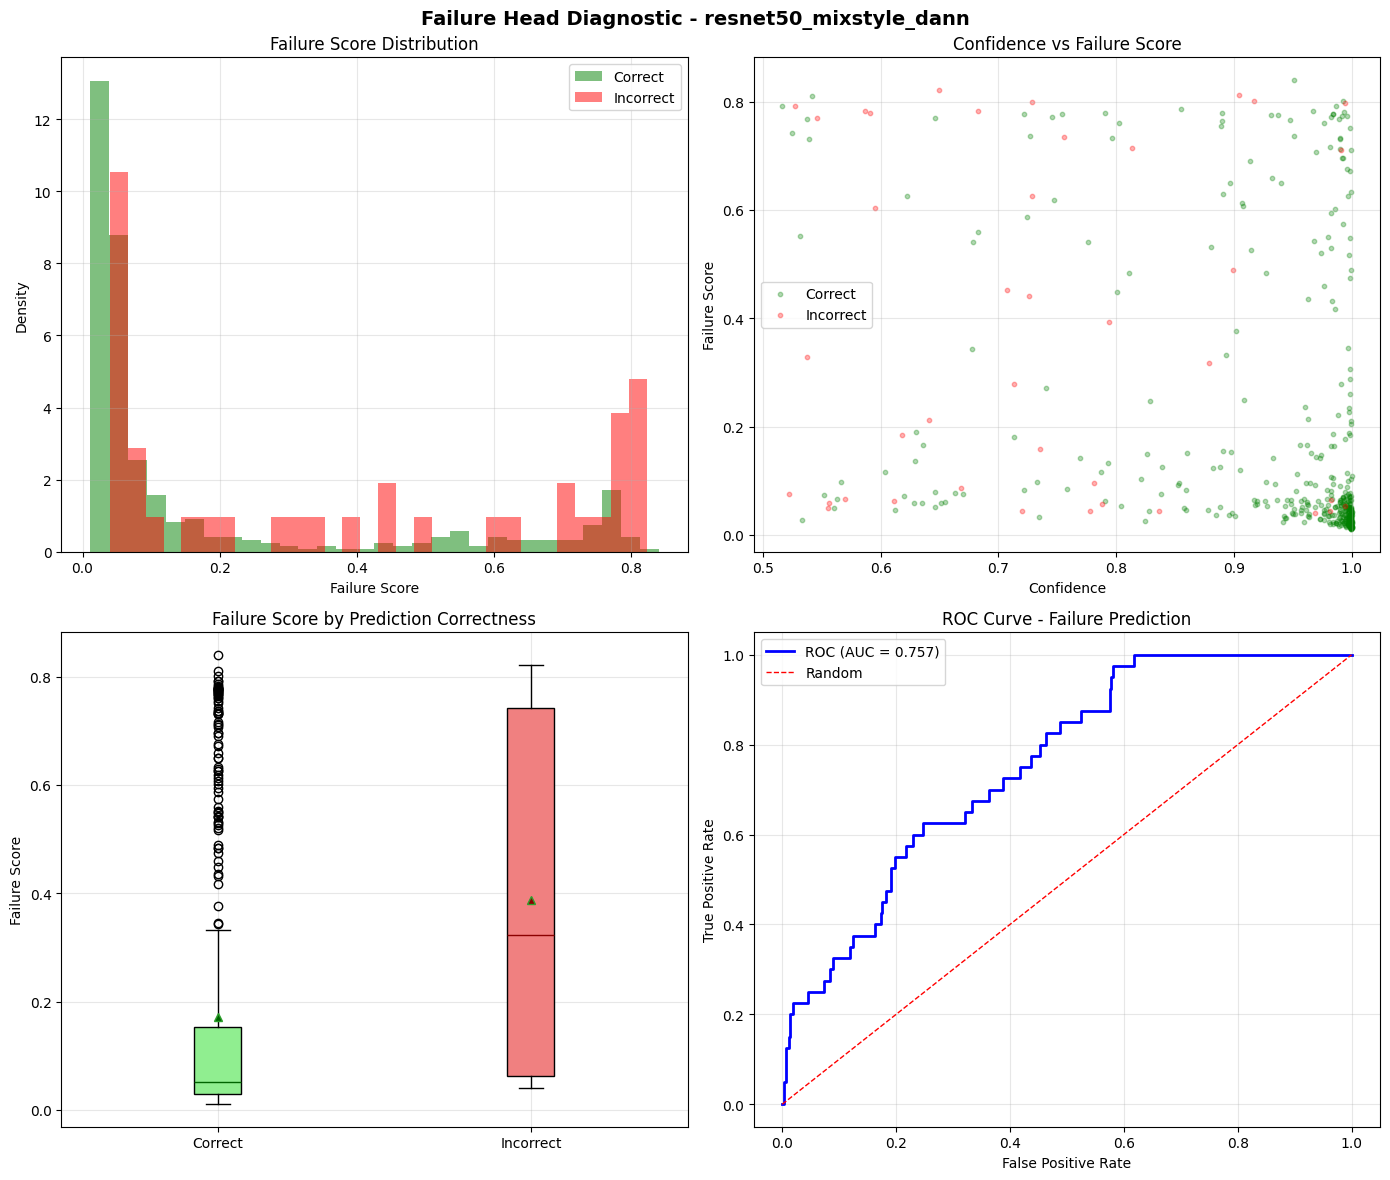


🔍 Checking for failure head collapse...

🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC
Mean score: 0.1977
Std deviation: 0.2716
Unique values: 480
Min score: 0.0121
Max score: 0.8557

Correct predictions:
  Mean: 0.1804
  Std: 0.2609
Incorrect predictions:
  Mean: 0.3367
  Std: 0.3124

Collapse detected: ✅ NO

✅ Failure head diagnostics complete - no auto-retraining performed
   • Correlation: 0.318
   • Std: 0.2570
   • Status: HEALTHY

🔧 Calibrating classification threshold...

📊 Threshold Calibration Results:
   Target Sensitivity: 0.85
   Optimal Threshold: 0.443
   Achieved Sensitivity: 0.850


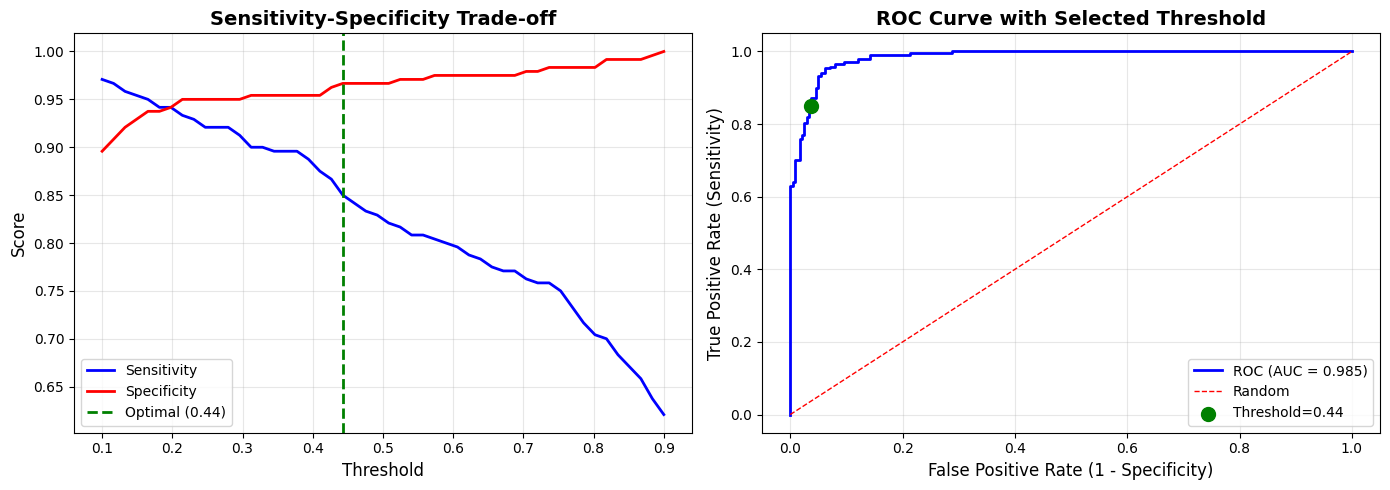

  ✅ Calibrated class threshold: 0.443

📊 Evaluating resnet50_mixstyle_dann...

🔧 SAFE EVALUATION - No retraining performed

🔧 Before temperature scaling:
  • Correct mean: 0.1734
  • Incorrect mean: 0.3233
  • Separation: 0.1499

✅ Optimal temperature: 0.165

📊 After temperature scaling:
  • Correct mean: 0.1492
  • Incorrect mean: 0.3282
  • Separation: 0.1789

📊 Percentile Threshold Analysis:
  • Target recall: 80.0%
  • Optimal threshold: 0.0559
  • Achieved recall: 79.5%
  • Precision: 15.0%
  • F1 score: 0.253
  • Error scores range: [0.0244, 0.8302]
  • FSR with this threshold: 20.5%

📊 FINAL RESULTS WITH SAFE CALIBRATION
Temperature: 0.165
Threshold: 0.055871
Target recall: 80.0%

📈 Classification:
  • Accuracy: 74.5%
  • Precision: 0.9643
  • Recall: 0.6556
  • F1: 0.7806
  • AUC: 0.941
  • Sensitivity: 65.6%
  • Specificity: 94.6%
  • PPV: 96.4%
  • NPV: 55.2%

🛡️ Failure Metrics:
  • Failure Accuracy: 0.7134
  • Failure Precision: 0.3918
  • Failure Recall: 0.2275
  • Failure

Evaluating on target domain: 100%|██████████| 21/21 [00:04<00:00,  4.52it/s]



📊 Results for resnet50_mixstyle_dann (Calibrated)
📈 Classification Metrics:
  Accuracy : 0.7637
  Precision: 0.8436
  Recall   : 0.7637
  F1-score : 0.7725
  AUC      : 0.9406

🏥 Clinical Metrics:
  Sensitivity (TPR): 0.6821
  Specificity (TNR): 0.9458
  PPV              : 0.9656
  NPV              : 0.5714

🛡️ Failure Prediction Metrics:
  Failure Accuracy : 0.6341
  Failure Precision: 0.3796
  Failure Recall   : 0.8645
  Failure F1       : 0.5276
  False Safe Rate  : 0.1355 ⚠️
  True Safe Rate   : 0.5629

🔧 Calibration Info:
  Class Threshold : 0.443
  Failure Threshold: 0.056

Confusion Matrix:
[[192  11]
 [144 309]]

Class-wise Performance:
  Class 0 (No Tumor): TN=192, FP=11
  Class 1 (Tumor):    TP=309, FN=144

📊 Generating all visualizations for resnet50_mixstyle_dann...


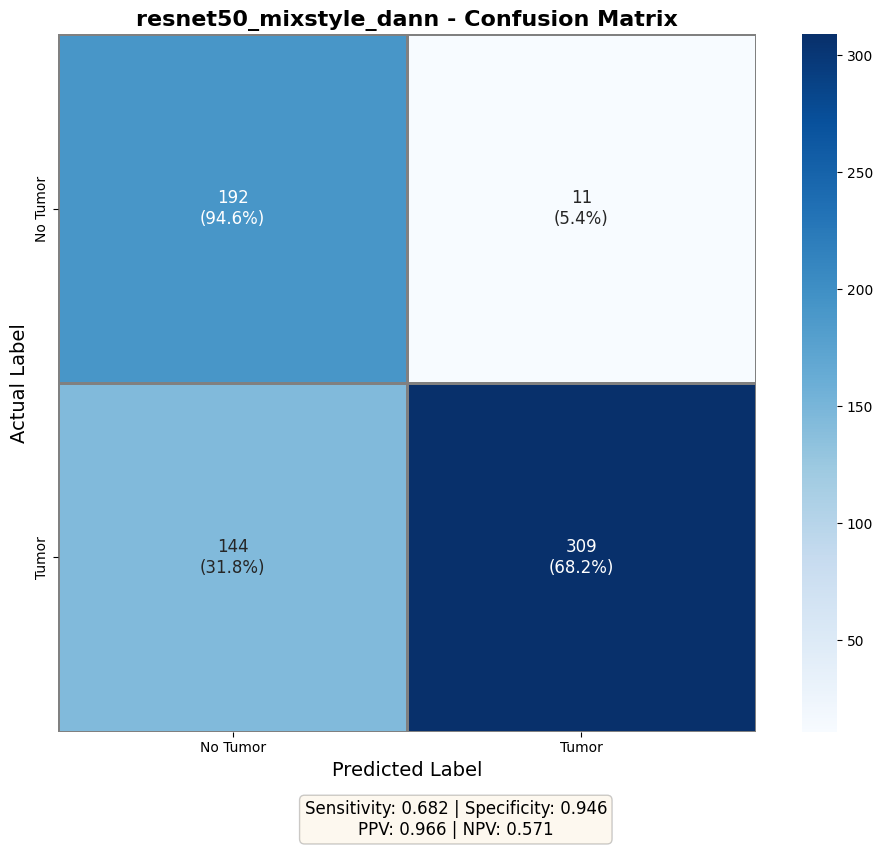

✅ Saved enhanced confusion matrix: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/confusion_matrices/resnet50_mixstyle_dann_confusion_matrix.png


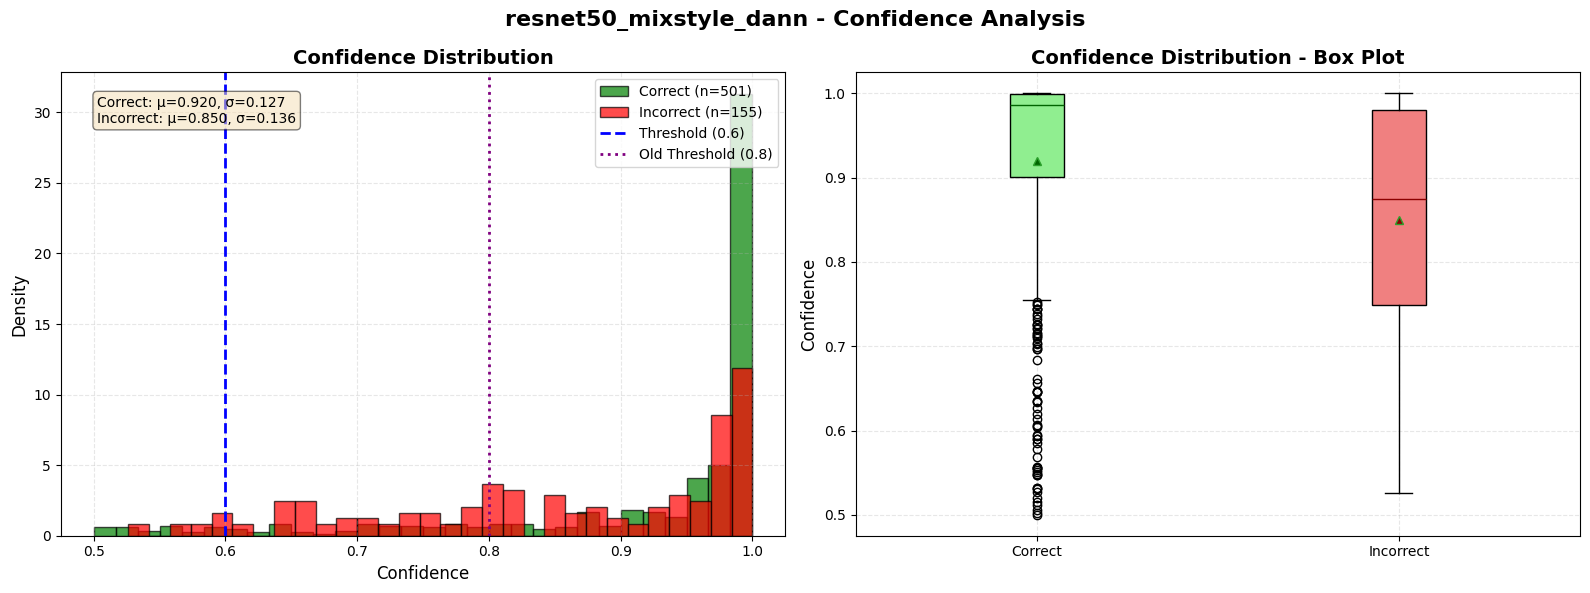

✅ Saved enhanced confidence distribution: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/resnet50_mixstyle_dann_confidence_dist.png


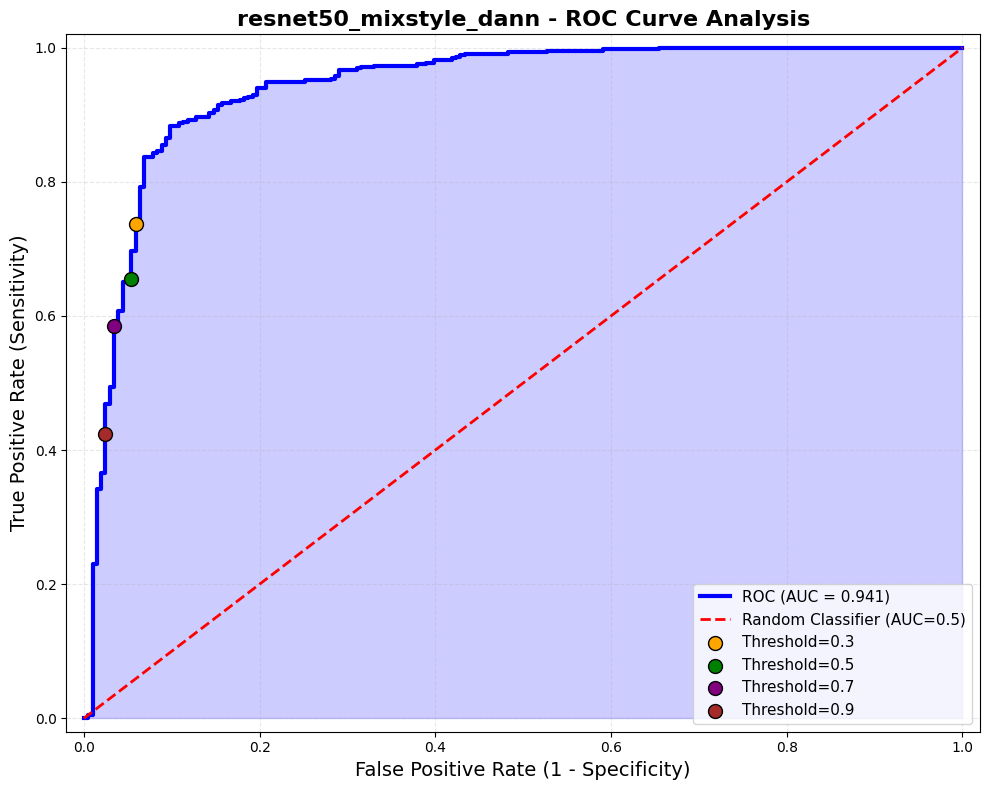

✅ Saved enhanced ROC curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/resnet50_mixstyle_dann_roc_curve.png


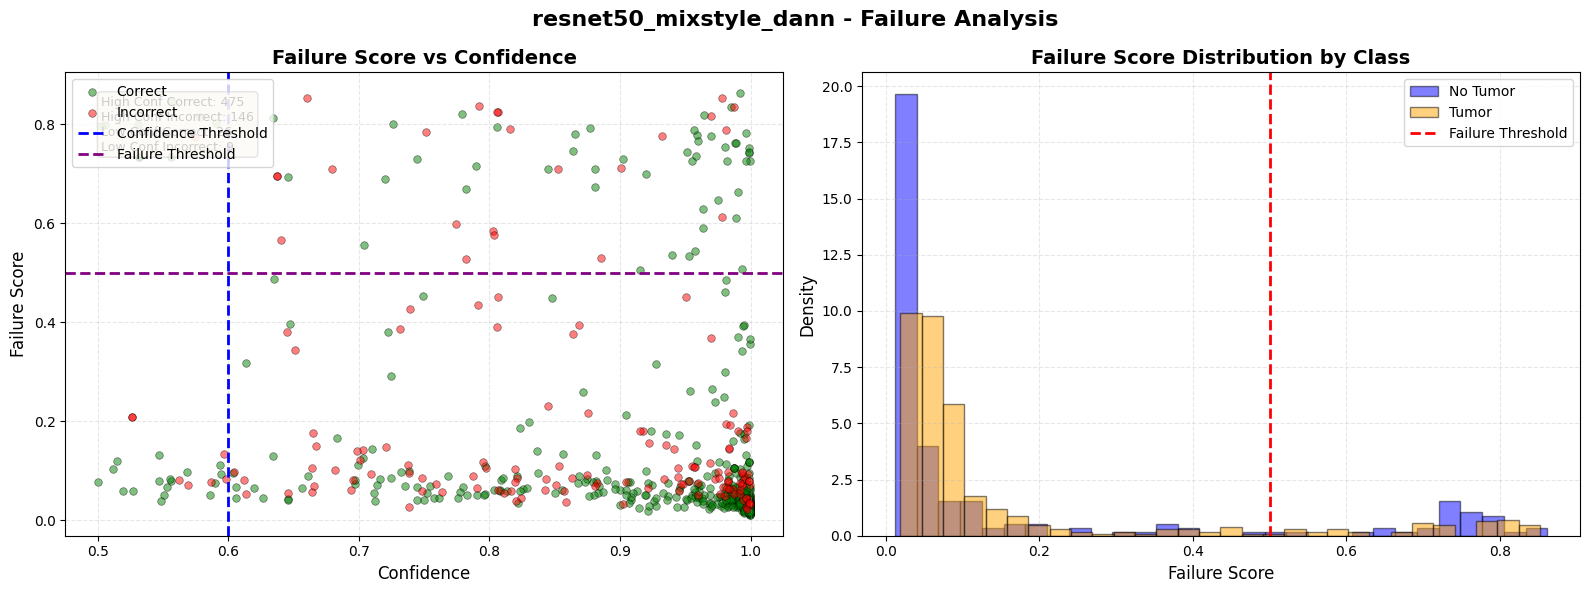

✅ Saved enhanced failure analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/resnet50_mixstyle_dann_failure_analysis.png


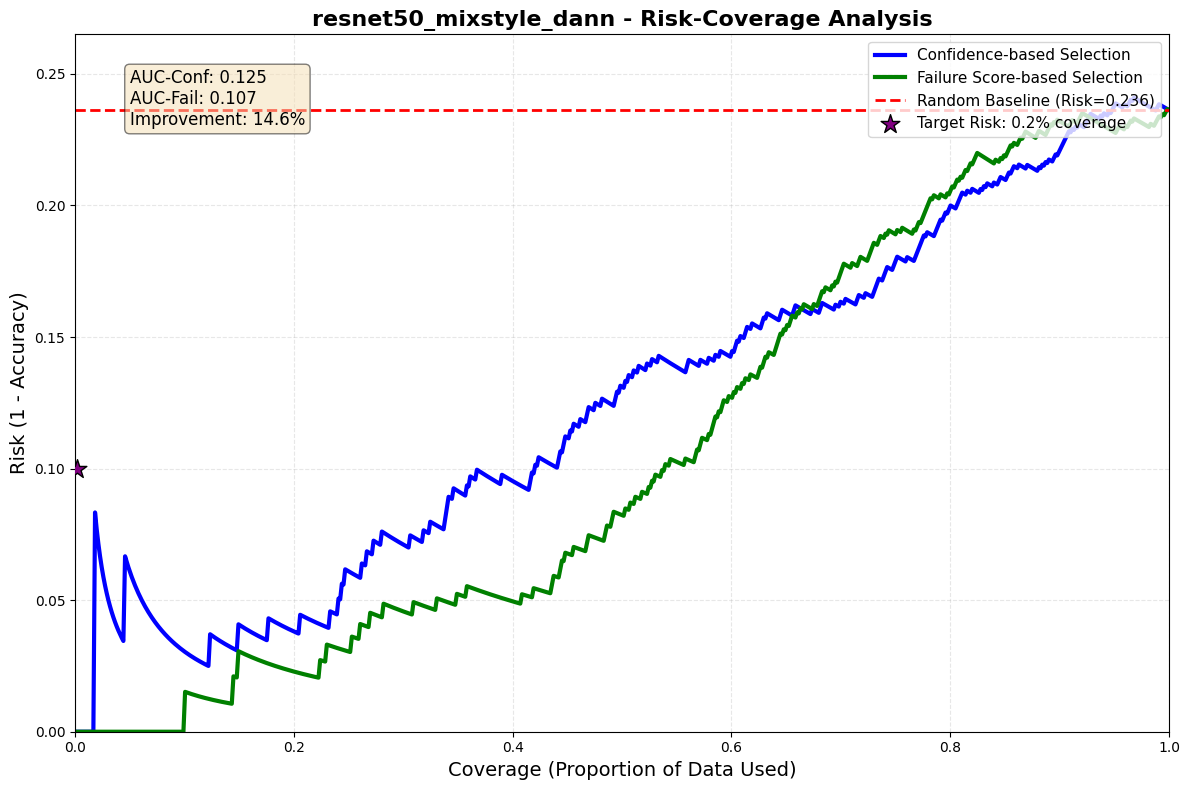

✅ Saved enhanced risk-coverage curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/resnet50_mixstyle_dann_risk_coverage.png


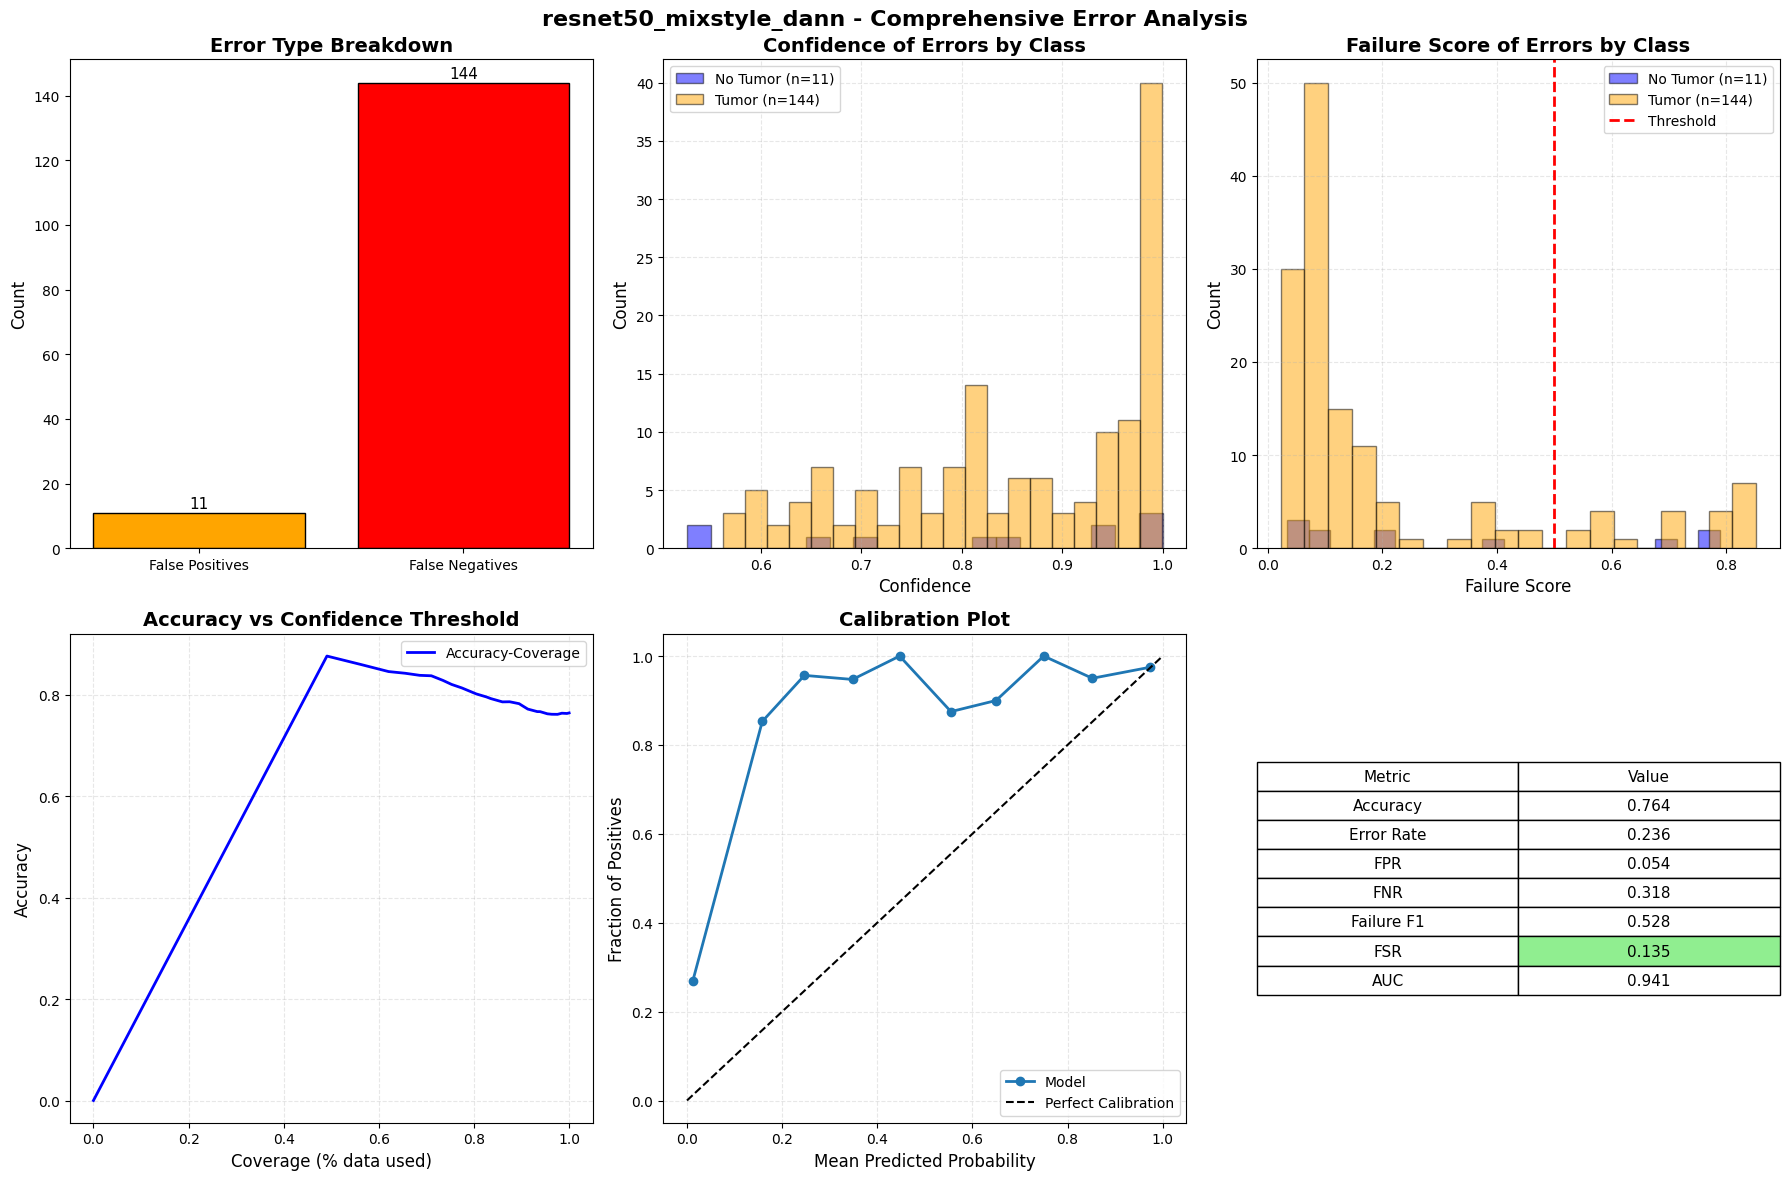

✅ Saved comprehensive error analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/resnet50_mixstyle_dann_error_analysis.png

✅ Completed resnet50_mixstyle_dann
   Accuracy: 0.7637
   FSR: 0.7725
   Failure F1: 0.2879
   Class Threshold: 0.443
  🧹 After cleanup: 13.8GB free


🔹 Processing Model 2/6: densenet121
Configuration:
  • MixStyle: True
  • DANN: True
  • Epochs: 30
  • Learning Rate: 0.0001
  🔒 Seeds reset to 42
  🧹 GPU: 13.8GB free / 14.6GB total

🔧 Building model with backbone: densenet121
  🔄 Loading timm model: densenet121
  ✅ Detected feature dimension: 1024
  📊 Using num_features: 1024
  ✅ Added MixStyle to DenseNet block1
  ✅ Classification head: 1024 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initialization
  ✅ Domain class

Diagnosing failure head: 100%|██████████| 15/15 [00:04<00:00,  3.56it/s]



🔍 FAILURE HEAD DIAGNOSTIC

📊 Basic Statistics:
   Mean: 0.1817
   Std: 0.2789
   Min: 0.0131
   Max: 0.8170
   % > 0.1: 25.4%
   % > 0.5: 19.6%
   % > 0.8: 2.1%

📊 Correct Predictions (n=463):
   Mean: 0.1708
   Std: 0.2705
   Median: 0.0316

📊 Incorrect Predictions (n=17):
   Mean: 0.4788
   Std: 0.3351
   Median: 0.7318

📊 T-test (correct vs incorrect):
   t-statistic: -4.5577
   p-value: 0.0000
   ✅ Failure head IS differentiating correct/incorrect predictions!

📊 Correlation with uncertainty (1-confidence): 0.3231
   ✅ Good positive correlation with uncertainty!


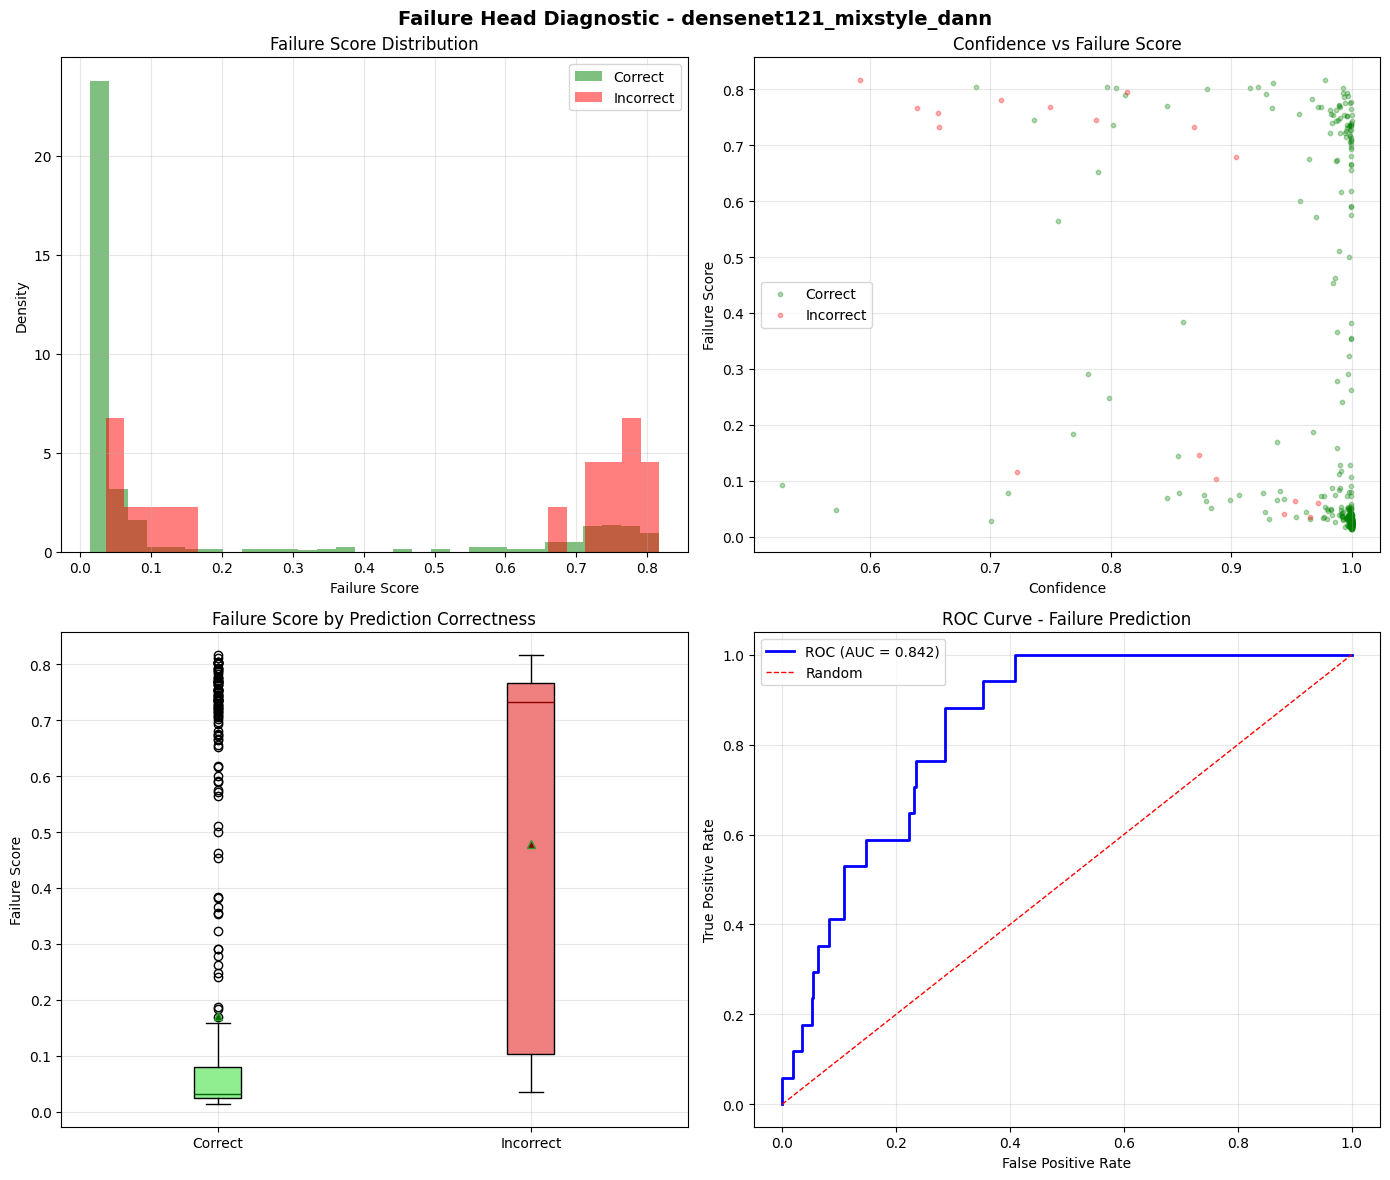


🔍 Checking for failure head collapse...

🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC
Mean score: 0.1781
Std deviation: 0.2785
Unique values: 480
Min score: 0.0117
Max score: 0.8192

Correct predictions:
  Mean: 0.1763
  Std: 0.2777
Incorrect predictions:
  Mean: 0.2527
  Std: 0.3011

Collapse detected: ✅ NO

✅ Failure head diagnostics complete - no auto-retraining performed
   • Correlation: 0.323
   • Std: 0.2789
   • Status: HEALTHY

🔧 Calibrating classification threshold...

📊 Threshold Calibration Results:
   Target Sensitivity: 0.85
   Optimal Threshold: 0.900
   Achieved Sensitivity: 0.921


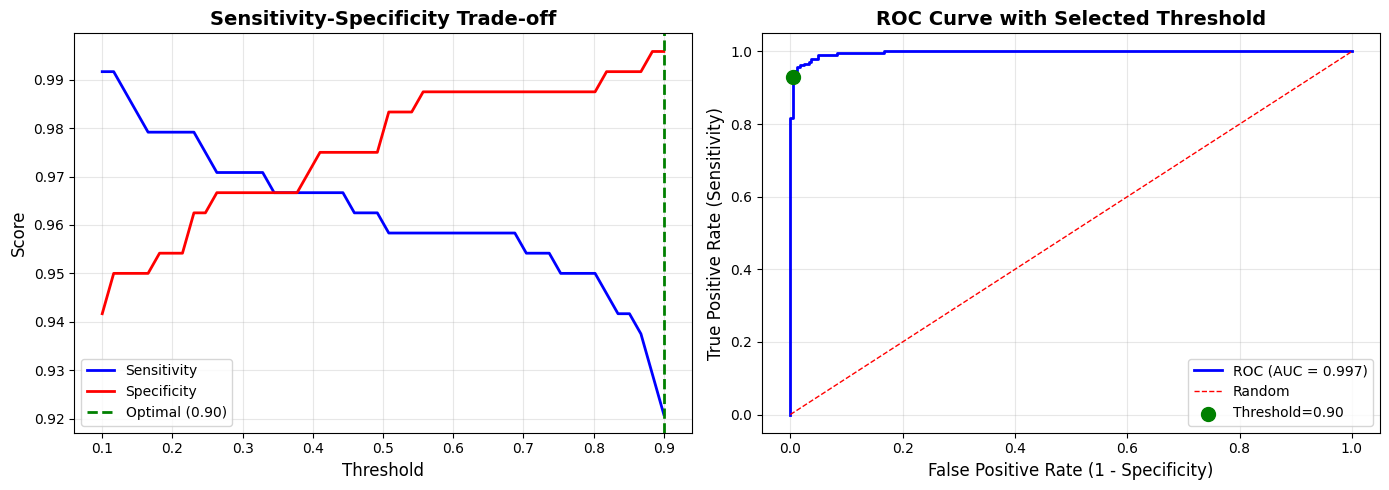

  ✅ Calibrated class threshold: 0.900

📊 Evaluating densenet121_mixstyle_dann...

🔧 SAFE EVALUATION - No retraining performed

🔧 Before temperature scaling:
  • Correct mean: 0.1813
  • Incorrect mean: 0.4309
  • Separation: 0.2496

✅ Optimal temperature: 0.208

📊 After temperature scaling:
  • Correct mean: 0.1946
  • Incorrect mean: 0.4810
  • Separation: 0.2864

📊 Percentile Threshold Analysis:
  • Target recall: 80.0%
  • Optimal threshold: 0.0638
  • Achieved recall: 77.8%
  • Precision: 4.8%
  • F1 score: 0.091
  • Error scores range: [0.0386, 0.7676]
  • FSR with this threshold: 22.2%

📊 FINAL RESULTS WITH SAFE CALIBRATION
Temperature: 0.208
Threshold: 0.063752
Target recall: 80.0%

📈 Classification:
  • Accuracy: 82.6%
  • Precision: 0.9748
  • Recall: 0.7682
  • F1: 0.8593
  • AUC: 0.950
  • Sensitivity: 76.8%
  • Specificity: 95.6%
  • PPV: 97.5%
  • NPV: 64.9%

🛡️ Failure Metrics:
  • Failure Accuracy: 0.7607
  • Failure Precision: 0.3359
  • Failure Recall: 0.3860
  • Failu

Evaluating on target domain: 100%|██████████| 21/21 [00:05<00:00,  4.09it/s]



📊 Results for densenet121_mixstyle_dann (Calibrated)
📈 Classification Metrics:
  Accuracy : 0.7256
  Precision: 0.8381
  Recall   : 0.7256
  F1-score : 0.7346
  AUC      : 0.9502

🏥 Clinical Metrics:
  Sensitivity (TPR): 0.6181
  Specificity (TNR): 0.9655
  PPV              : 0.9756
  NPV              : 0.5312

🛡️ Failure Prediction Metrics:
  Failure Accuracy : 0.7439
  Failure Precision: 0.5252
  Failure Recall   : 0.6944
  Failure F1       : 0.5981
  False Safe Rate  : 0.3056 ⚠️
  True Safe Rate   : 0.7626

🔧 Calibration Info:
  Class Threshold : 0.900
  Failure Threshold: 0.064

Confusion Matrix:
[[196   7]
 [173 280]]

Class-wise Performance:
  Class 0 (No Tumor): TN=196, FP=7
  Class 1 (Tumor):    TP=280, FN=173

📊 Generating all visualizations for densenet121_mixstyle_dann...


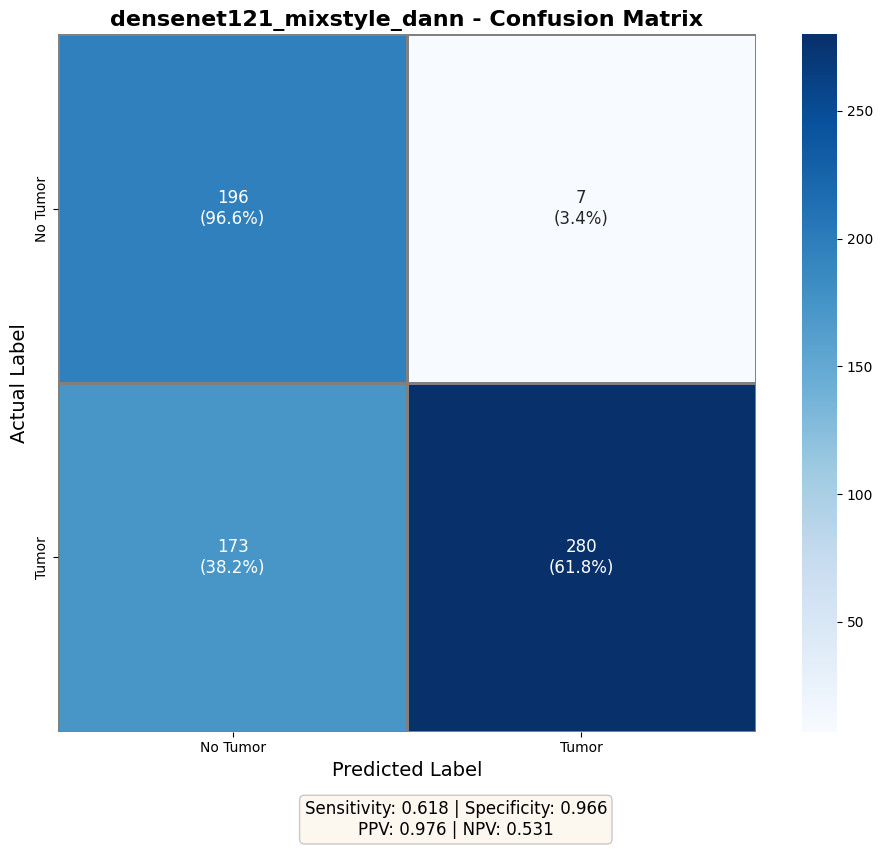

✅ Saved enhanced confusion matrix: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/confusion_matrices/densenet121_mixstyle_dann_confusion_matrix.png


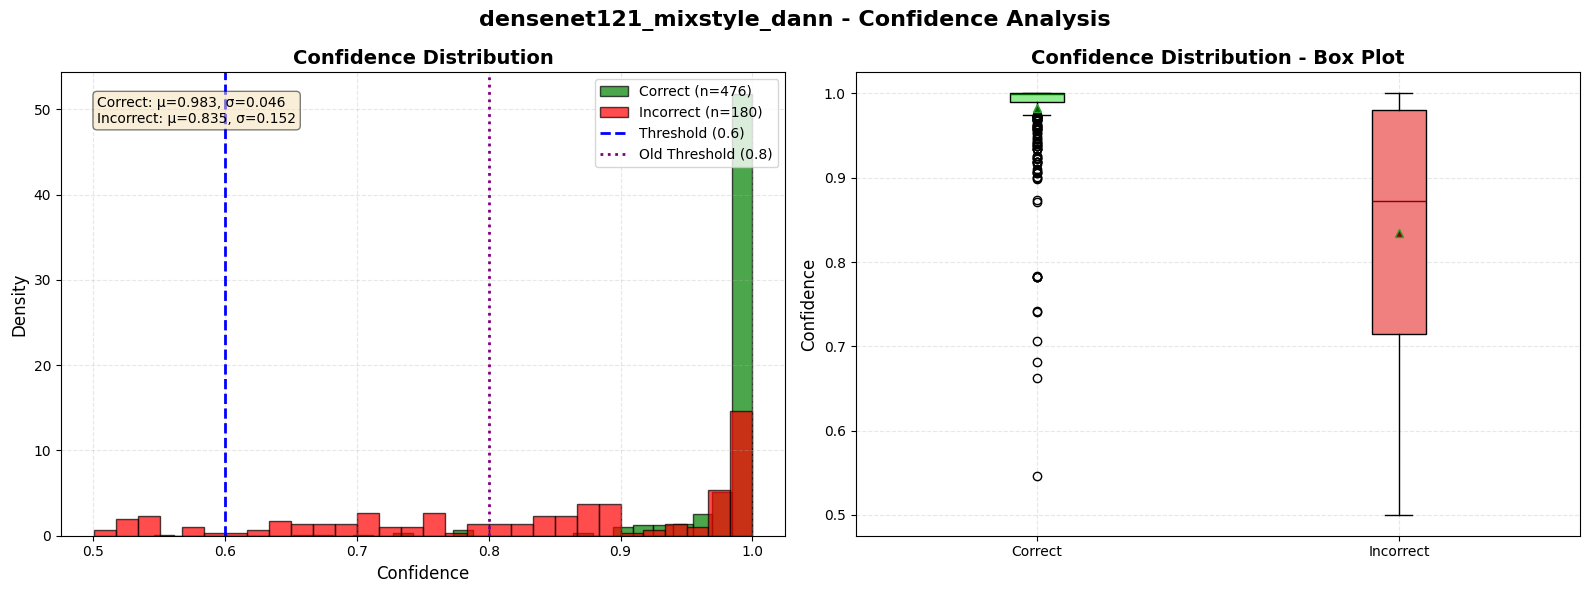

✅ Saved enhanced confidence distribution: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/densenet121_mixstyle_dann_confidence_dist.png


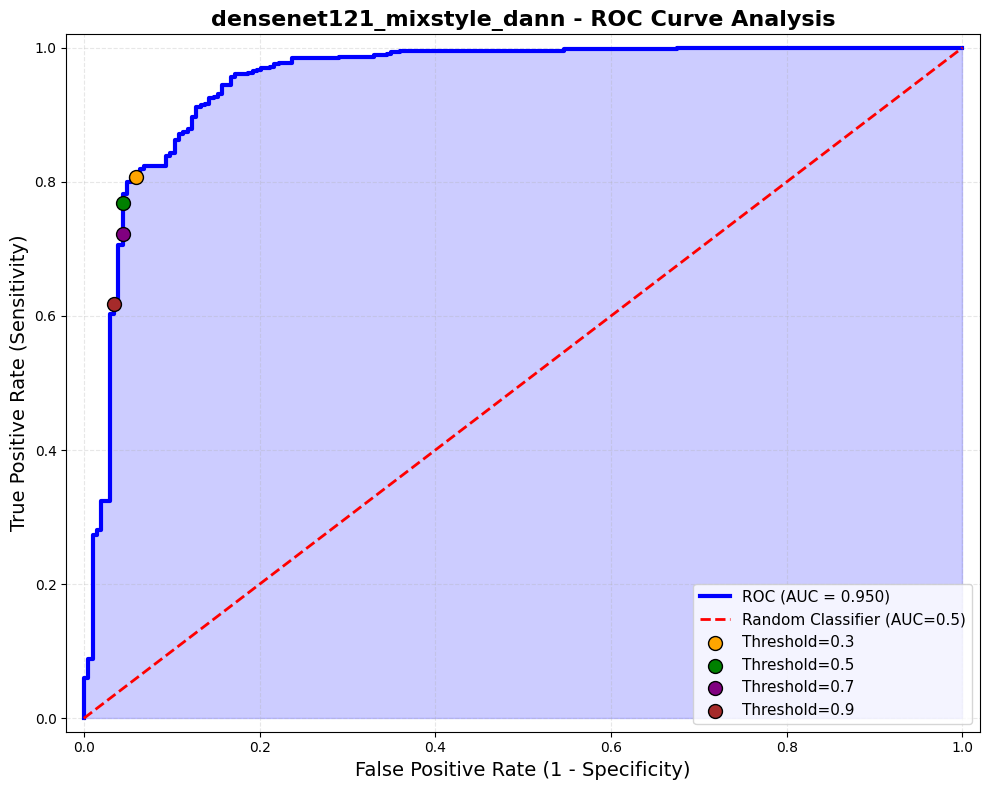

✅ Saved enhanced ROC curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/densenet121_mixstyle_dann_roc_curve.png


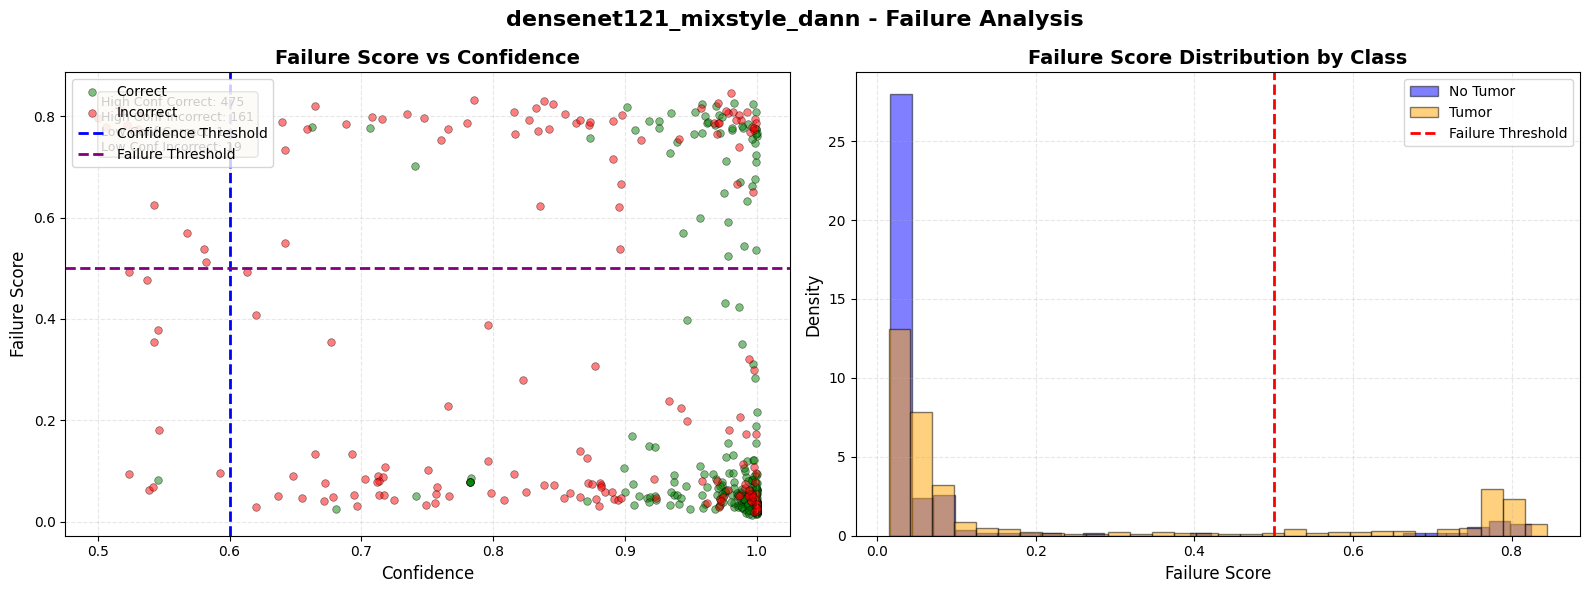

✅ Saved enhanced failure analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/densenet121_mixstyle_dann_failure_analysis.png


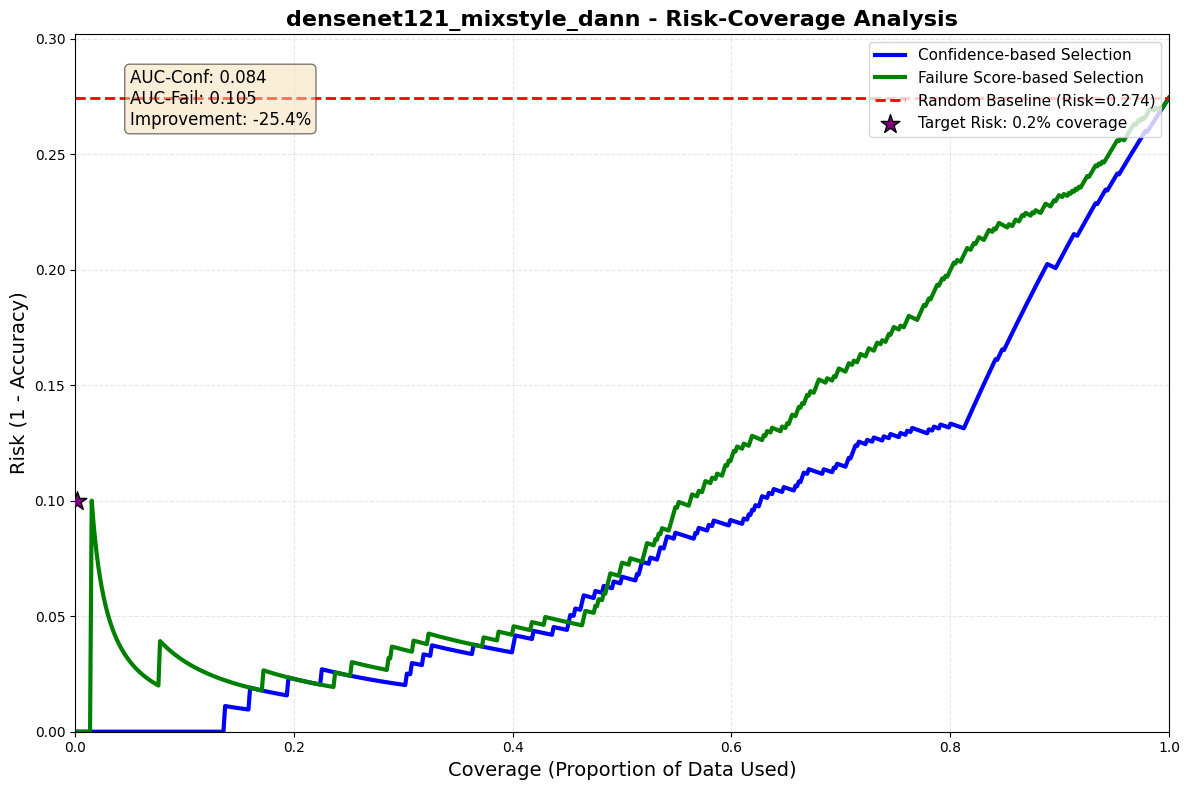

✅ Saved enhanced risk-coverage curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/densenet121_mixstyle_dann_risk_coverage.png


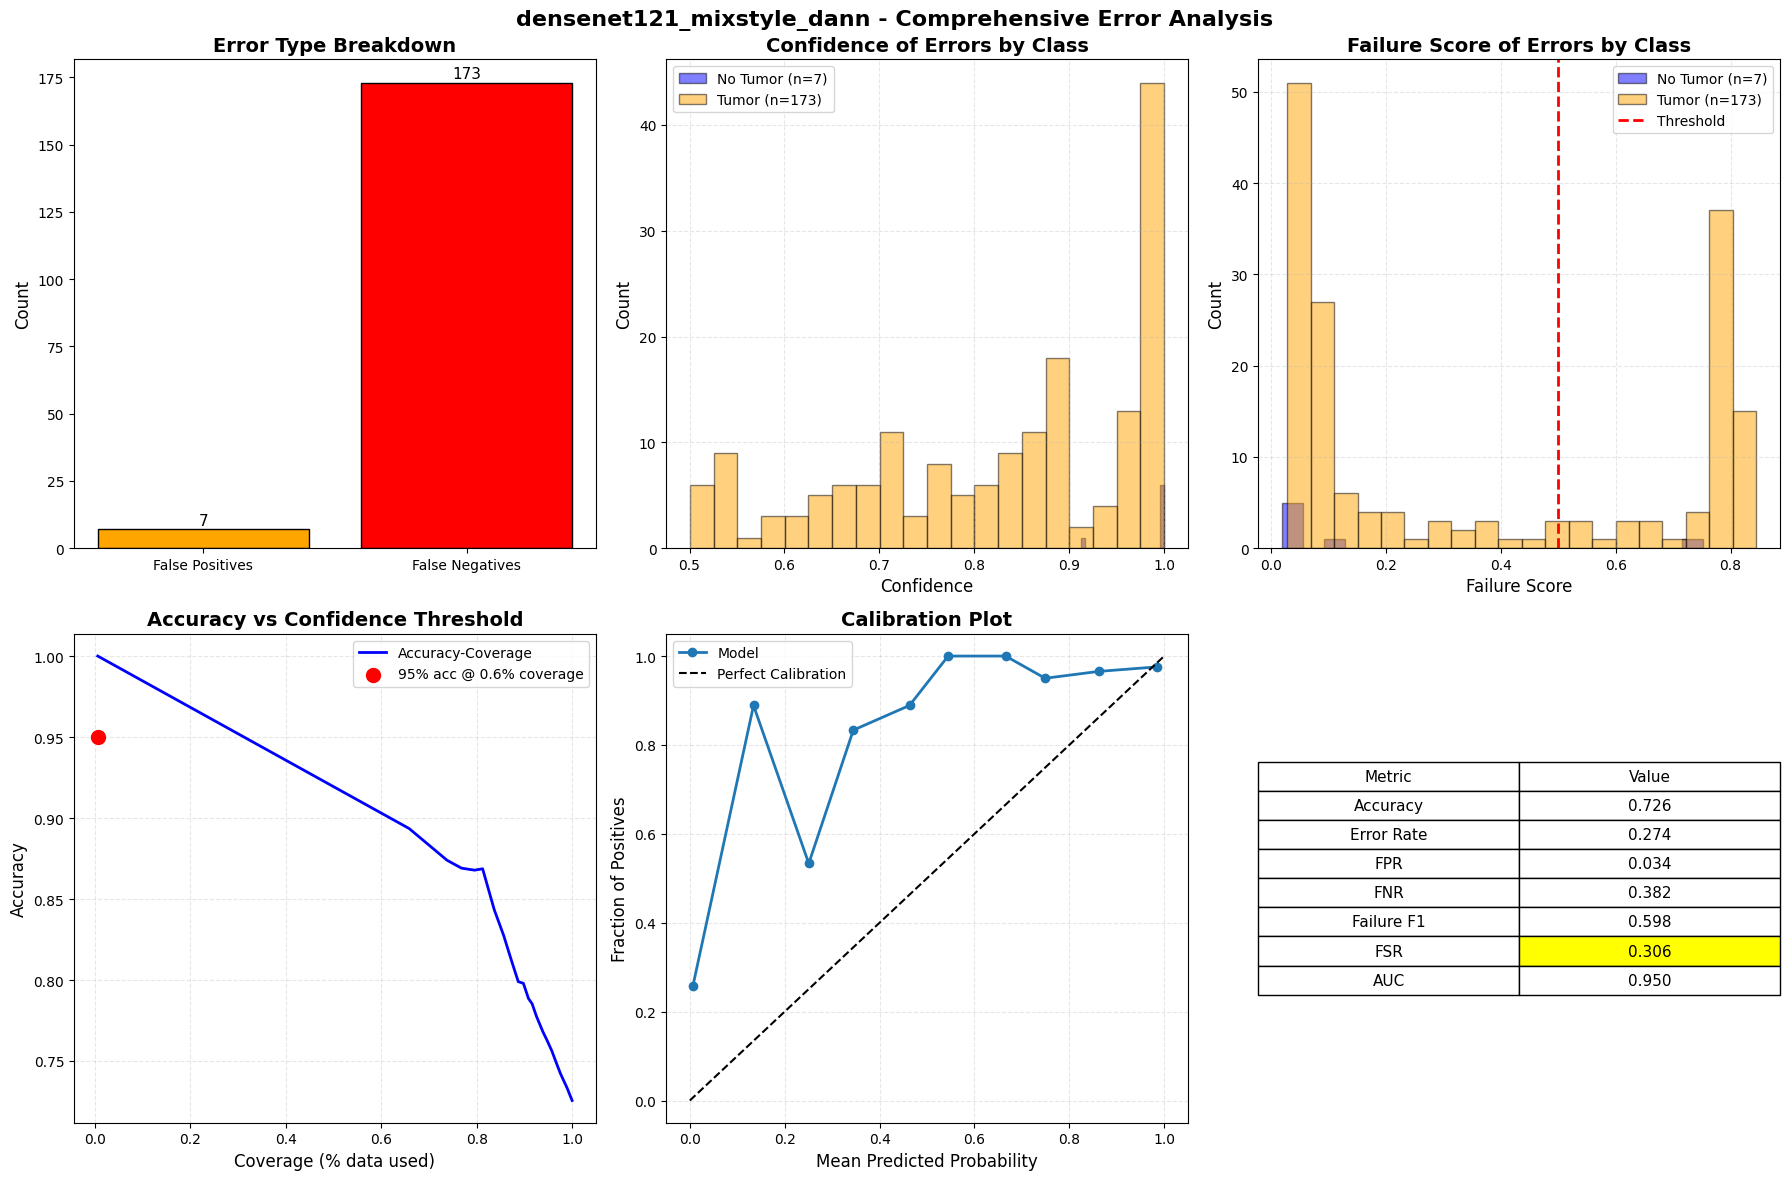

✅ Saved comprehensive error analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/densenet121_mixstyle_dann_error_analysis.png

✅ Completed densenet121_mixstyle_dann
   Accuracy: 0.7256
   FSR: 0.6140
   Failure F1: 0.3592
   Class Threshold: 0.900
  🧹 After cleanup: 13.8GB free


🔹 Processing Model 3/6: efficientnet_b0
Configuration:
  • MixStyle: True
  • DANN: True
  • Epochs: 30
  • Learning Rate: 0.0001
  🔒 Seeds reset to 42
  🧹 GPU: 13.8GB free / 14.6GB total

🔧 Building model with backbone: efficientnet_b0
  🔄 Loading timm model: efficientnet_b0
  ✅ Detected feature dimension: 1280
  📊 Using num_features: 1280
  ✅ Added MixStyle to EfficientNet blocks[0]
  ✅ Classification head: 1280 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initia

Diagnosing failure head: 100%|██████████| 15/15 [00:04<00:00,  3.12it/s]



🔍 FAILURE HEAD DIAGNOSTIC

📊 Basic Statistics:
   Mean: 0.1889
   Std: 0.2873
   Min: 0.0117
   Max: 0.8293
   % > 0.1: 26.7%
   % > 0.5: 20.6%
   % > 0.8: 1.9%

📊 Correct Predictions (n=455):
   Mean: 0.1712
   Std: 0.2741
   Median: 0.0293

📊 Incorrect Predictions (n=25):
   Mean: 0.5107
   Std: 0.3297
   Median: 0.7127

📊 T-test (correct vs incorrect):
   t-statistic: -5.9479
   p-value: 0.0000
   ✅ Failure head IS differentiating correct/incorrect predictions!

📊 Correlation with uncertainty (1-confidence): 0.4724
   ✅ Good positive correlation with uncertainty!


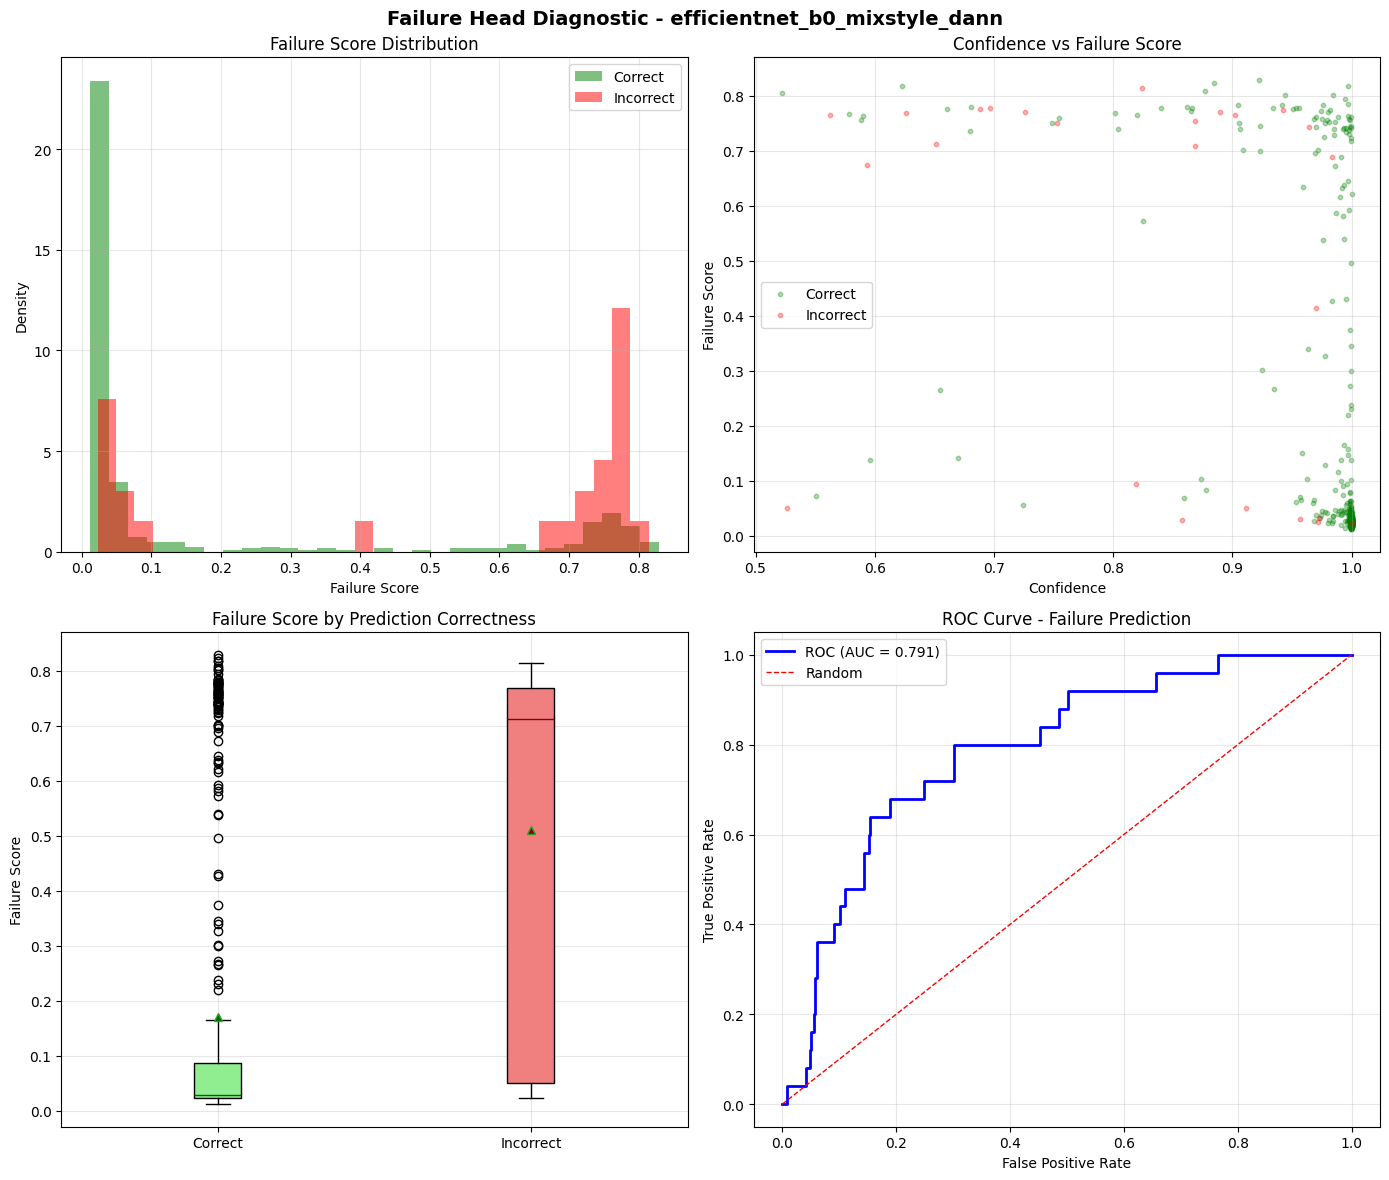


🔍 Checking for failure head collapse...

🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC
Mean score: 0.1868
Std deviation: 0.2859
Unique values: 480
Min score: 0.0134
Max score: 0.8292

Correct predictions:
  Mean: 0.1673
  Std: 0.2718
Incorrect predictions:
  Mean: 0.5012
  Std: 0.3219

Collapse detected: ✅ NO

✅ Failure head diagnostics complete - no auto-retraining performed
   • Correlation: 0.472
   • Std: 0.2873
   • Status: HEALTHY

🔧 Calibrating classification threshold...

📊 Threshold Calibration Results:
   Target Sensitivity: 0.85
   Optimal Threshold: 0.671
   Achieved Sensitivity: 0.858


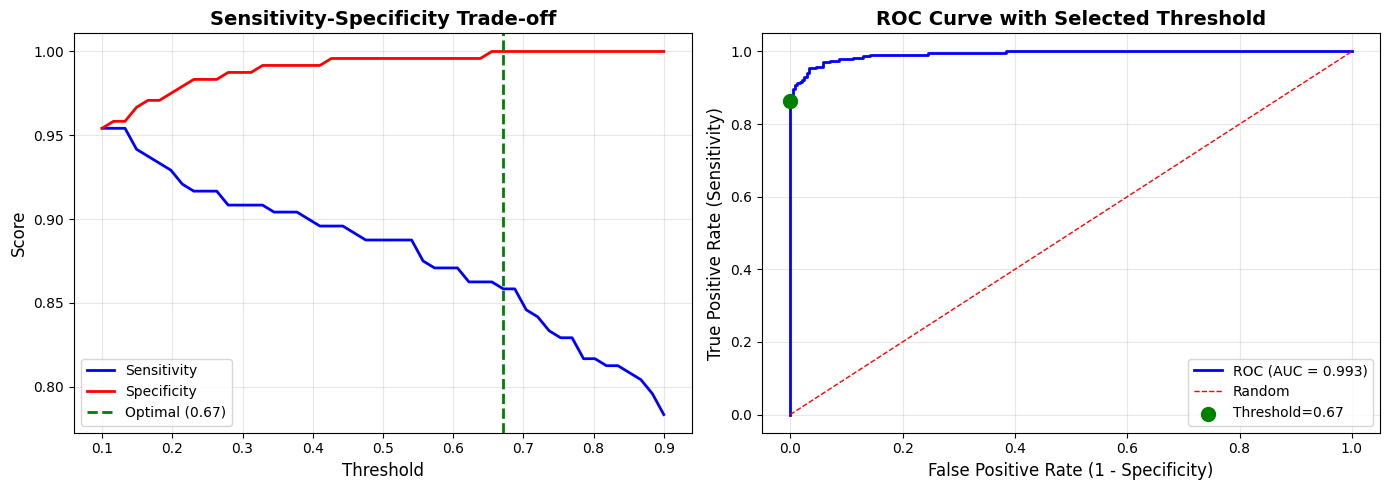

  ✅ Calibrated class threshold: 0.671

📊 Evaluating efficientnet_b0_mixstyle_dann...

🔧 SAFE EVALUATION - No retraining performed

🔧 Before temperature scaling:
  • Correct mean: 0.1623
  • Incorrect mean: 0.4972
  • Separation: 0.3349

✅ Optimal temperature: 0.100

📊 After temperature scaling:
  • Correct mean: 0.1669
  • Incorrect mean: 0.6120
  • Separation: 0.4451

📊 Percentile Threshold Analysis:
  • Target recall: 80.0%
  • Optimal threshold: 0.0492
  • Achieved recall: 76.9%
  • Precision: 13.7%
  • F1 score: 0.233
  • Error scores range: [0.0238, 0.7883]
  • FSR with this threshold: 23.1%

📊 FINAL RESULTS WITH SAFE CALIBRATION
Temperature: 0.100
Threshold: 0.049200
Target recall: 80.0%

📈 Classification:
  • Accuracy: 88.1%
  • Precision: 0.9795
  • Recall: 0.8455
  • F1: 0.9076
  • AUC: 0.973
  • Sensitivity: 84.5%
  • Specificity: 96.1%
  • PPV: 98.0%
  • NPV: 73.6%

🛡️ Failure Metrics:
  • Failure Accuracy: 0.7500
  • Failure Precision: 0.2713
  • Failure Recall: 0.6538
  • 

Evaluating on target domain: 100%|██████████| 21/21 [00:06<00:00,  3.44it/s]



📊 Results for efficientnet_b0_mixstyle_dann (Calibrated)
📈 Classification Metrics:
  Accuracy : 0.8582
  Precision: 0.8941
  Recall   : 0.8582
  F1-score : 0.8631
  AUC      : 0.9728

🏥 Clinical Metrics:
  Sensitivity (TPR): 0.8079
  Specificity (TNR): 0.9704
  PPV              : 0.9839
  NPV              : 0.6937

🛡️ Failure Prediction Metrics:
  Failure Accuracy : 0.6463
  Failure Precision: 0.2706
  Failure Recall   : 0.8817
  Failure F1       : 0.4141
  False Safe Rate  : 0.1183 ⚠️
  True Safe Rate   : 0.6075

🔧 Calibration Info:
  Class Threshold : 0.671
  Failure Threshold: 0.049

Confusion Matrix:
[[197   6]
 [ 87 366]]

Class-wise Performance:
  Class 0 (No Tumor): TN=197, FP=6
  Class 1 (Tumor):    TP=366, FN=87

📊 Generating all visualizations for efficientnet_b0_mixstyle_dann...


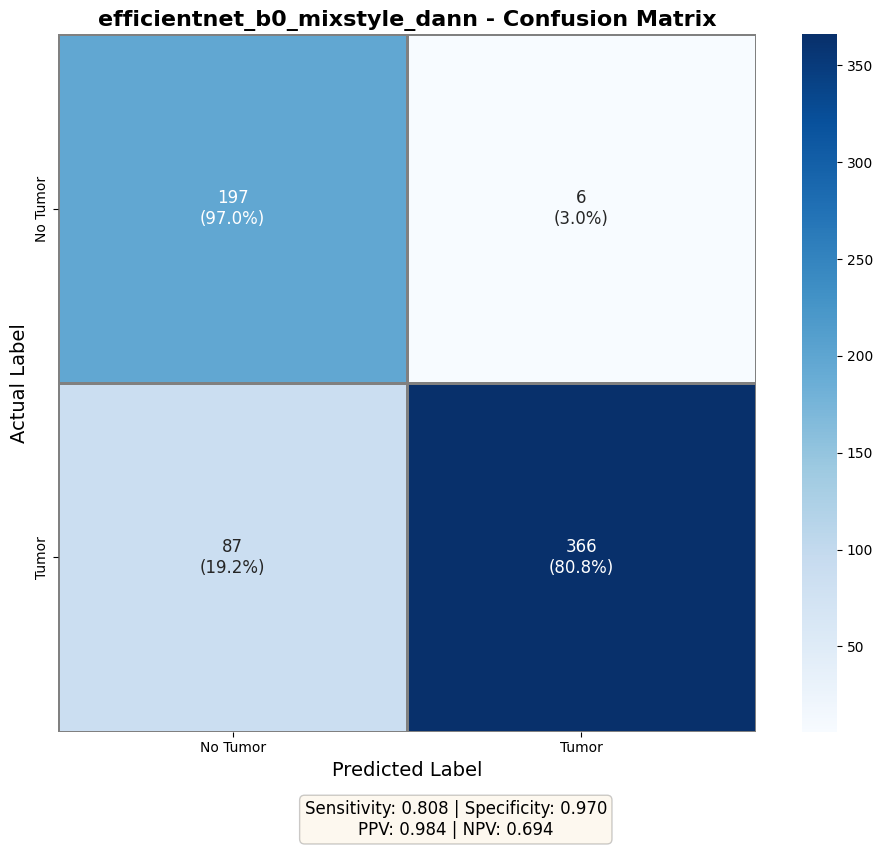

✅ Saved enhanced confusion matrix: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/confusion_matrices/efficientnet_b0_mixstyle_dann_confusion_matrix.png


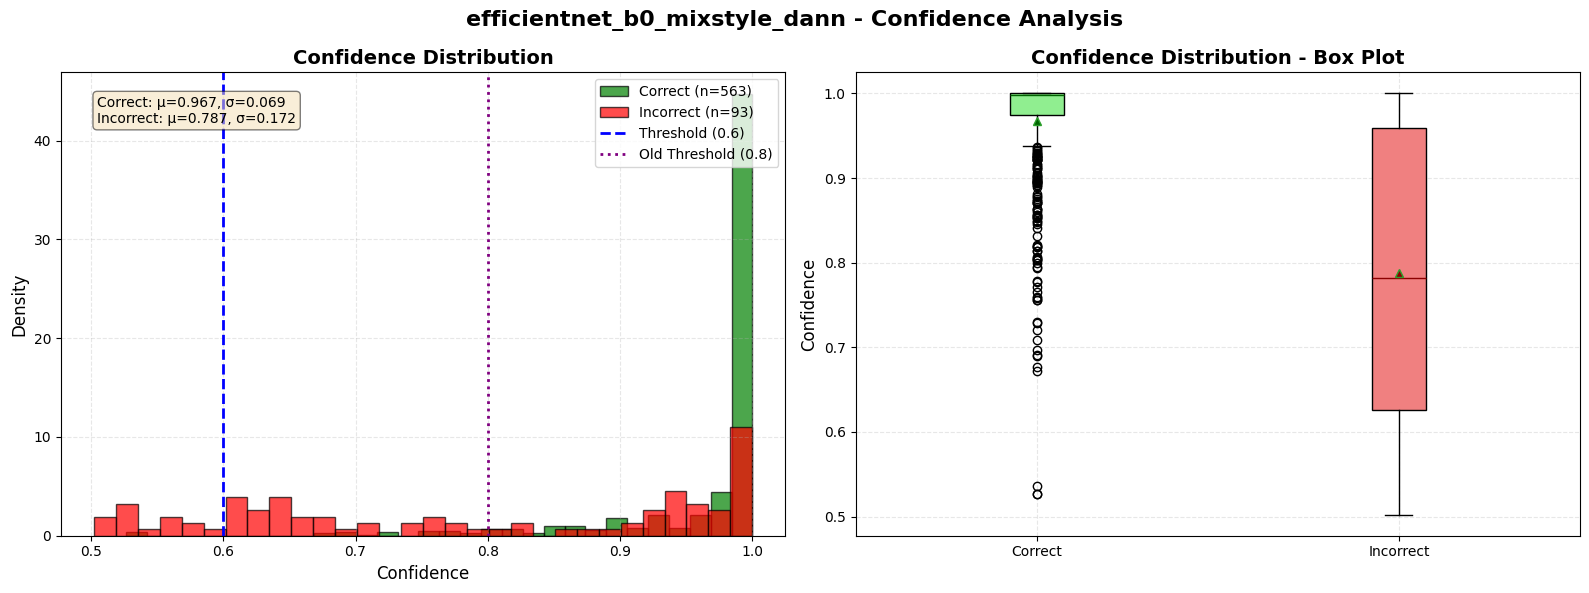

✅ Saved enhanced confidence distribution: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/efficientnet_b0_mixstyle_dann_confidence_dist.png


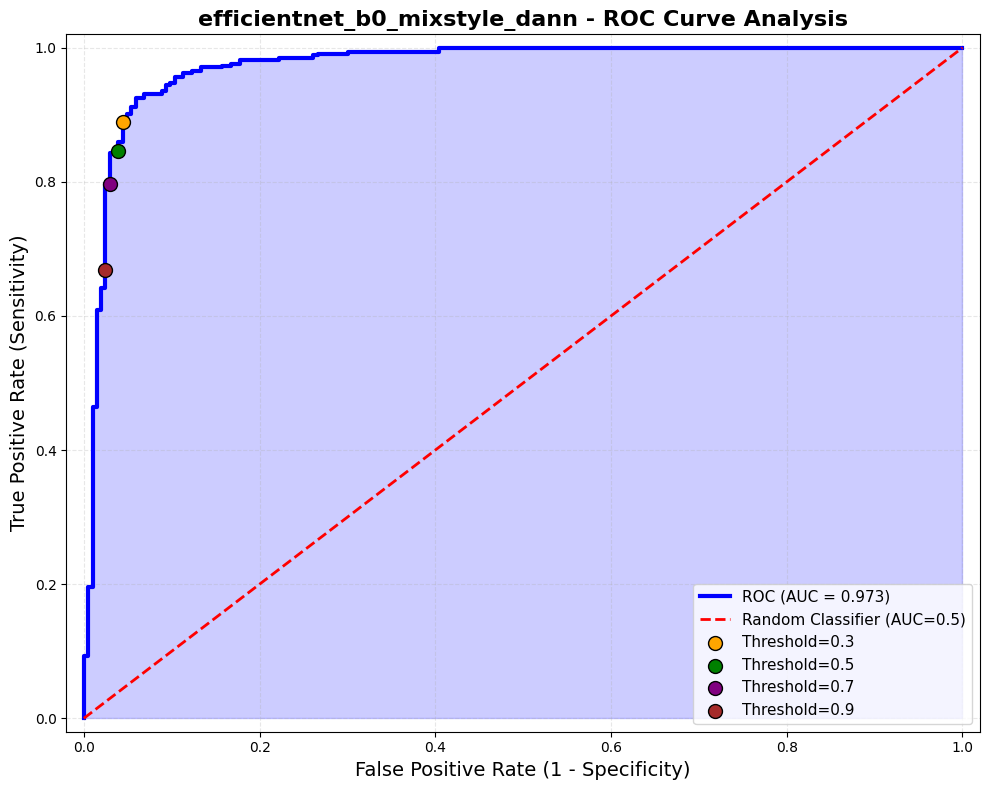

✅ Saved enhanced ROC curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/efficientnet_b0_mixstyle_dann_roc_curve.png


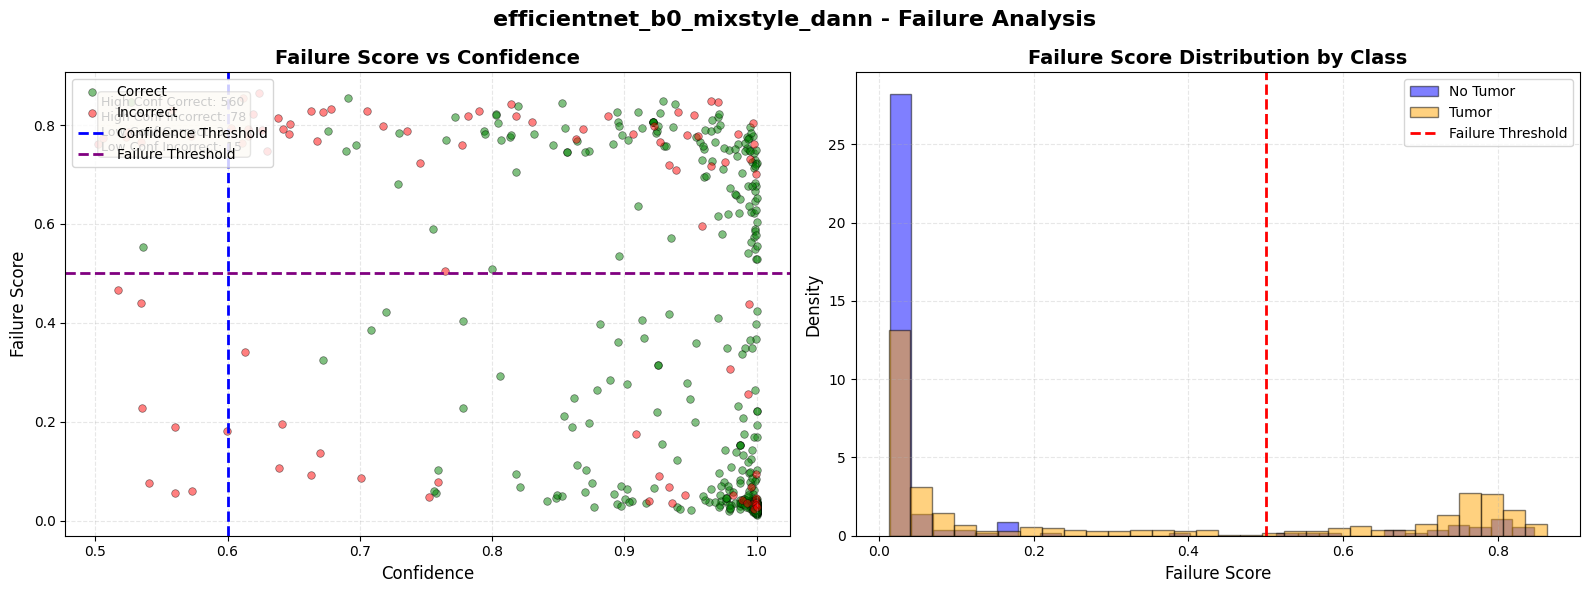

✅ Saved enhanced failure analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/efficientnet_b0_mixstyle_dann_failure_analysis.png


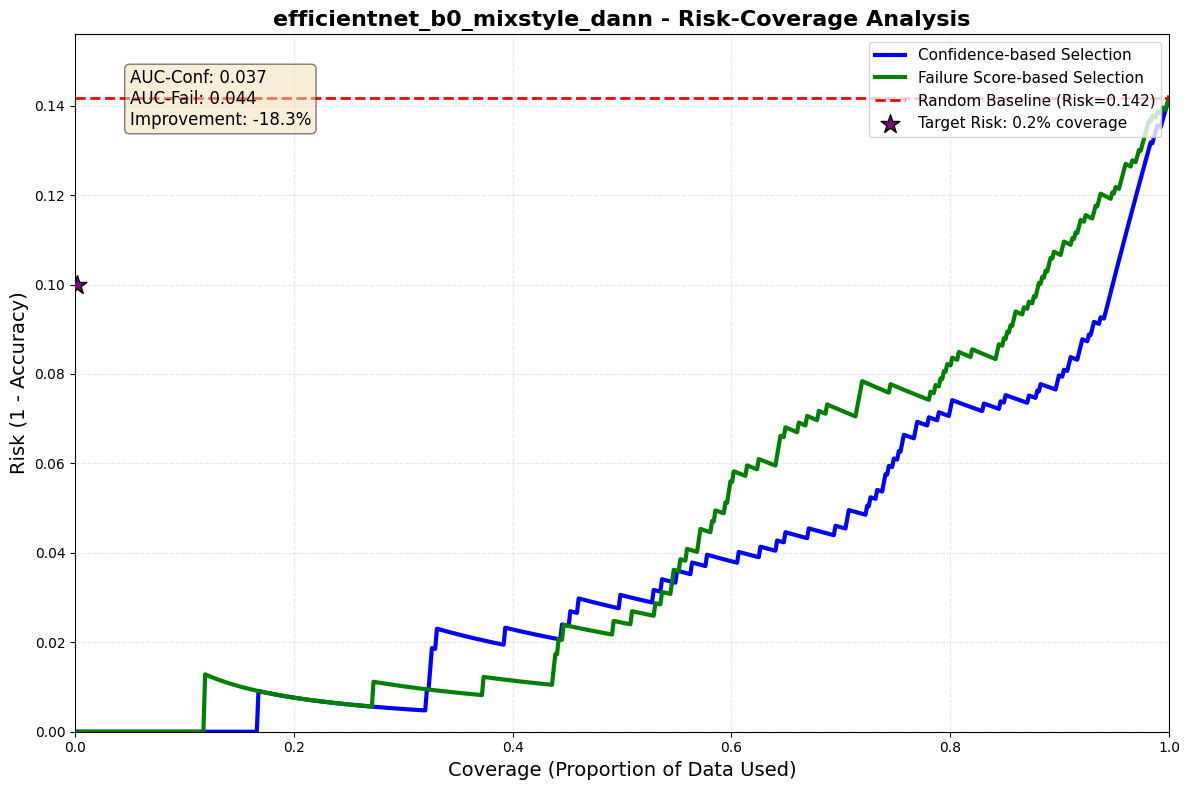

✅ Saved enhanced risk-coverage curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/efficientnet_b0_mixstyle_dann_risk_coverage.png


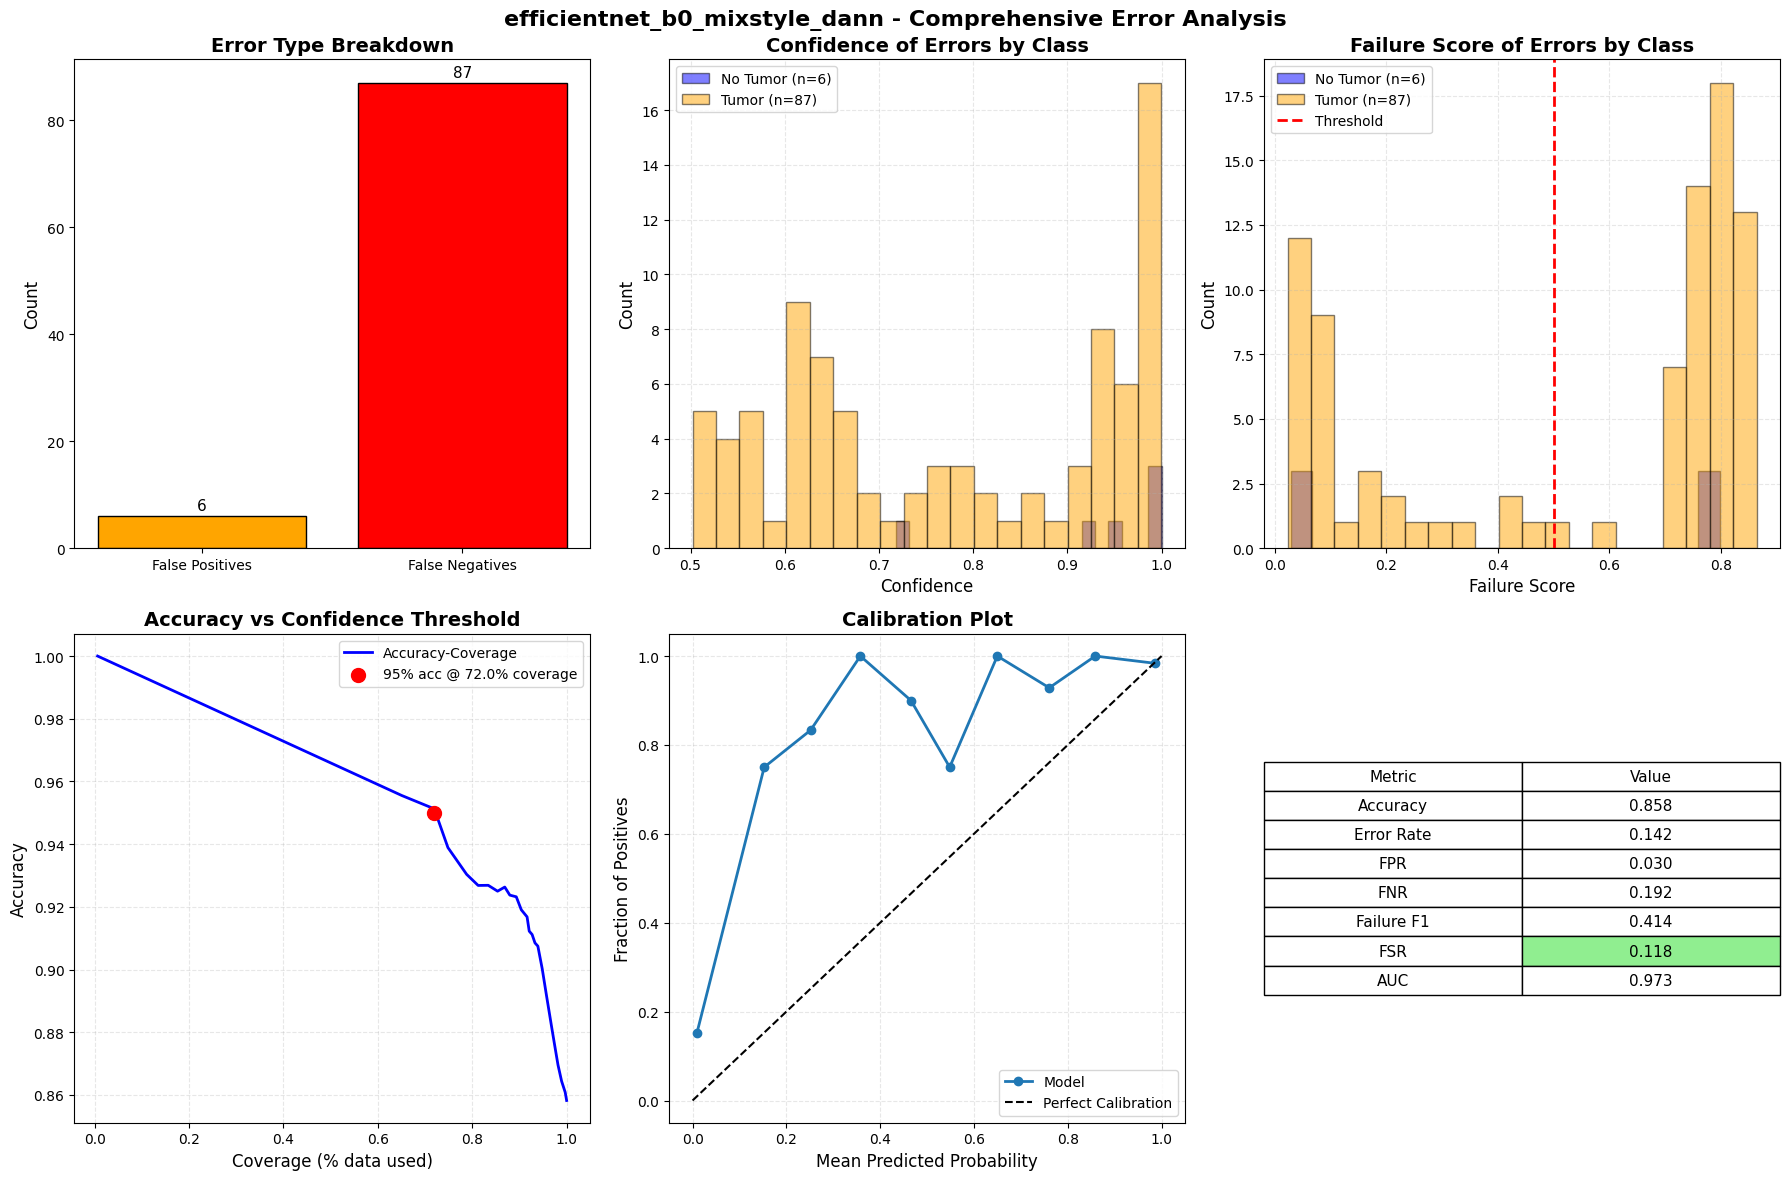

✅ Saved comprehensive error analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/efficientnet_b0_mixstyle_dann_error_analysis.png

✅ Completed efficientnet_b0_mixstyle_dann
   Accuracy: 0.8582
   FSR: 0.3462
   Failure F1: 0.3835
   Class Threshold: 0.671
  🧹 After cleanup: 13.8GB free


🔹 Processing Model 4/6: convnext_tiny
Configuration:
  • MixStyle: False
  • DANN: True
  • Epochs: 30
  • Learning Rate: 0.0001
  🔒 Seeds reset to 42
  🧹 GPU: 13.8GB free / 14.6GB total

🔧 Building model with backbone: convnext_tiny
  🔄 Loading timm model: convnext_tiny
  ✅ Detected feature dimension: 768
  📊 Using num_features: 768
  ✅ Classification head: 768 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initialization
  ✅ Domain classifier: 768 → 256 → 2

Diagnosing failure head: 100%|██████████| 15/15 [00:06<00:00,  2.47it/s]



🔍 FAILURE HEAD DIAGNOSTIC

📊 Basic Statistics:
   Mean: 0.1866
   Std: 0.3024
   Min: 0.0206
   Max: 0.8101
   % > 0.1: 22.3%
   % > 0.5: 20.6%
   % > 0.8: 0.6%

📊 Correct Predictions (n=476):
   Mean: 0.1832
   Std: 0.3000
   Median: 0.0272

📊 Incorrect Predictions (n=4):
   Mean: 0.5955
   Std: 0.3117
   Median: 0.7744

📊 T-test (correct vs incorrect):
   t-statistic: -2.7310
   p-value: 0.0065
   ✅ Failure head IS differentiating correct/incorrect predictions!

📊 Correlation with uncertainty (1-confidence): 0.0884
   ❌ No correlation with uncertainty


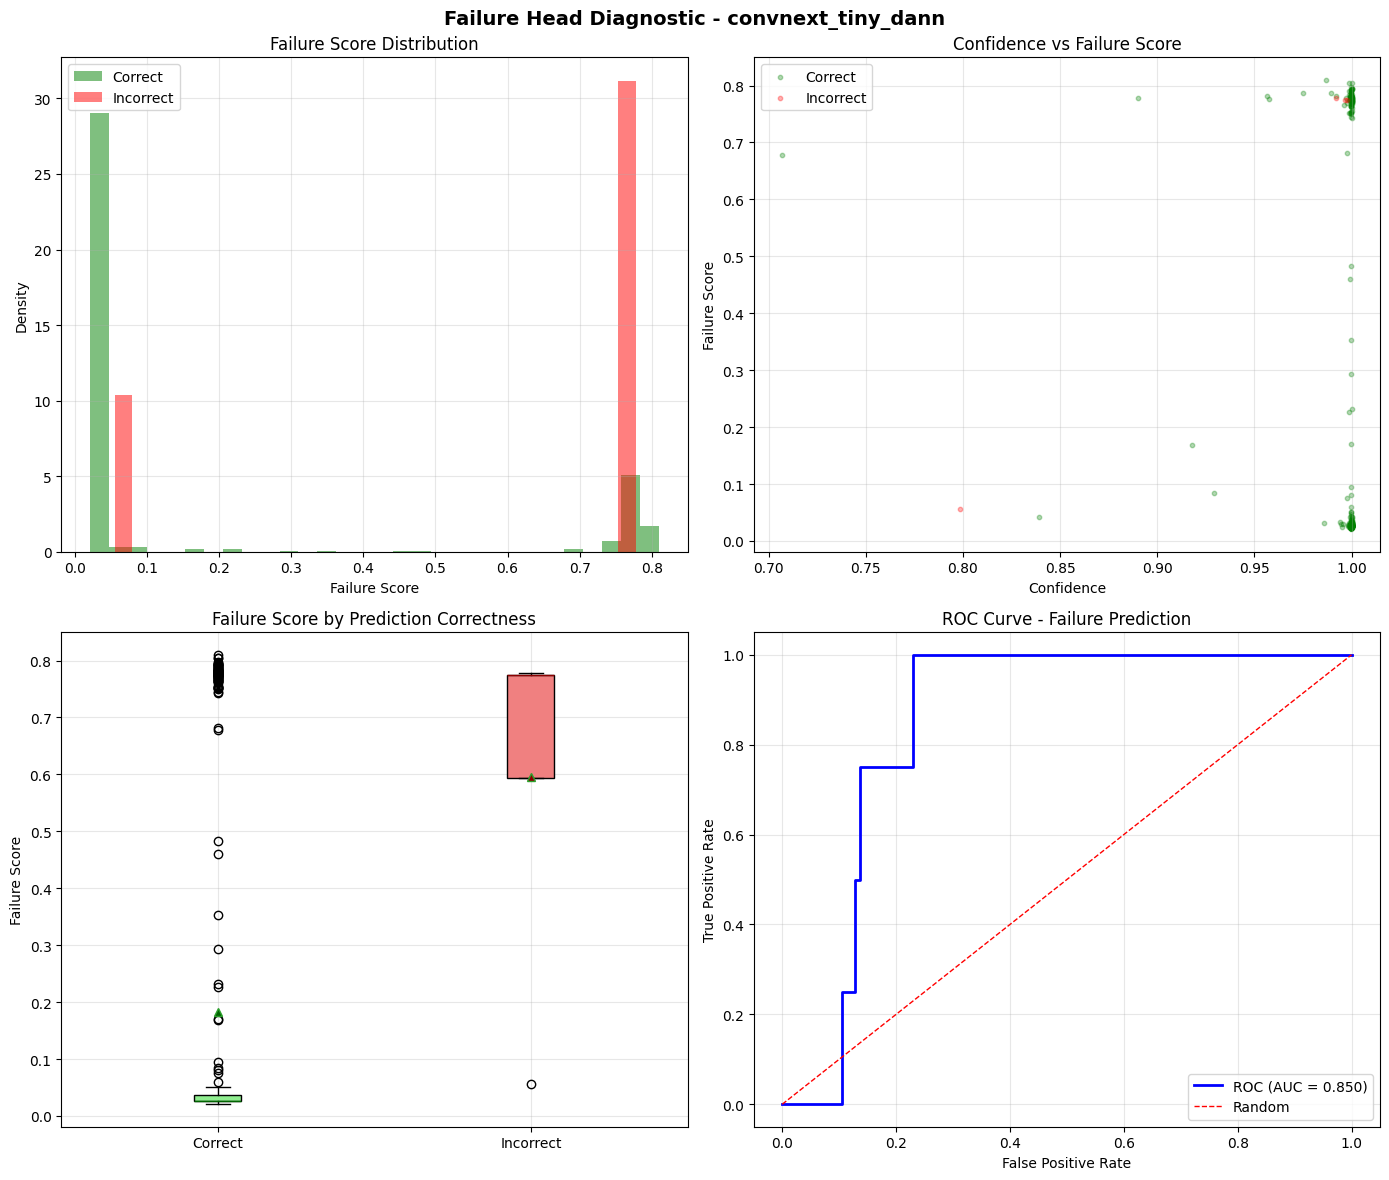


🔍 Checking for failure head collapse...

🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC
Mean score: 0.1870
Std deviation: 0.3047
Unique values: 480
Min score: 0.0214
Max score: 0.8264

Correct predictions:
  Mean: 0.1836
  Std: 0.3023
Incorrect predictions:
  Mean: 0.5899
  Std: 0.3163

Collapse detected: ✅ NO

✅ Failure head diagnostics complete - no auto-retraining performed
   • Correlation: 0.088
   • Std: 0.3024
   • Status: WEAK

🔧 Calibrating classification threshold...

📊 Threshold Calibration Results:
   Target Sensitivity: 0.85
   Optimal Threshold: 0.541
   Achieved Sensitivity: 0.988


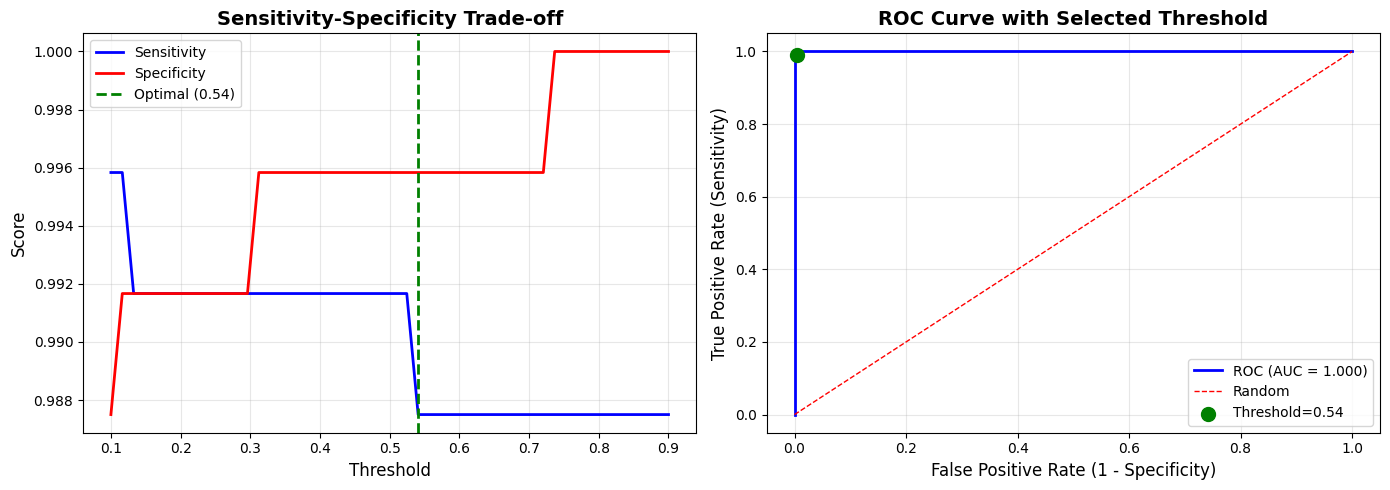

  ✅ Calibrated class threshold: 0.541

📊 Evaluating convnext_tiny_dann...

🔧 SAFE EVALUATION - No retraining performed

🔧 Before temperature scaling:
  • Correct mean: 0.1881
  • Incorrect mean: 0.7838
  • Separation: 0.5957

✅ Optimal temperature: 0.100

📊 After temperature scaling:
  • Correct mean: 0.2083
  • Incorrect mean: 1.0000
  • Separation: 0.7917

📊 Percentile Threshold Analysis:
  • Target recall: 80.0%
  • Optimal threshold: 0.0465
  • Achieved recall: 80.0%
  • Precision: 3.8%
  • F1 score: 0.072
  • Error scores range: [0.0465, 0.7806]
  • FSR with this threshold: 20.0%

📊 FINAL RESULTS WITH SAFE CALIBRATION
Temperature: 0.100
Threshold: 0.046525
Target recall: 80.0%

📈 Classification:
  • Accuracy: 71.3%
  • Precision: 0.9715
  • Recall: 0.6026
  • F1: 0.7439
  • AUC: 0.891
  • Sensitivity: 60.3%
  • Specificity: 96.1%
  • PPV: 97.2%
  • NPV: 52.0%

🛡️ Failure Metrics:
  • Failure Accuracy: 0.6448
  • Failure Precision: 0.2472
  • Failure Recall: 0.1170
  • Failure F1: 

Evaluating on target domain: 100%|██████████| 21/21 [00:05<00:00,  3.87it/s]



📊 Results for convnext_tiny_dann (Calibrated)
📈 Classification Metrics:
  Accuracy : 0.7088
  Precision: 0.8303
  Recall   : 0.7088
  F1-score : 0.7178
  AUC      : 0.8910

🏥 Clinical Metrics:
  Sensitivity (TPR): 0.5960
  Specificity (TNR): 0.9606
  PPV              : 0.9712
  NPV              : 0.5159

🛡️ Failure Prediction Metrics:
  Failure Accuracy : 0.6479
  Failure Precision: 0.3810
  Failure Recall   : 0.3351
  Failure F1       : 0.3565
  False Safe Rate  : 0.6649 ⚠️
  True Safe Rate   : 0.7763

🔧 Calibration Info:
  Class Threshold : 0.541
  Failure Threshold: 0.047

Confusion Matrix:
[[195   8]
 [183 270]]

Class-wise Performance:
  Class 0 (No Tumor): TN=195, FP=8
  Class 1 (Tumor):    TP=270, FN=183

📊 Generating all visualizations for convnext_tiny_dann...


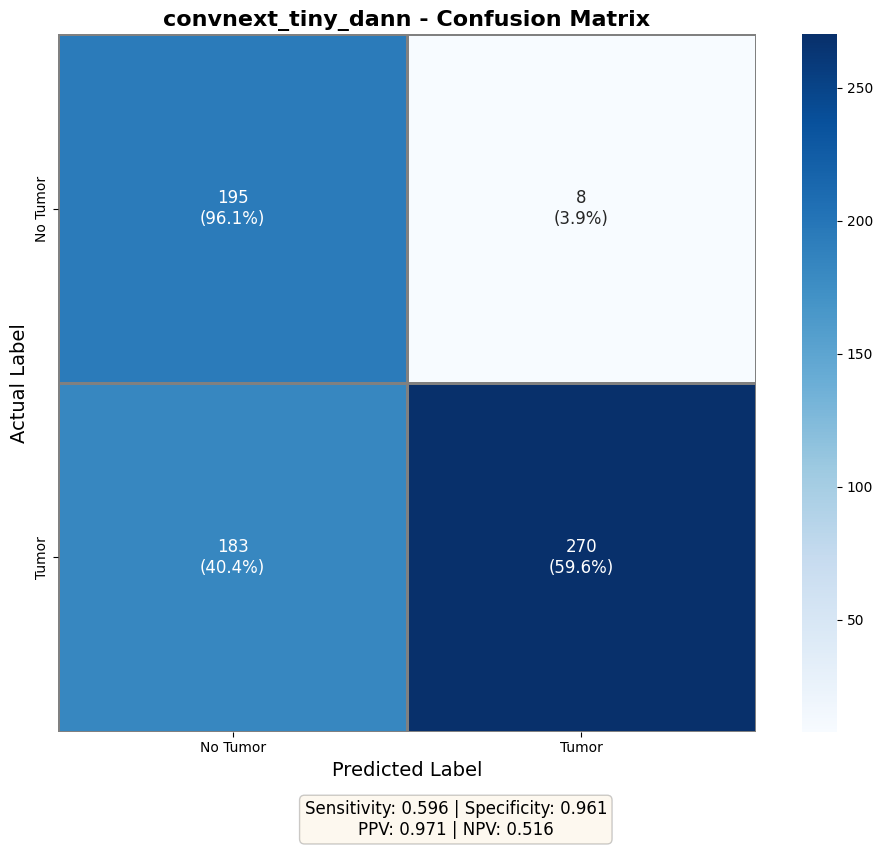

✅ Saved enhanced confusion matrix: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/confusion_matrices/convnext_tiny_dann_confusion_matrix.png


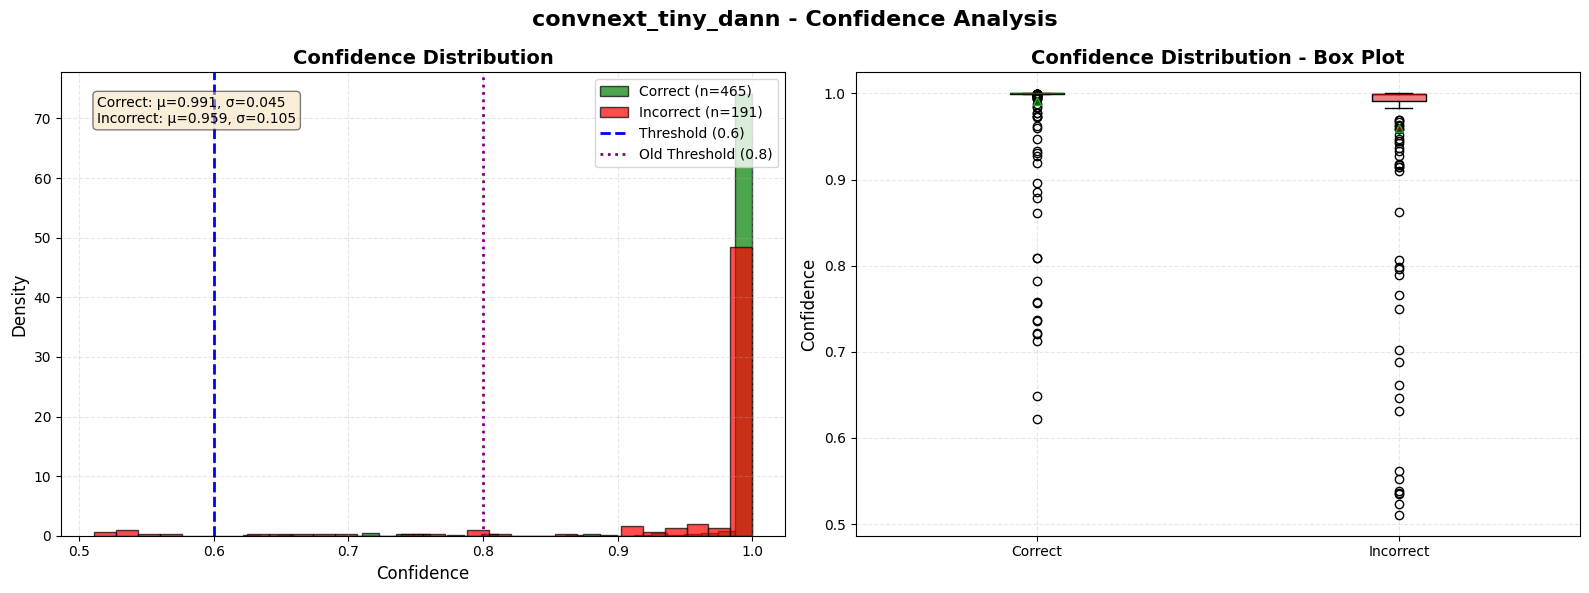

✅ Saved enhanced confidence distribution: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/convnext_tiny_dann_confidence_dist.png


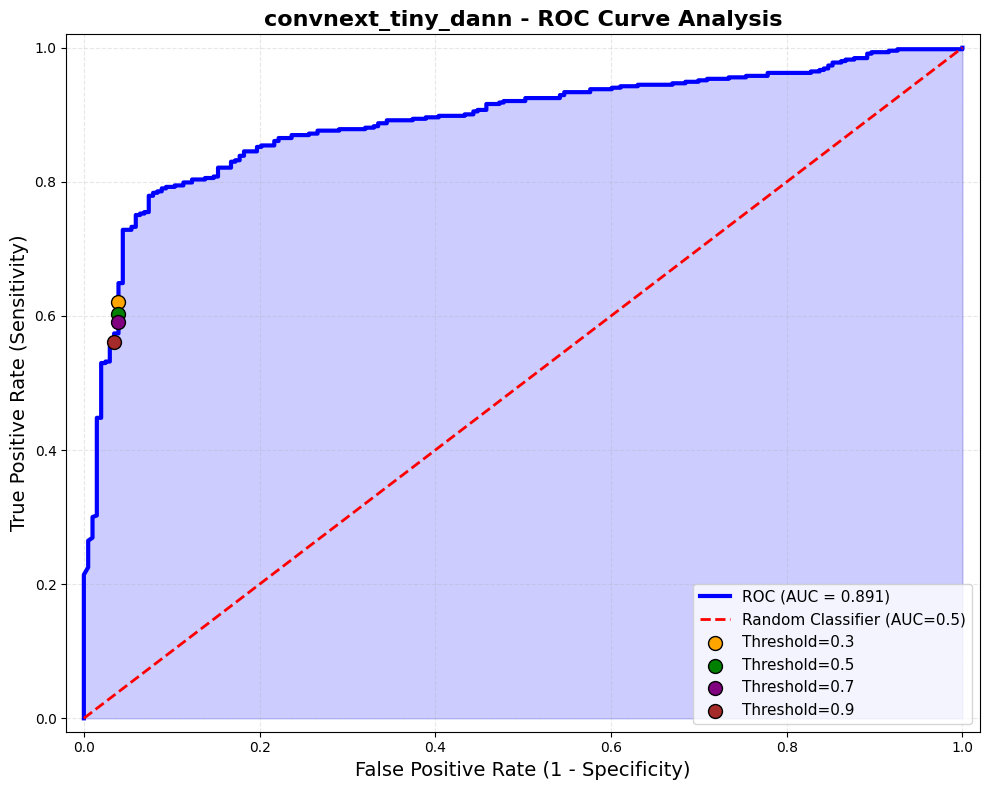

✅ Saved enhanced ROC curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/convnext_tiny_dann_roc_curve.png


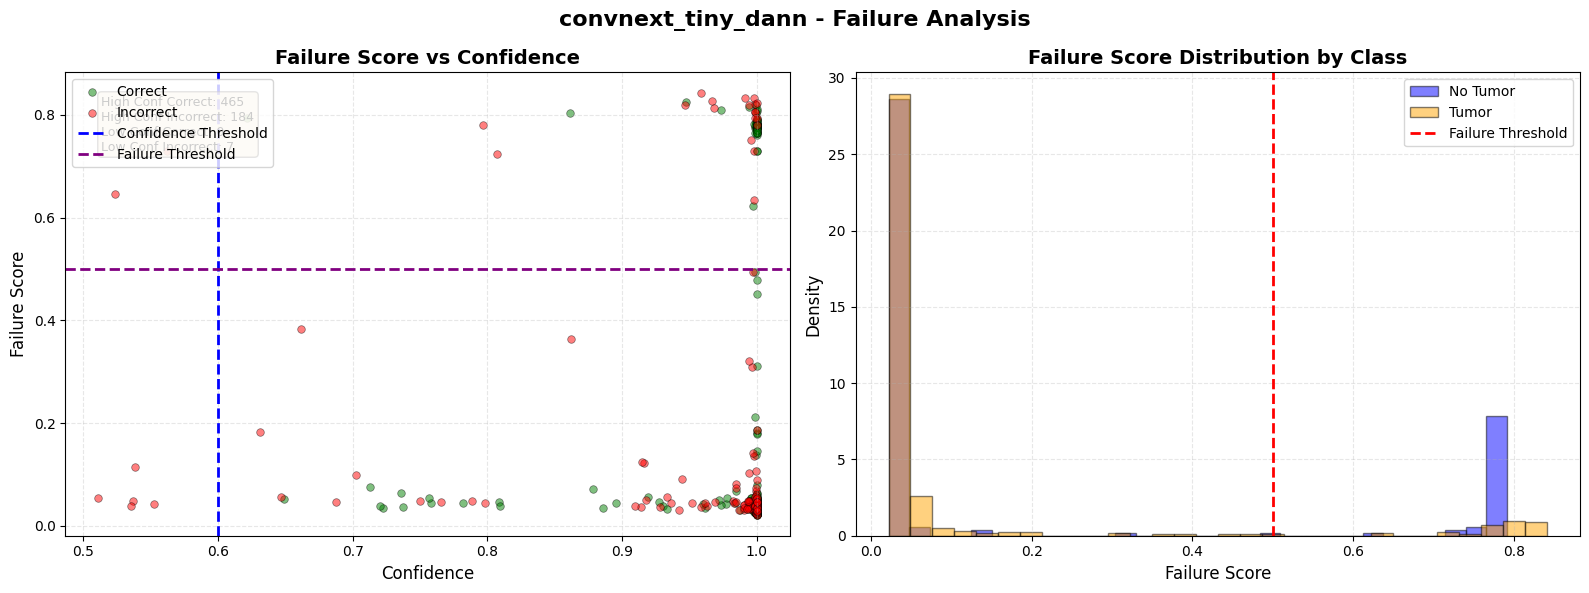

✅ Saved enhanced failure analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/convnext_tiny_dann_failure_analysis.png


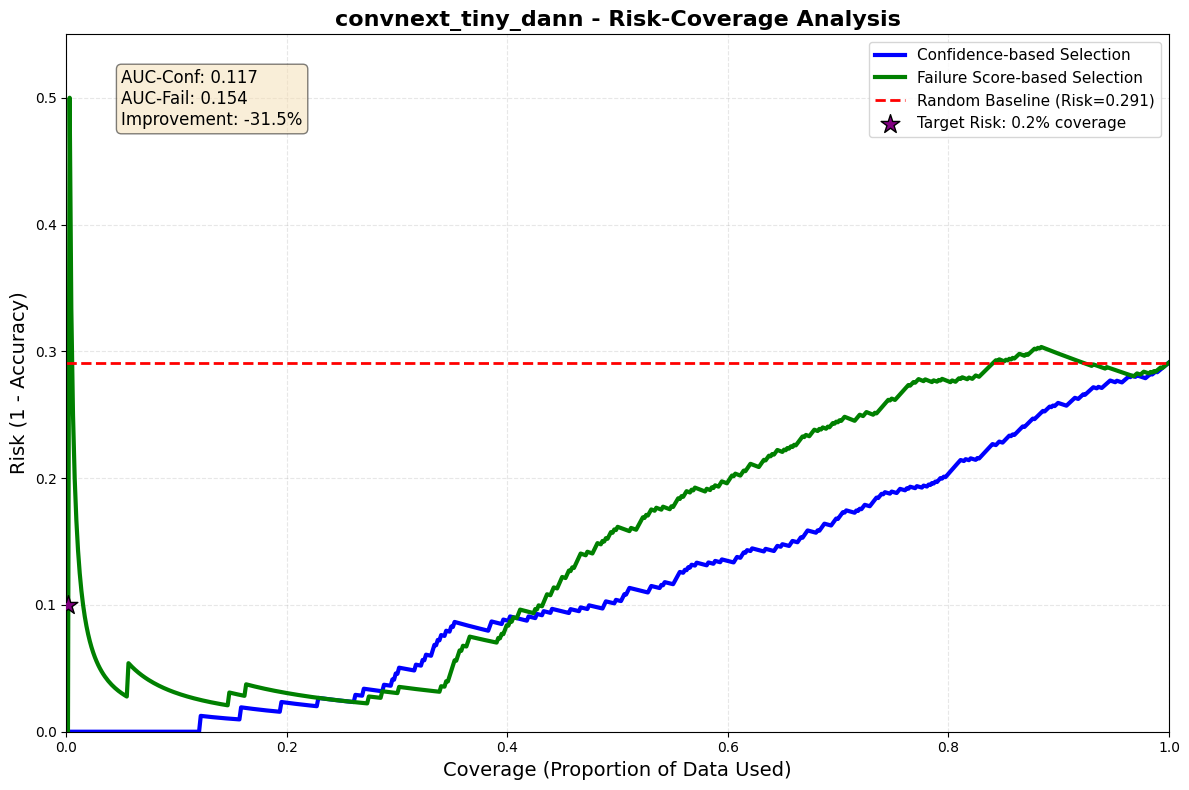

✅ Saved enhanced risk-coverage curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/convnext_tiny_dann_risk_coverage.png


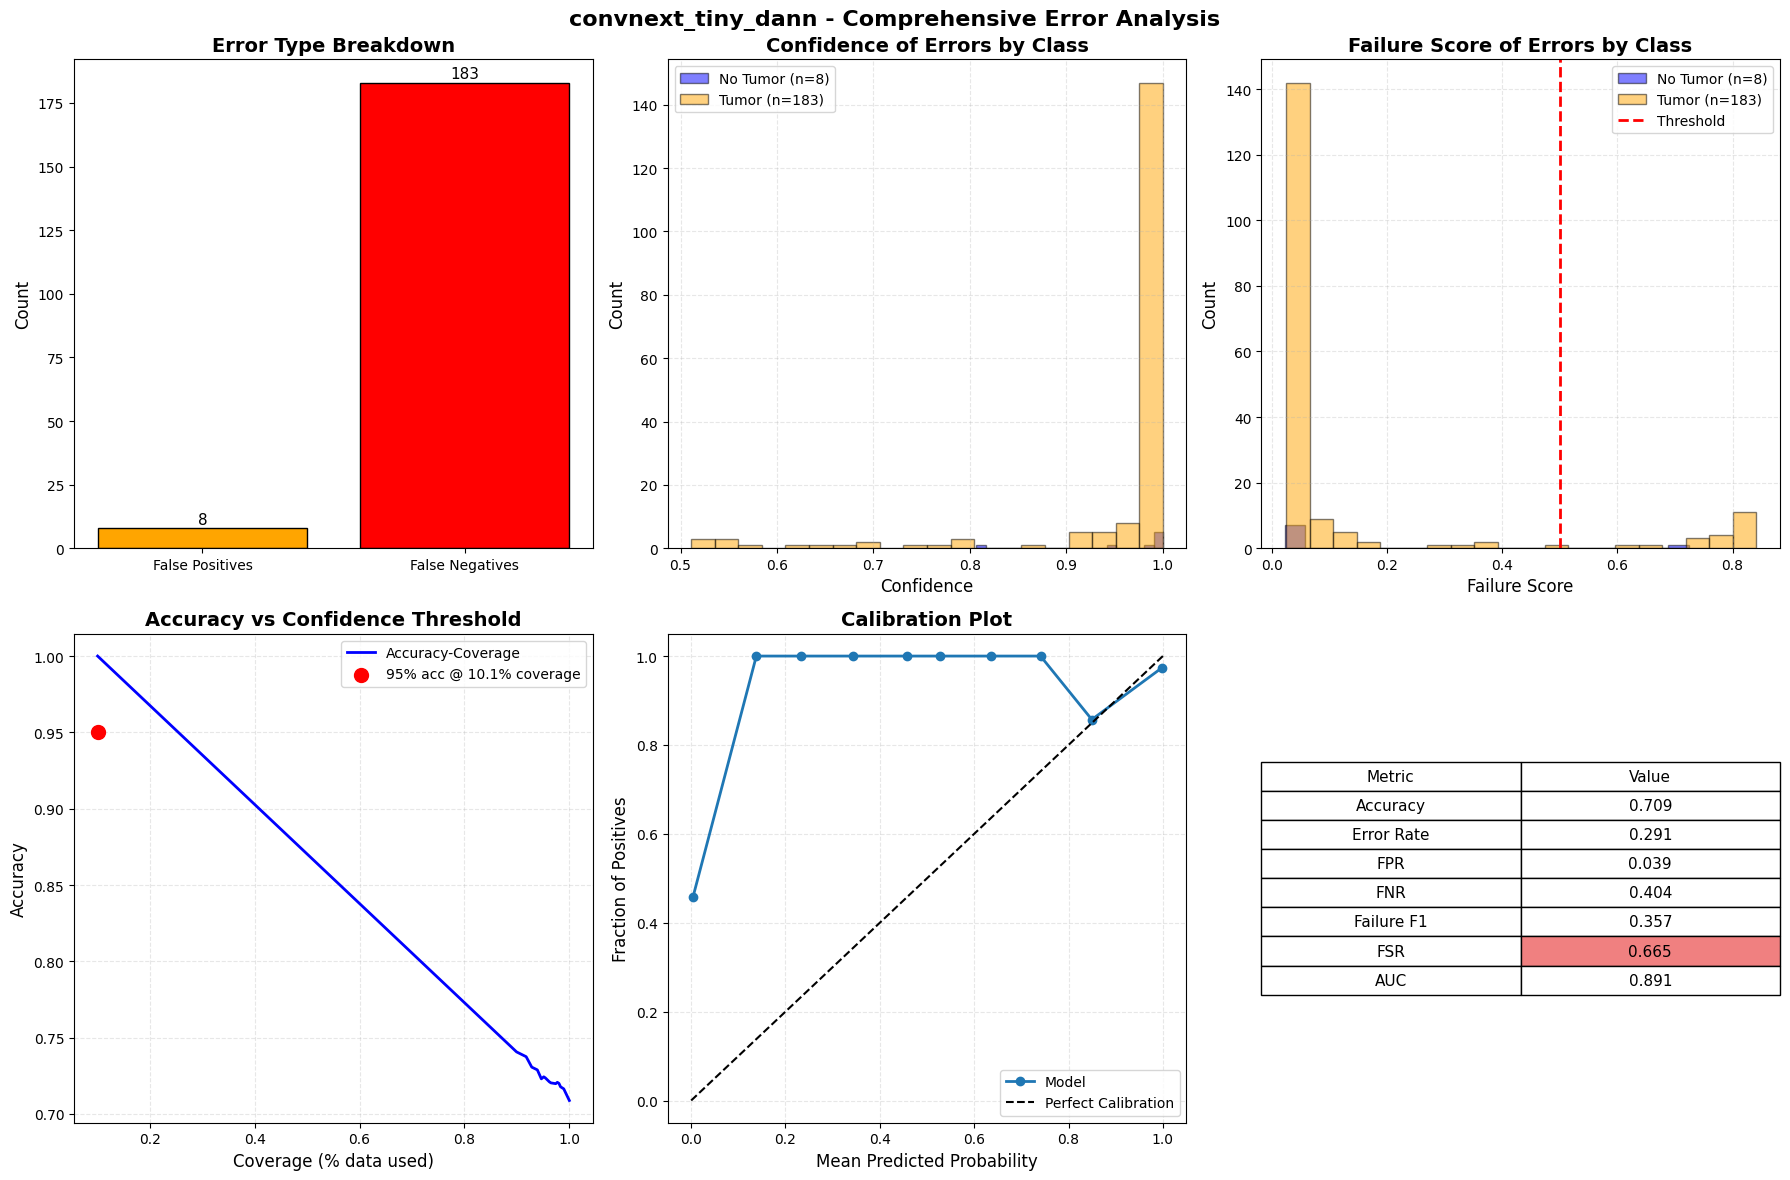

✅ Saved comprehensive error analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/convnext_tiny_dann_error_analysis.png

✅ Completed convnext_tiny_dann
   Accuracy: 0.7088
   FSR: 0.8830
   Failure F1: 0.1588
   Class Threshold: 0.541
  🧹 After cleanup: 13.8GB free


🔹 Processing Model 5/6: swin_tiny_patch4_window7_224
Configuration:
  • MixStyle: False
  • DANN: True
  • Epochs: 30
  • Learning Rate: 5e-05
  🔒 Seeds reset to 42
  🧹 GPU: 13.8GB free / 14.6GB total

🔧 Building model with backbone: swin_tiny_patch4_window7_224
  🔄 Loading timm model: swin_tiny_patch4_window7_224
  ✅ Detected feature dimension: 768
  📊 Using num_features: 768
  ✅ Classification head: 768 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initialization
  ✅ Domain cla

Diagnosing failure head: 100%|██████████| 15/15 [00:04<00:00,  3.21it/s]



🔍 FAILURE HEAD DIAGNOSTIC

📊 Basic Statistics:
   Mean: 0.0951
   Std: 0.2058
   Min: 0.0158
   Max: 0.8120
   % > 0.1: 12.1%
   % > 0.5: 9.0%
   % > 0.8: 0.2%

📊 Correct Predictions (n=476):
   Mean: 0.0953
   Std: 0.2066
   Median: 0.0232

📊 Incorrect Predictions (n=4):
   Mean: 0.0664
   Std: 0.0216
   Median: 0.0672

📊 T-test (correct vs incorrect):
   t-statistic: 0.2788
   p-value: 0.7805
   ⚠️ Failure head NOT differentiating correct/incorrect predictions!

📊 Correlation with uncertainty (1-confidence): 0.3501
   ✅ Good positive correlation with uncertainty!


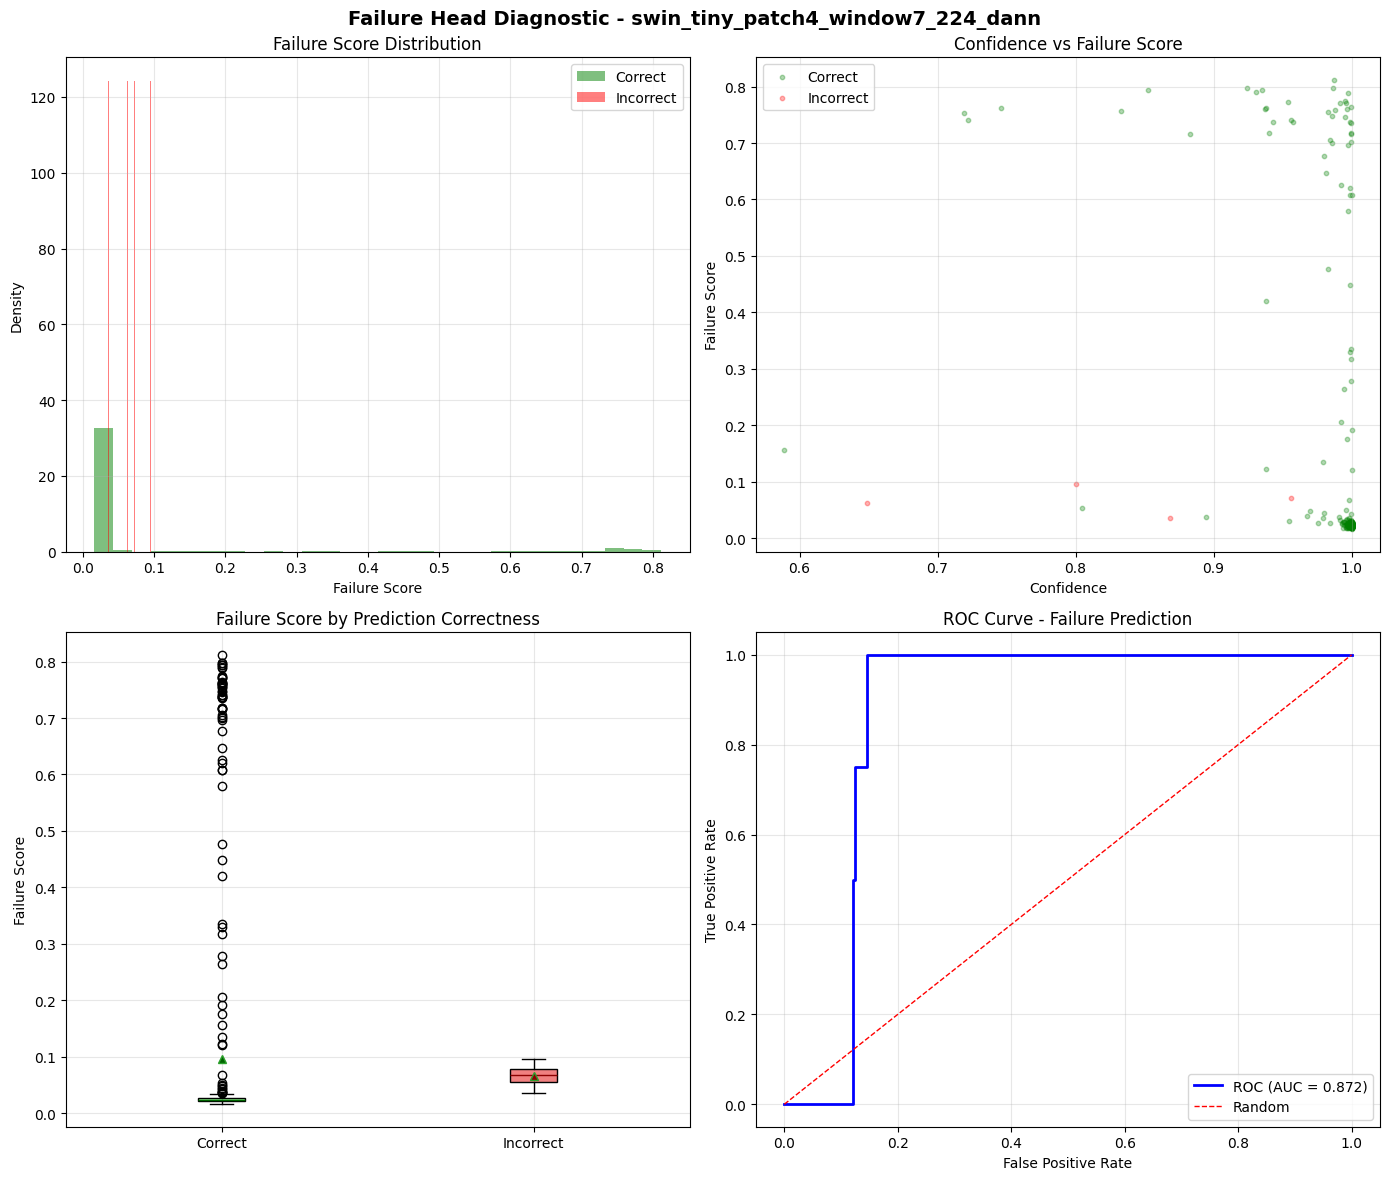


🔍 Checking for failure head collapse...

🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC
Mean score: 0.0866
Std deviation: 0.1939
Unique values: 480
Min score: 0.0170
Max score: 0.8014

Correct predictions:
  Mean: 0.0853
  Std: 0.1927
Incorrect predictions:
  Mean: 0.1954
  Std: 0.2508

Collapse detected: ✅ NO

✅ Failure head diagnostics complete - no auto-retraining performed
   • Correlation: 0.350
   • Std: 0.2058
   • Status: WEAK

🔧 Calibrating classification threshold...

📊 Threshold Calibration Results:
   Target Sensitivity: 0.85
   Optimal Threshold: 0.867
   Achieved Sensitivity: 0.950


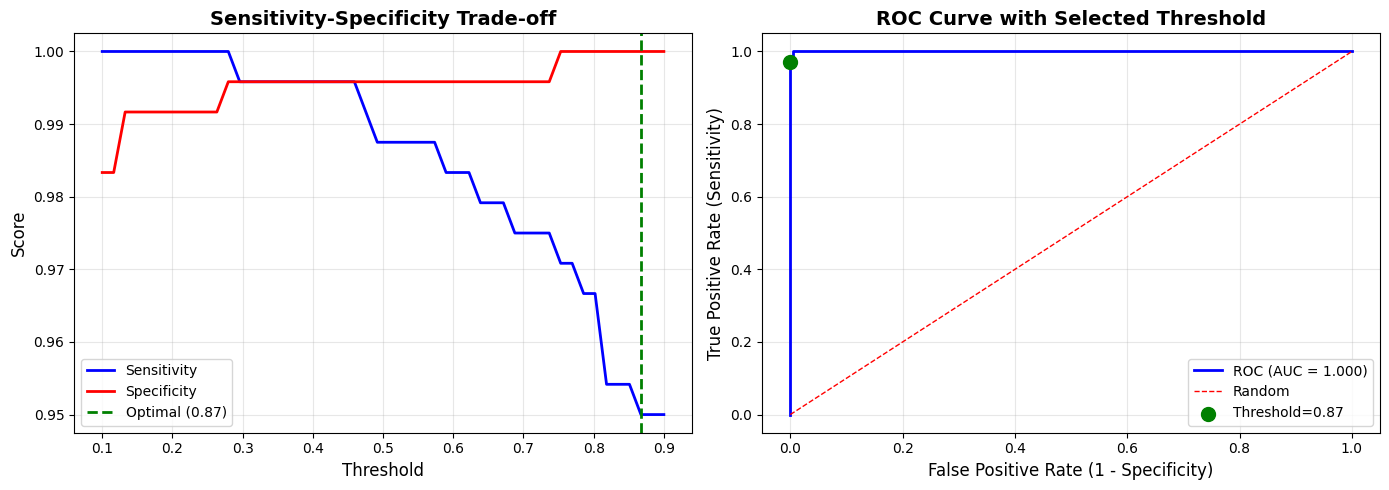

  ✅ Calibrated class threshold: 0.867

📊 Evaluating swin_tiny_patch4_window7_224_dann...

🔧 SAFE EVALUATION - No retraining performed

🔧 Before temperature scaling:
  • Correct mean: 0.0888
  • Incorrect mean: 0.3398
  • Separation: 0.2510

✅ Optimal temperature: 0.121

📊 After temperature scaling:
  • Correct mean: 0.0876
  • Incorrect mean: 0.3999
  • Separation: 0.3123

📊 Percentile Threshold Analysis:
  • Target recall: 80.0%
  • Optimal threshold: 0.0492
  • Achieved recall: 66.7%
  • Precision: 6.3%
  • F1 score: 0.116
  • Error scores range: [0.0301, 0.1237]
  • FSR with this threshold: 33.3%

📊 FINAL RESULTS WITH SAFE CALIBRATION
Temperature: 0.121
Threshold: 0.049229
Target recall: 80.0%

📈 Classification:
  • Accuracy: 93.8%
  • Precision: 0.9769
  • Recall: 0.9316
  • F1: 0.9537
  • AUC: 0.978
  • Sensitivity: 93.2%
  • Specificity: 95.1%
  • PPV: 97.7%
  • NPV: 86.2%

🛡️ Failure Metrics:
  • Failure Accuracy: 0.7622
  • Failure Precision: 0.1892
  • Failure Recall: 0.8537
 

Evaluating on target domain: 100%|██████████| 21/21 [00:06<00:00,  3.40it/s]



📊 Results for swin_tiny_patch4_window7_224_dann (Calibrated)
📈 Classification Metrics:
  Accuracy : 0.9009
  Precision: 0.9173
  Recall   : 0.9009
  F1-score : 0.9035
  AUC      : 0.9778

🏥 Clinical Metrics:
  Sensitivity (TPR): 0.8720
  Specificity (TNR): 0.9655
  PPV              : 0.9826
  NPV              : 0.7717

🛡️ Failure Prediction Metrics:
  Failure Accuracy : 0.7256
  Failure Precision: 0.2553
  Failure Recall   : 0.9231
  Failure F1       : 0.4000
  False Safe Rate  : 0.0769 ⚠️
  True Safe Rate   : 0.7039

🔧 Calibration Info:
  Class Threshold : 0.867
  Failure Threshold: 0.049

Confusion Matrix:
[[196   7]
 [ 58 395]]

Class-wise Performance:
  Class 0 (No Tumor): TN=196, FP=7
  Class 1 (Tumor):    TP=395, FN=58

📊 Generating all visualizations for swin_tiny_patch4_window7_224_dann...


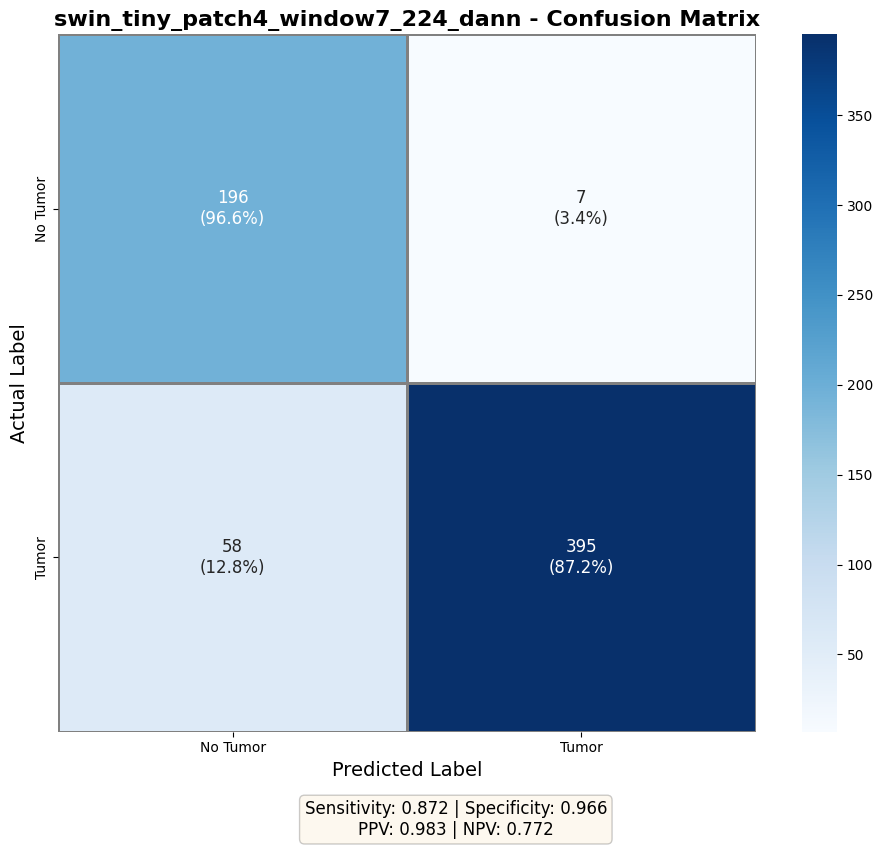

✅ Saved enhanced confusion matrix: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/confusion_matrices/swin_tiny_patch4_window7_224_dann_confusion_matrix.png


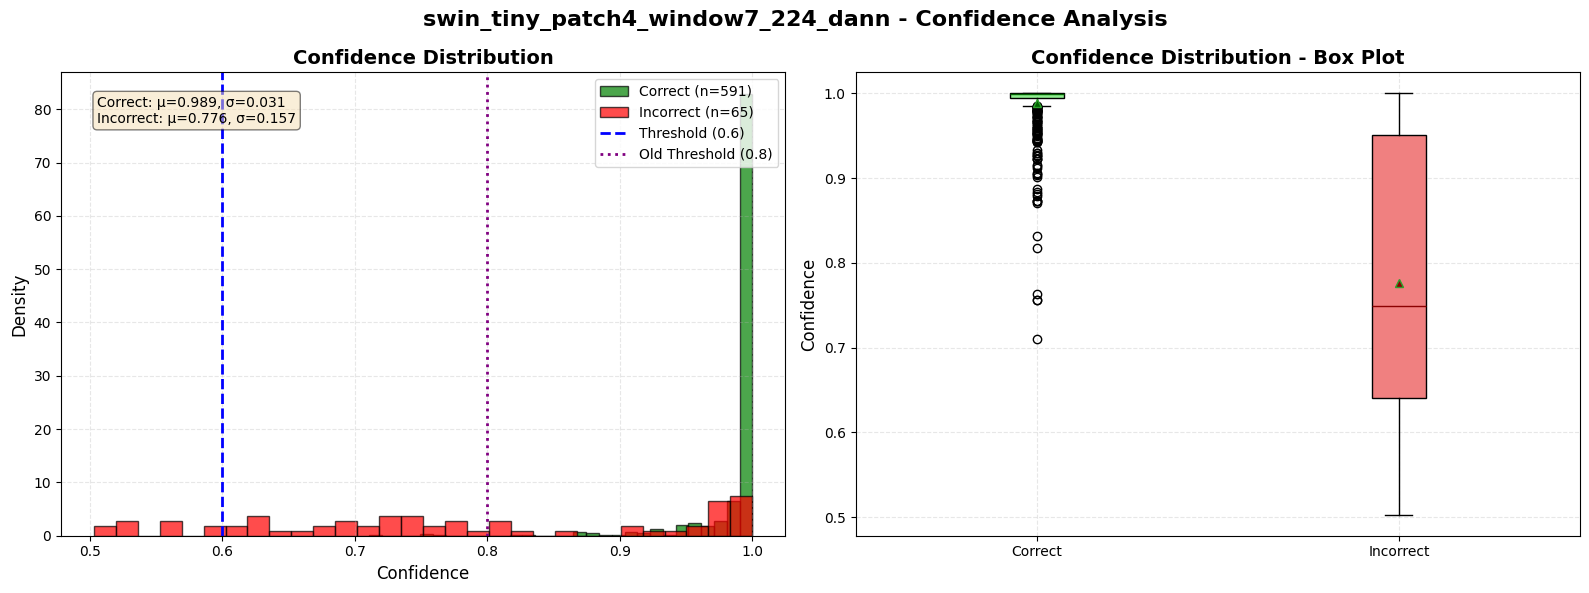

✅ Saved enhanced confidence distribution: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/swin_tiny_patch4_window7_224_dann_confidence_dist.png


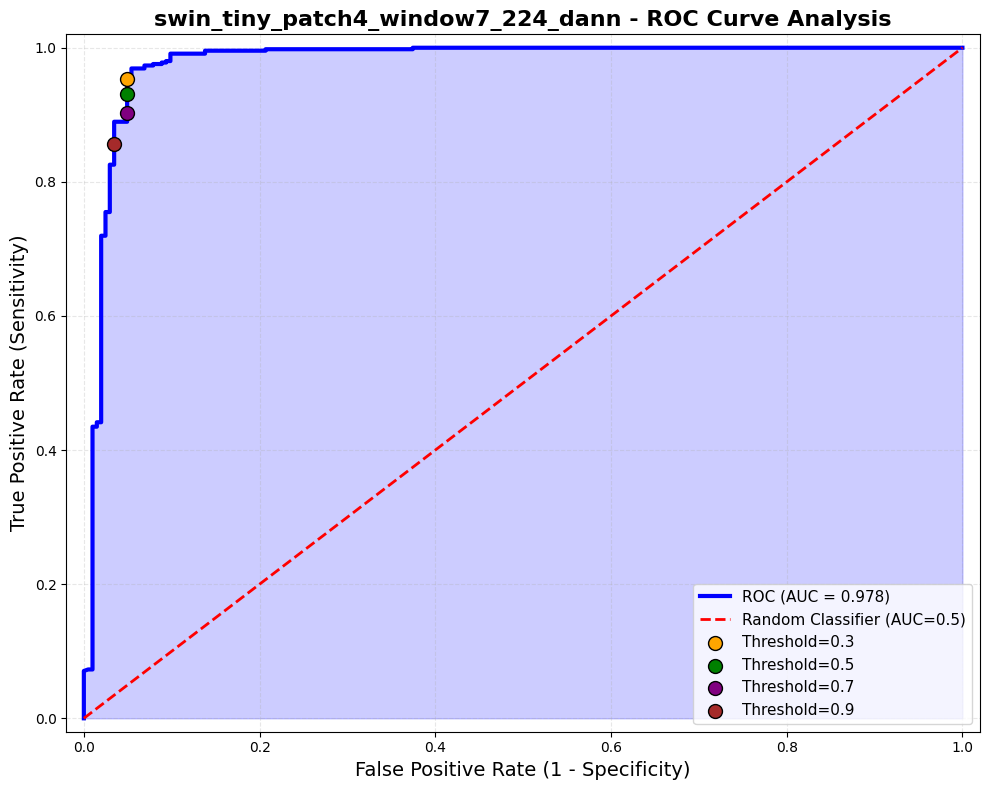

✅ Saved enhanced ROC curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/swin_tiny_patch4_window7_224_dann_roc_curve.png


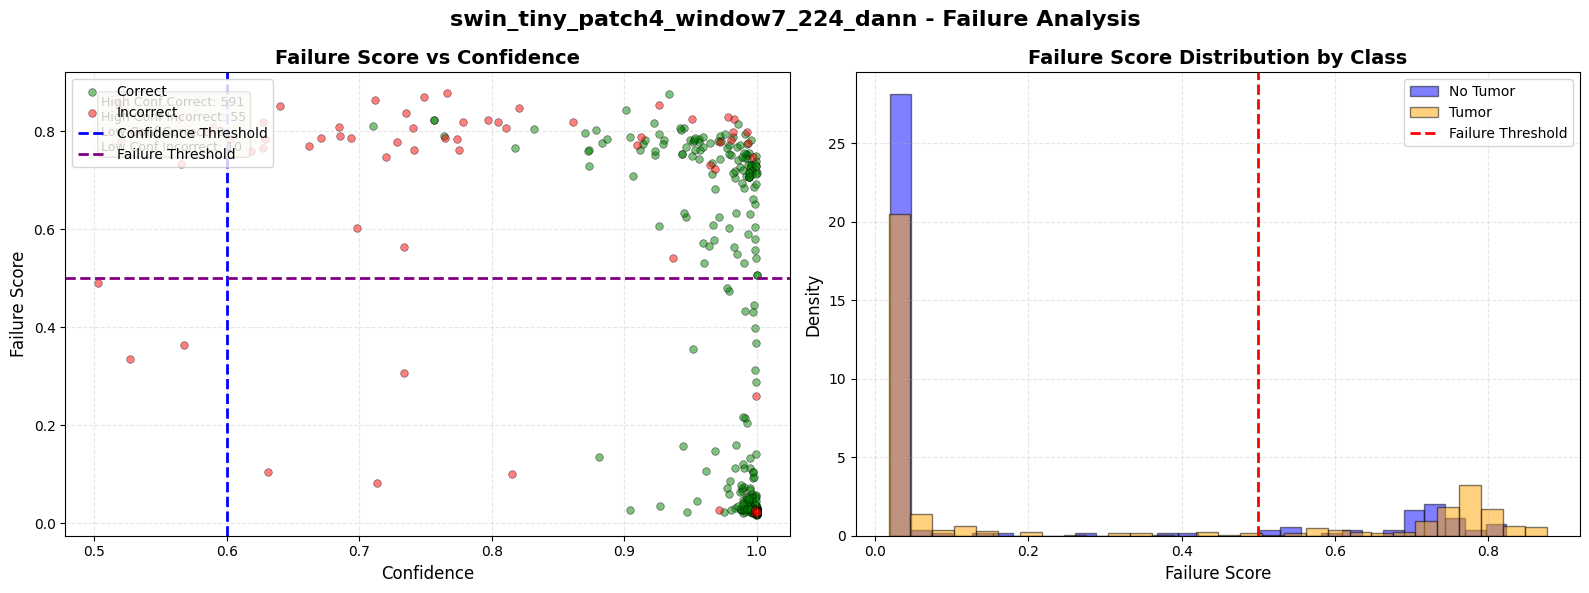

✅ Saved enhanced failure analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/swin_tiny_patch4_window7_224_dann_failure_analysis.png


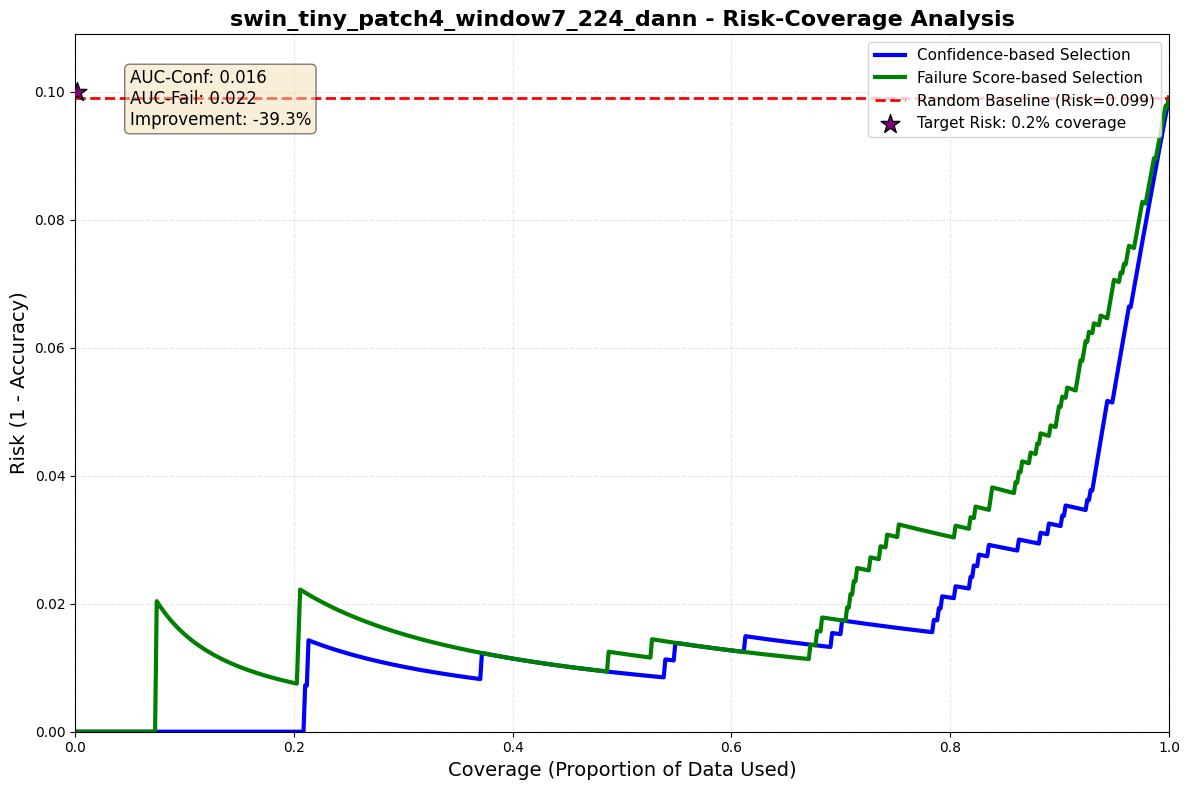

✅ Saved enhanced risk-coverage curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/swin_tiny_patch4_window7_224_dann_risk_coverage.png


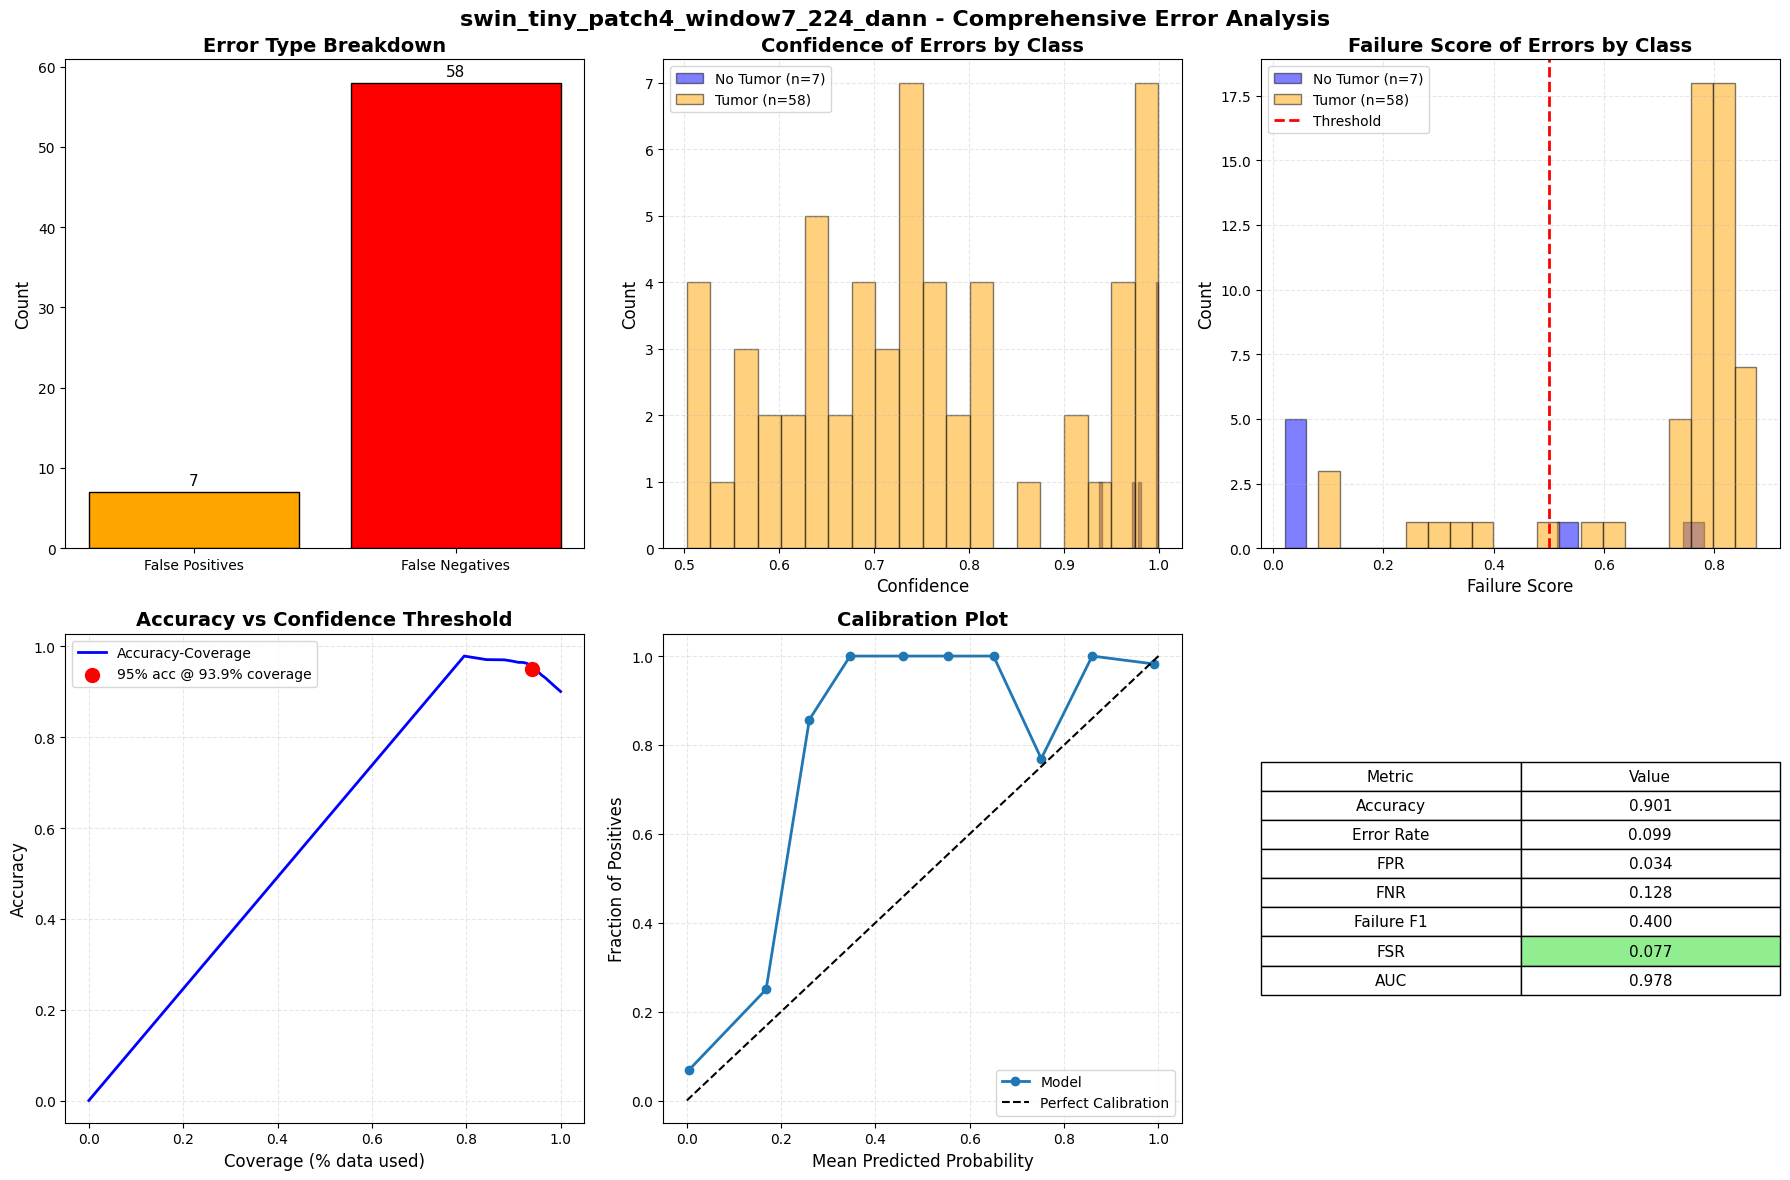

✅ Saved comprehensive error analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/swin_tiny_patch4_window7_224_dann_error_analysis.png

✅ Completed swin_tiny_patch4_window7_224_dann
   Accuracy: 0.9009
   FSR: 0.1463
   Failure F1: 0.3097
   Class Threshold: 0.867
  🧹 After cleanup: 13.8GB free


🔹 Processing Model 6/6: deit_small_patch16_224
Configuration:
  • MixStyle: False
  • DANN: True
  • Epochs: 30
  • Learning Rate: 5e-05
  🔒 Seeds reset to 42
  🧹 GPU: 13.8GB free / 14.6GB total

🔧 Building model with backbone: deit_small_patch16_224
  🔄 Loading timm model: deit_small_patch16_224
  ✅ Detected feature dimension: 384
  📊 Using num_features: 384
  ✅ Classification head: 384 → 1024 → 2
  ✅ LayerNorm failure head initialized:
      • LayerNorm (consistent train/eval behavior)
      • LeakyReLU (0.2) to prevent dead neurons
      • 🆕 Dropout(0.3) for generalization
      • Residual connection for gradient flow
      • Xavier initialization
  

Diagnosing failure head: 100%|██████████| 15/15 [00:06<00:00,  2.42it/s]



🔍 FAILURE HEAD DIAGNOSTIC

📊 Basic Statistics:
   Mean: 0.1059
   Std: 0.2240
   Min: 0.0221
   Max: 0.7997
   % > 0.1: 11.7%
   % > 0.5: 11.0%
   % > 0.8: 0.0%

📊 Correct Predictions (n=477):
   Mean: 0.1033
   Std: 0.2207
   Median: 0.0250

📊 Incorrect Predictions (n=3):
   Mean: 0.5121
   Std: 0.3411
   Median: 0.7276

📊 T-test (correct vs incorrect):
   t-statistic: -3.1767
   p-value: 0.0016
   ✅ Failure head IS differentiating correct/incorrect predictions!

📊 Correlation with uncertainty (1-confidence): 0.3297
   ✅ Good positive correlation with uncertainty!


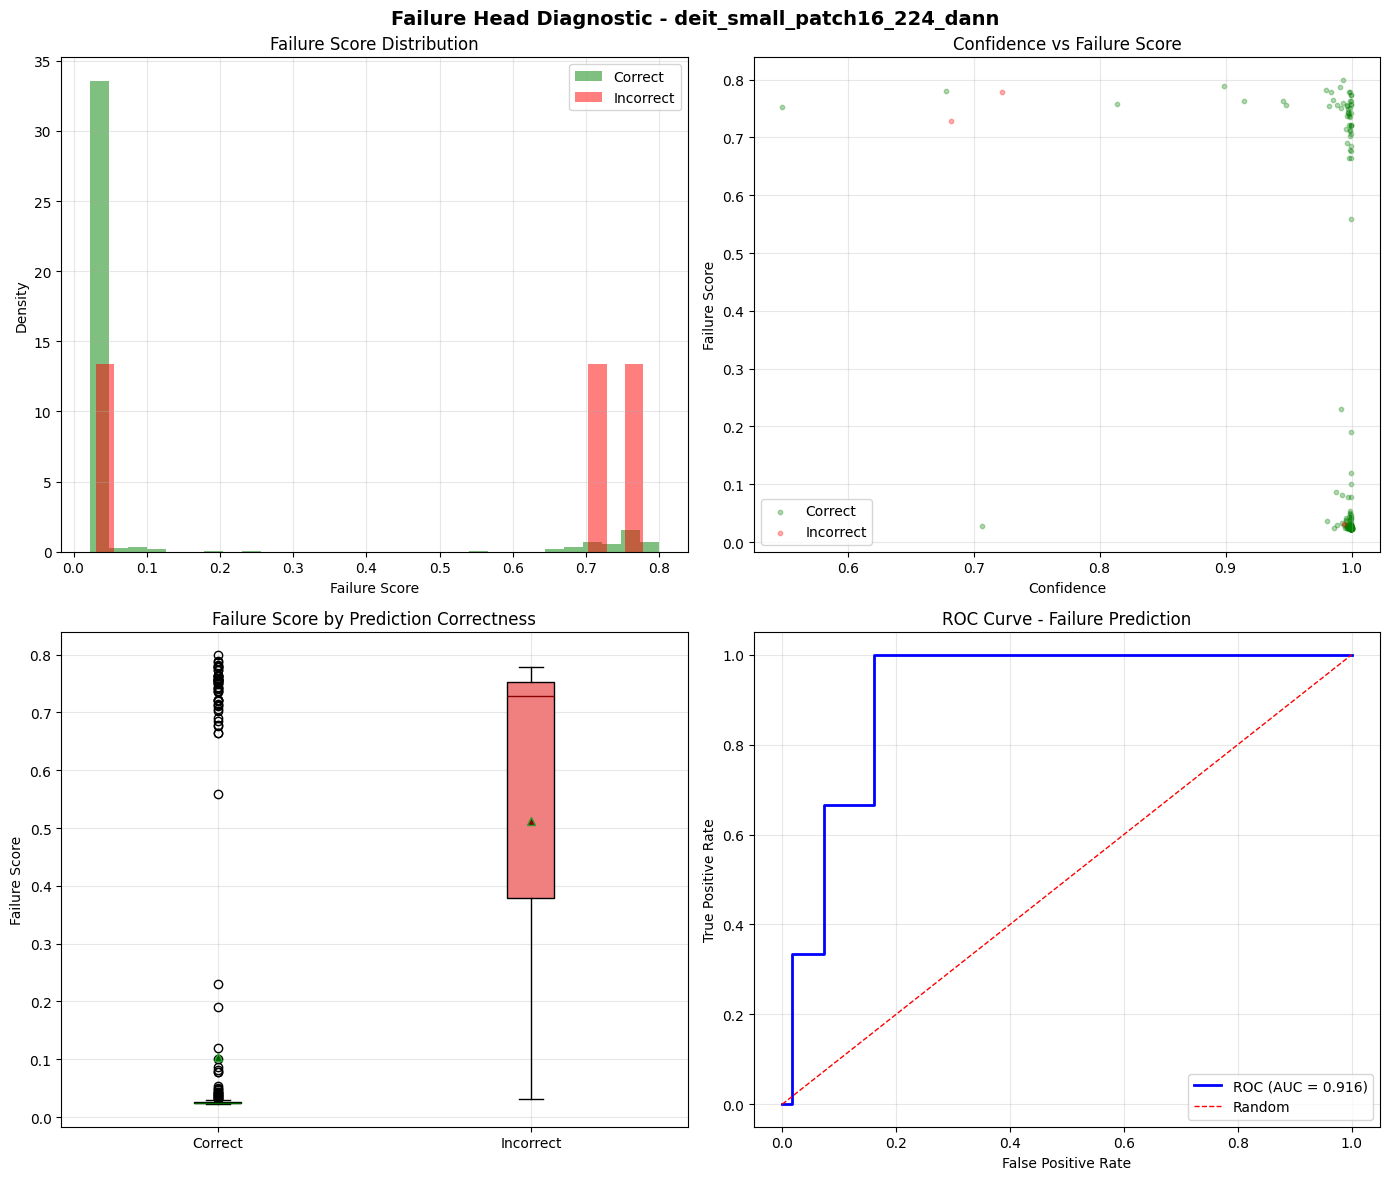


🔍 Checking for failure head collapse...

🔍 FAILURE HEAD COLLAPSE DIAGNOSTIC
Mean score: 0.1136
Std deviation: 0.2303
Unique values: 480
Min score: 0.0217
Max score: 0.7905

Correct predictions:
  Mean: 0.1098
  Std: 0.2259
Incorrect predictions:
  Mean: 0.7235
  Std: 0.0516

Collapse detected: ✅ NO

✅ Failure head diagnostics complete - no auto-retraining performed
   • Correlation: 0.330
   • Std: 0.2240
   • Status: HEALTHY

🔧 Calibrating classification threshold...

📊 Threshold Calibration Results:
   Target Sensitivity: 0.85
   Optimal Threshold: 0.769
   Achieved Sensitivity: 0.988


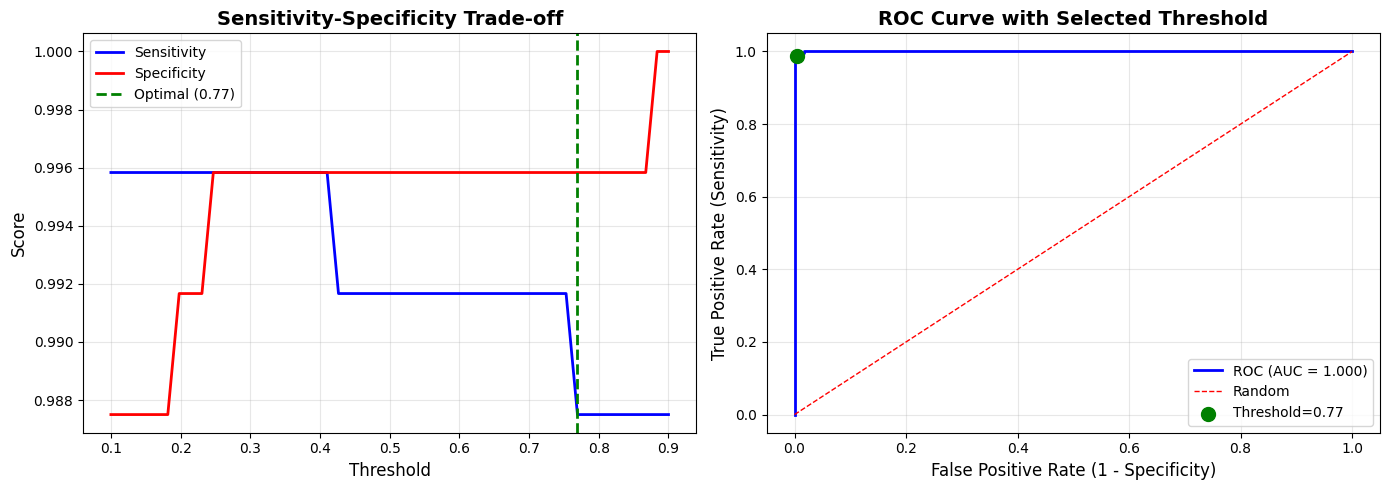

  ✅ Calibrated class threshold: 0.769

📊 Evaluating deit_small_patch16_224_dann...

🔧 SAFE EVALUATION - No retraining performed

🔧 Before temperature scaling:
  • Correct mean: 0.1111
  • Incorrect mean: 0.2817
  • Separation: 0.1706

✅ Optimal temperature: 0.147

📊 After temperature scaling:
  • Correct mean: 0.1111
  • Incorrect mean: 0.3333
  • Separation: 0.2222

📊 Percentile Threshold Analysis:
  • Target recall: 80.0%
  • Optimal threshold: 0.0245
  • Achieved recall: 50.0%
  • Precision: 0.3%
  • F1 score: 0.007
  • Error scores range: [0.0245, 0.0332]
  • FSR with this threshold: 50.0%

📊 FINAL RESULTS WITH SAFE CALIBRATION
Temperature: 0.147
Threshold: 0.024460
Target recall: 80.0%

📈 Classification:
  • Accuracy: 91.2%
  • Precision: 0.9759
  • Recall: 0.8940
  • F1: 0.9332
  • AUC: 0.969
  • Sensitivity: 89.4%
  • Specificity: 95.1%
  • PPV: 97.6%
  • NPV: 80.1%

🛡️ Failure Metrics:
  • Failure Accuracy: 0.7942
  • Failure Precision: 0.2638
  • Failure Recall: 0.7414
  • Fai

Evaluating on target domain: 100%|██████████| 21/21 [00:06<00:00,  3.43it/s]



📊 Results for deit_small_patch16_224_dann (Calibrated)
📈 Classification Metrics:
  Accuracy : 0.8567
  Precision: 0.8879
  Recall   : 0.8567
  F1-score : 0.8614
  AUC      : 0.9691

🏥 Clinical Metrics:
  Sensitivity (TPR): 0.8146
  Specificity (TNR): 0.9507
  PPV              : 0.9736
  NPV              : 0.6968

🛡️ Failure Prediction Metrics:
  Failure Accuracy : 0.2698
  Failure Precision: 0.1640
  Failure Recall   : 1.0000
  Failure F1       : 0.2819
  False Safe Rate  : 0.0000 ⚠️
  True Safe Rate   : 0.1477

🔧 Calibration Info:
  Class Threshold : 0.769
  Failure Threshold: 0.024

Confusion Matrix:
[[193  10]
 [ 84 369]]

Class-wise Performance:
  Class 0 (No Tumor): TN=193, FP=10
  Class 1 (Tumor):    TP=369, FN=84

📊 Generating all visualizations for deit_small_patch16_224_dann...


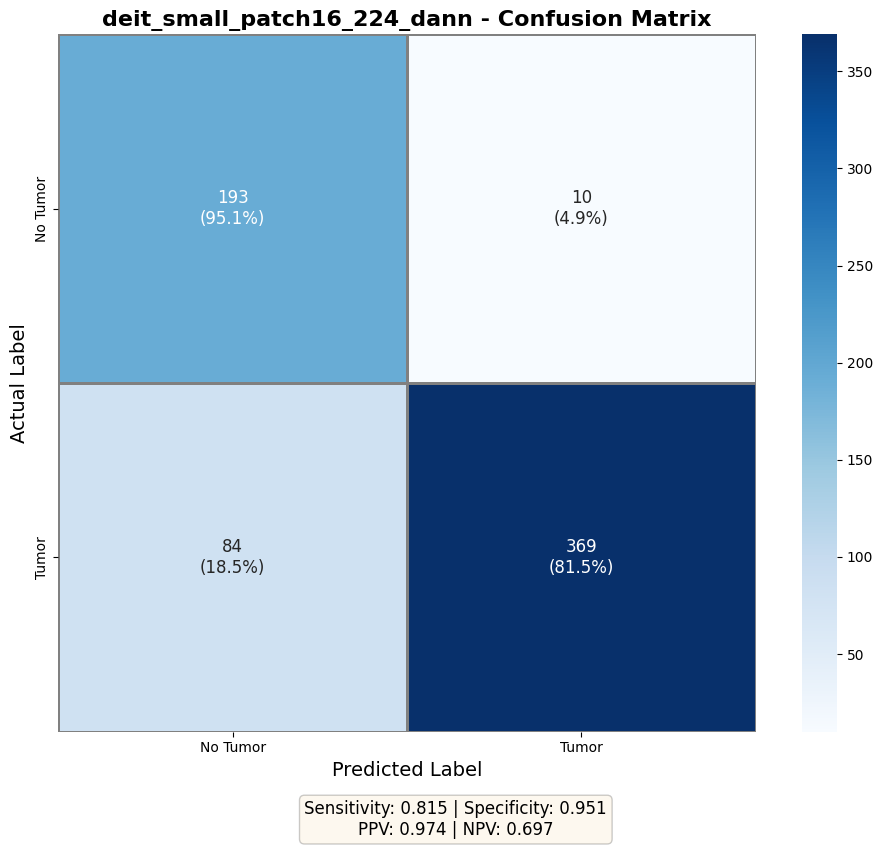

✅ Saved enhanced confusion matrix: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/confusion_matrices/deit_small_patch16_224_dann_confusion_matrix.png


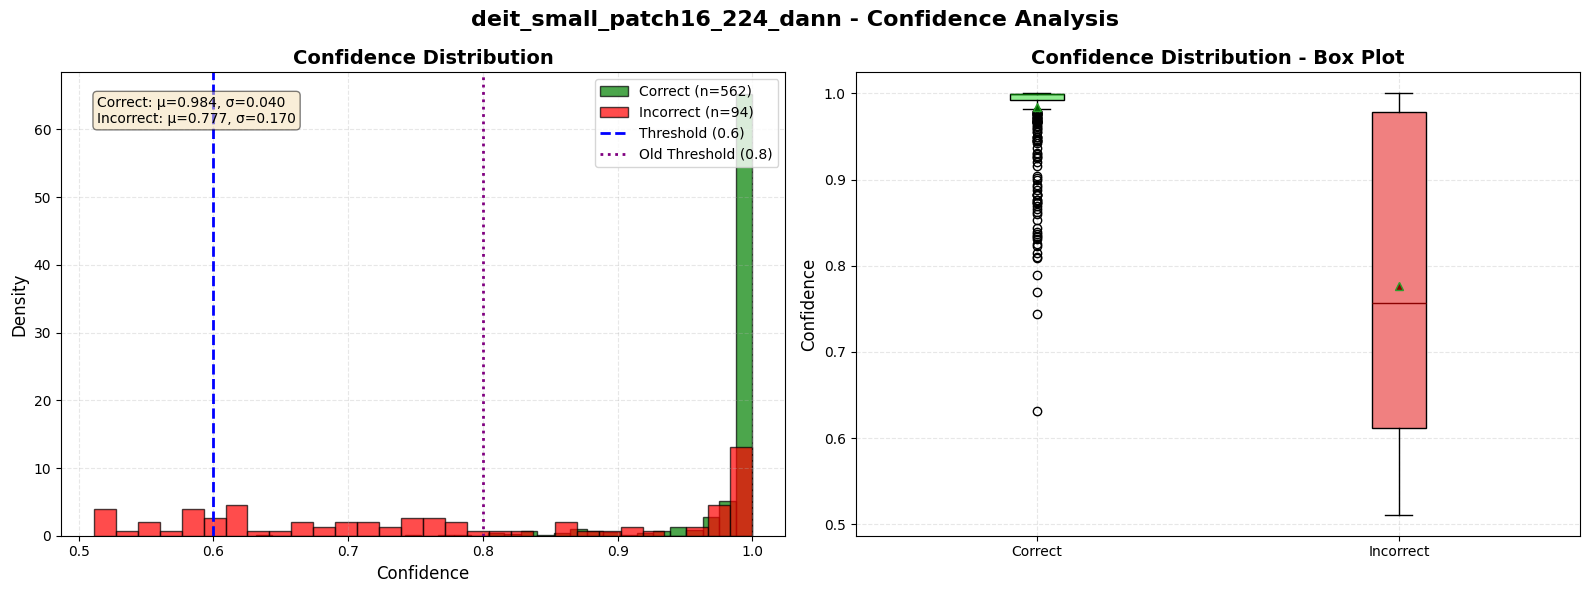

✅ Saved enhanced confidence distribution: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/deit_small_patch16_224_dann_confidence_dist.png


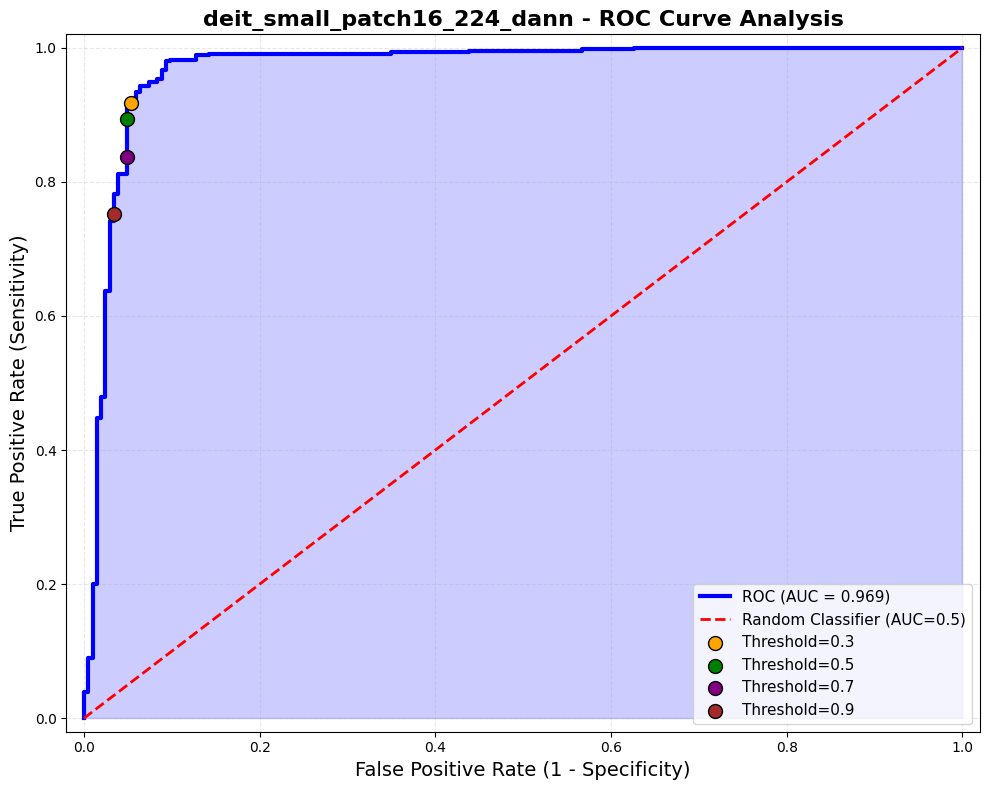

✅ Saved enhanced ROC curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/deit_small_patch16_224_dann_roc_curve.png


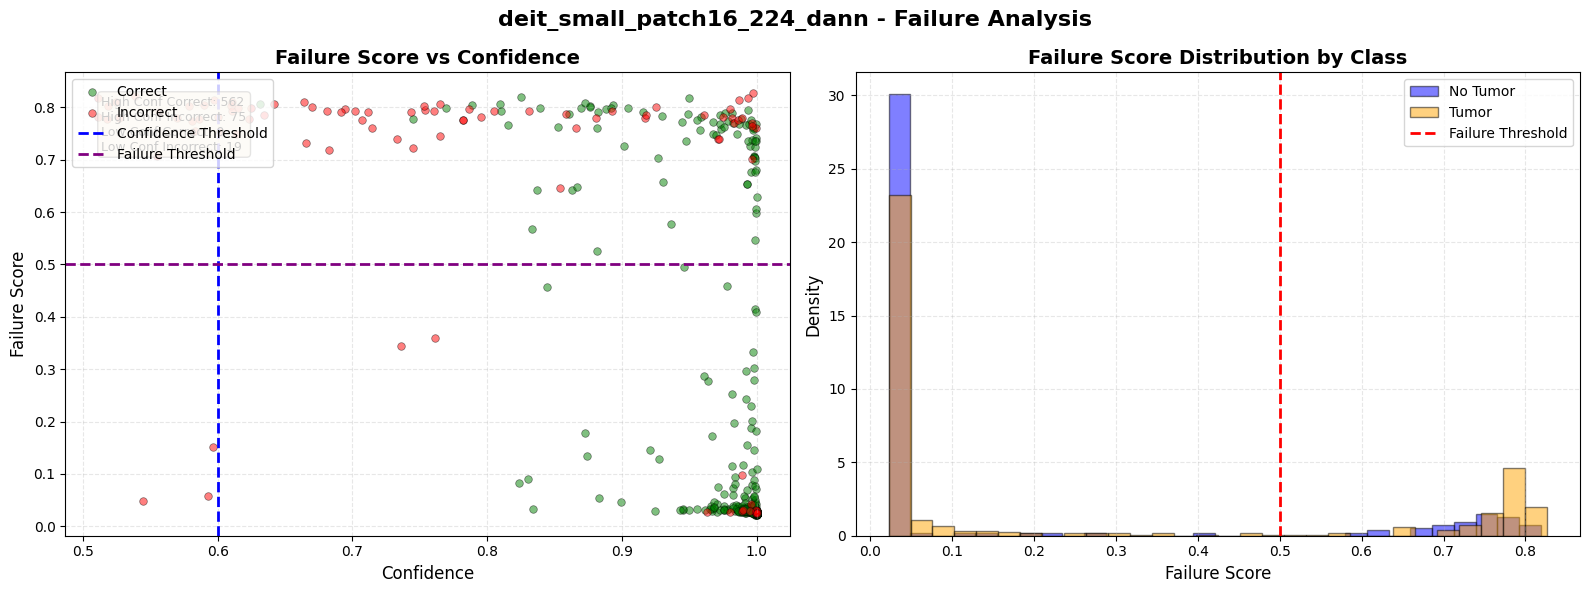

✅ Saved enhanced failure analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/deit_small_patch16_224_dann_failure_analysis.png


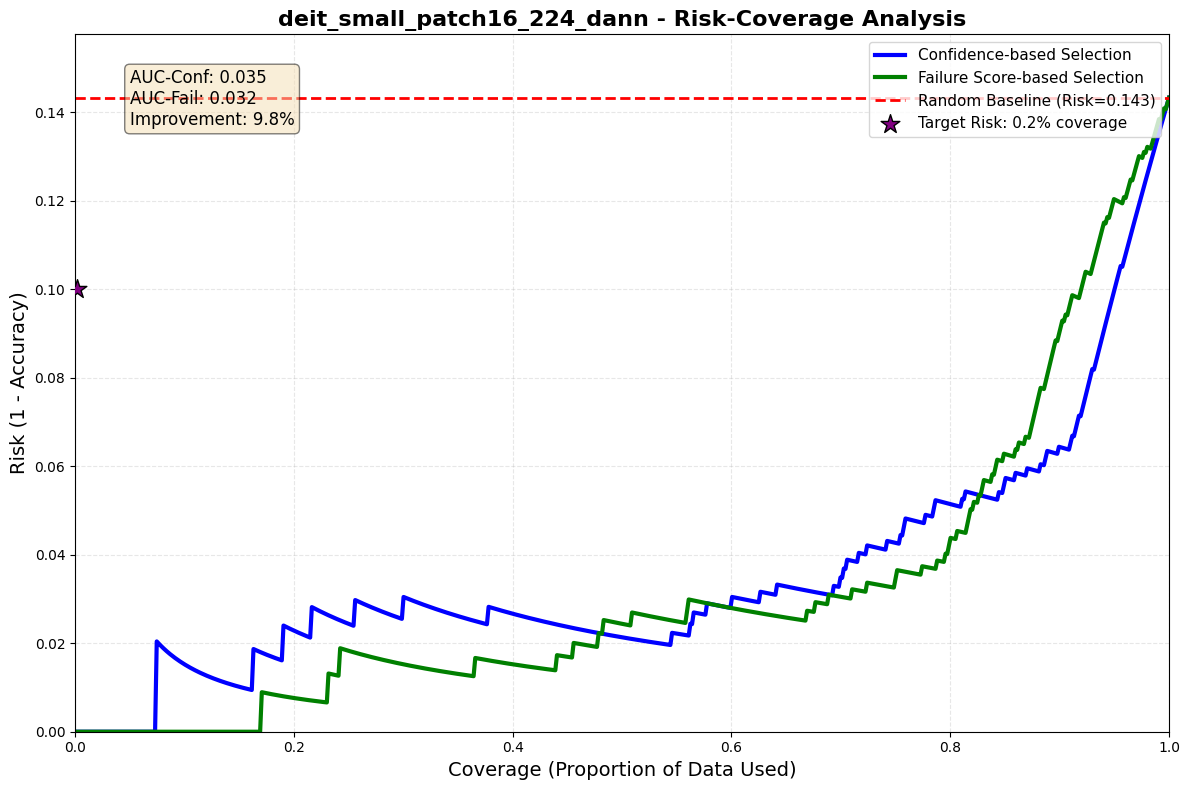

✅ Saved enhanced risk-coverage curve: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/deit_small_patch16_224_dann_risk_coverage.png


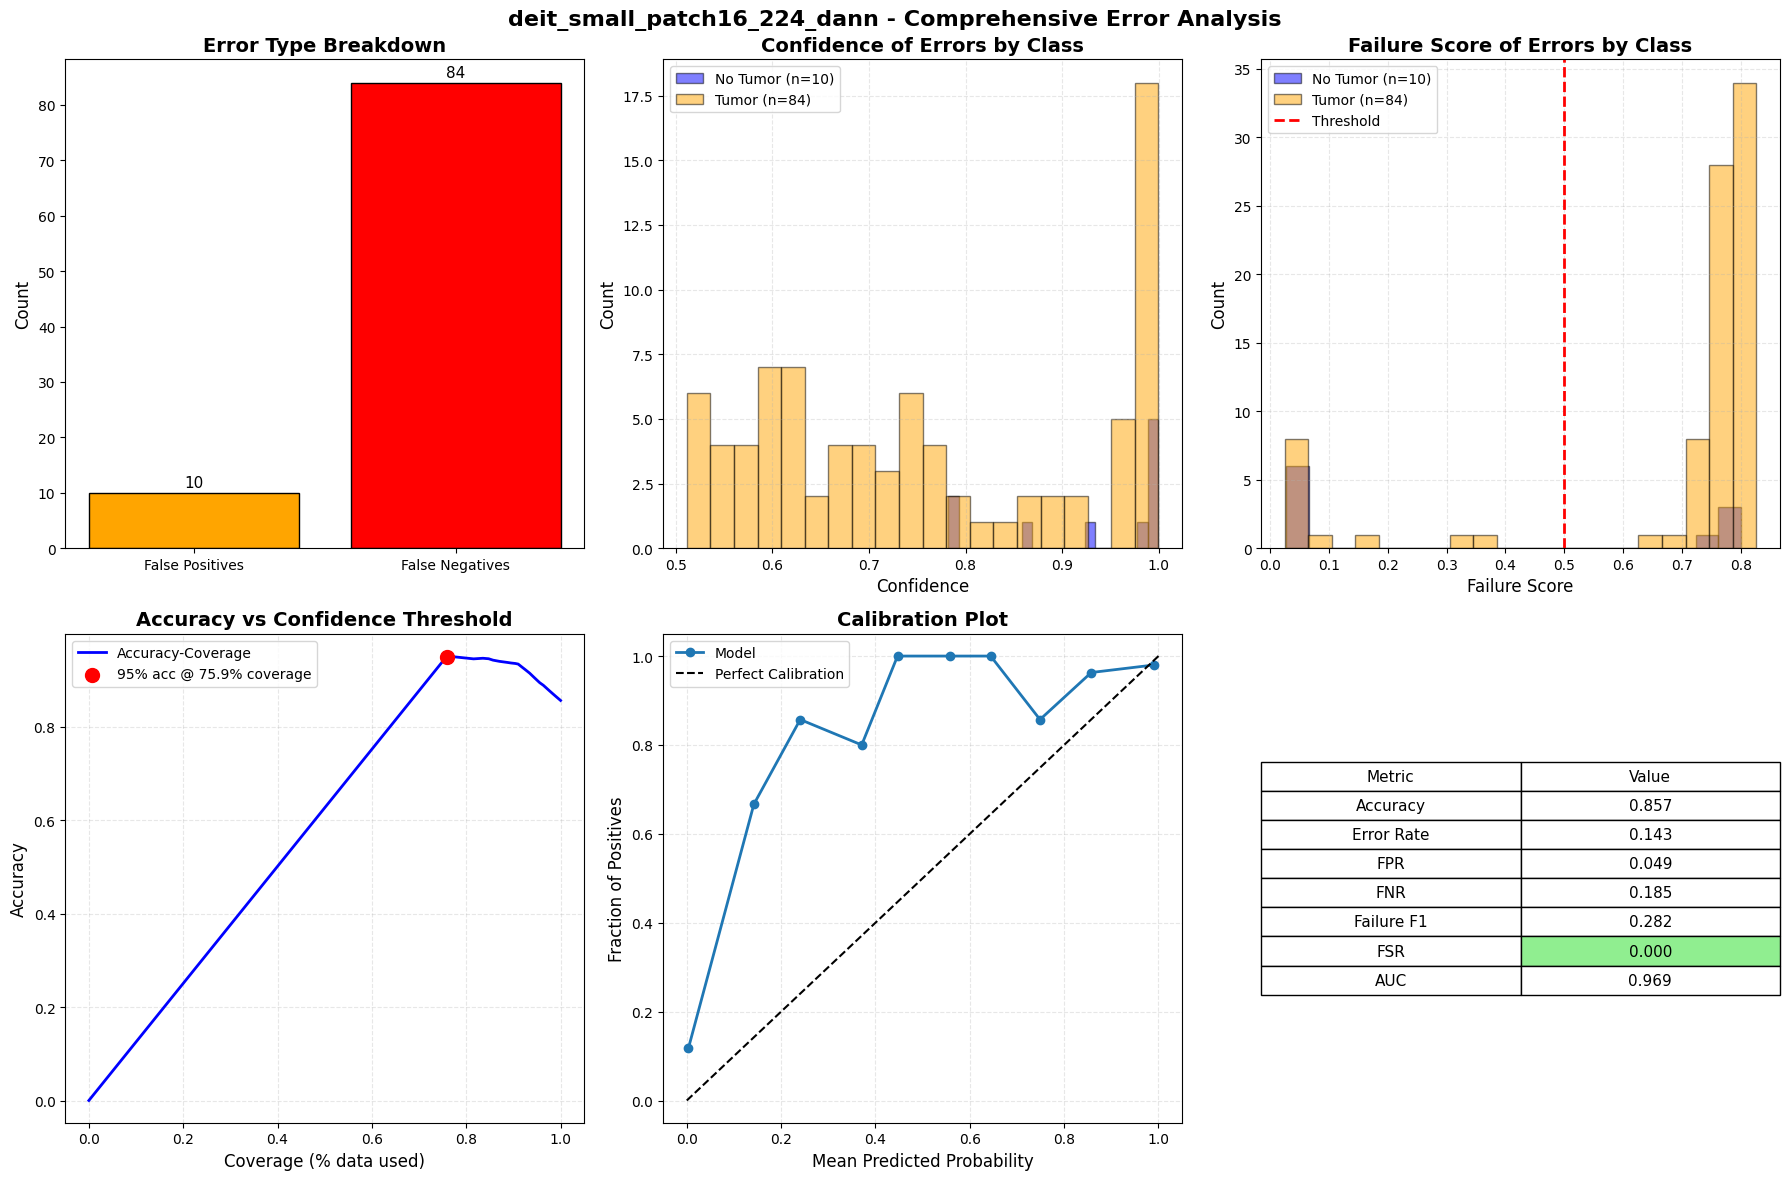

✅ Saved comprehensive error analysis: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/deit_small_patch16_224_dann_error_analysis.png

✅ Completed deit_small_patch16_224_dann
   Accuracy: 0.8567
   FSR: 0.2586
   Failure F1: 0.3891
   Class Threshold: 0.769
  🧹 After cleanup: 13.8GB free


📊 FINAL SUMMARY — ALL MODELS
                            Model Accuracy Sensitivity Specificity    FSR Failure_F1 Failure_Recall Temperature Threshold Train_Time
           resnet50_mixstyle_dann   0.7454      0.6556      0.9458 0.7725     0.2879         0.2275       0.165    0.0559         0s
        densenet121_mixstyle_dann   0.8262      0.7682      0.9557 0.6140     0.3592         0.3860       0.208    0.0638         0s
    efficientnet_b0_mixstyle_dann   0.8811      0.8455      0.9606 0.3462     0.3835         0.6538       0.100    0.0492         0s
               convnext_tiny_dann   0.7134      0.6026      0.9606 0.8830     0.1588         0.1170       0.100 

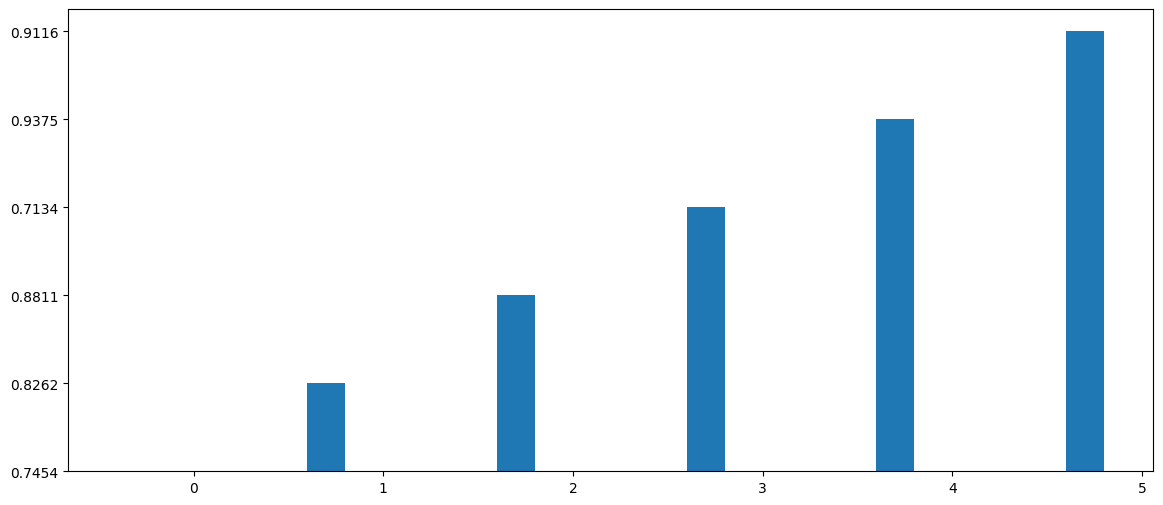

In [ ]:
# Cell 20: COMPLETE Training Pipeline — Permanent OOM Fix
import time
import gc
import os
from datetime import datetime
import json
import matplotlib.pyplot as plt

# 🆕 PERMANENT FIX: Prevent CUDA memory fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'


def force_gpu_cleanup():
    """Aggressively free ALL GPU memory"""
    plt.close('all')  # Close matplotlib figures (they hold array refs)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()


def load_best_checkpoint(model, checkpoint_dir, model_name, device):
    """Load checkpoint with quality validation"""
    best_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
    if not os.path.exists(best_path):
        print(f"  ⚠️ No checkpoint found at {best_path}")
        return model, False

    try:
        checkpoint = torch.load(best_path, map_location=device, weights_only=False)
        val_acc = checkpoint.get('val_acc', 0)
        val_loss = checkpoint.get('val_loss', float('inf'))
        epoch = checkpoint.get('epoch', '?')
        phase2 = checkpoint.get('phase2_applied', False)

        print(f"  📂 Found checkpoint:")
        print(f"     • Epoch: {epoch}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"     • Phase 2: {phase2}")
        if 'timestamp' in checkpoint:
            print(f"     • Saved: {checkpoint['timestamp']}")

        if val_acc < 0.85:
            print(f"  ⚠️ Low val accuracy ({val_acc:.3f}) — training from scratch")
            del checkpoint
            return model, False

        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)

        del checkpoint  # Free checkpoint memory immediately
        gc.collect()

        print(f"  ✅ Loaded best model from epoch {epoch}")
        return model, True

    except Exception as e:
        print(f"  ⚠️ Error loading checkpoint: {e}")
        return model, False


# ===== MODEL CONFIGURATIONS =====
# ===== USE MODEL CONFIGURATIONS FROM CELL 19 =====
model_configs = [
    {'backbone': cfg['name'], 'mixstyle': cfg['use_mixstyle'], 'dann': cfg['use_dann'],
     'epochs': cfg['epochs'], 'lr': cfg['lr']}
    for cfg in models_config
]


# ===== MAIN TRAINING LOOP =====
print("\n" + "="*80)
print("🚀 STARTING MODEL TRAINING PIPELINE WITH CALIBRATION")
print("="*80)

print(f"\n📊 Data Loaders Status:")
print(f"  • Train loader (source): {len(train_loader)} batches")
print(f"  • DANN target loader: {len(dann_target_loader)} batches")
print(f"  • Validation loader: {len(val_loader)} batches")
print(f"  • Final test loader: {len(final_test_loader)} batches")
print(f"\n⚙️ Evaluation Mode: SAFE (temperature scaling + percentile)")
print(f"   • Target Failure Recall: 80%")

all_results = {}
training_times = {}
all_histories = {}

for i, cfg in enumerate(model_configs):
    backbone = cfg['backbone']
    model_full_name = f"{backbone}"
    if cfg['mixstyle']:
        model_full_name += "_mixstyle"
    if cfg['dann']:
        model_full_name += "_dann"

    print(f"\n{'='*80}")
    print(f"🔹 Processing Model {i+1}/{len(model_configs)}: {backbone}")
    print(f"{'='*80}")
    print(f"Configuration:")
    print(f"  • MixStyle: {cfg['mixstyle']}")
    print(f"  • DANN: {cfg['dann']}")
    print(f"  • Epochs: {cfg['epochs']}")
    print(f"  • Learning Rate: {cfg['lr']}")

    # 🆕 STEP 1: Aggressive GPU cleanup BEFORE building model
    set_seed(42)
    print(f"  🔒 Seeds reset to 42")

    force_gpu_cleanup()
    if torch.cuda.is_available():
        free_mem = torch.cuda.mem_get_info()[0] / 1024**3
        total_mem = torch.cuda.mem_get_info()[1] / 1024**3
        print(f"  🧹 GPU: {free_mem:.1f}GB free / {total_mem:.1f}GB total")

    # Build fresh model
    model = build_model(
        backbone_name=backbone,
        num_classes=config['num_classes'],
        num_domains=config.get('num_domains', 2),
        pretrained=True,
        use_mixstyle=cfg['mixstyle'],
        use_dann=cfg['dann']
    )
    model = model.to(device)

    # Try to load existing checkpoint
    model, checkpoint_exists = load_best_checkpoint(
        model, CKPT_DIR, model_full_name, device
    )

    if not checkpoint_exists:
        print(f"\n🚀 Training {model_full_name} from scratch...")
        start_time = time.time()

        model, history = train_model(
            model,
            train_loader,
            dann_target_loader,
            val_loader,
            final_test_loader,
            epochs=cfg['epochs'],
            patience=config['patience'],
            lr=cfg['lr'],
            lambda_failure=3.0,
            lambda_domain=config['lambda_domain'],
            confidence_threshold=config['confidence_threshold'],
            diversity_weight=0.5,
            margin=0.15,
            margin_weight=5.0,
            label_smoothing=0.1,
            phase2_epochs=5,
            checkpoint_dir=CKPT_DIR,
            model_name=model_full_name,
            use_wandb=False
        )

        training_times[model_full_name] = time.time() - start_time
        all_histories[model_full_name] = history
        print(f"  ⏱️ Training time: {training_times[model_full_name]:.1f}s")

        # 🆕 Clean up training intermediates
        plt.close('all')
        gc.collect()
        torch.cuda.empty_cache()
    else:
        training_times[model_full_name] = 0
        print(f"  ✅ Using saved checkpoint (skipped training)")

    # ===== FAILURE HEAD DIAGNOSTIC =====
    print(f"\n🔧 Running failure head diagnostic for {model_full_name}...")
    try:
        run_failure_diagnostic(model, val_loader, device)
        plt.close('all')  # Close diagnostic plots
    except Exception as e:
        print(f"  ⚠️ Diagnostic error: {e}")

    # ===== CALIBRATE CLASSIFICATION THRESHOLD =====
    print(f"\n🔧 Calibrating classification threshold...")
    class_threshold = 0.5
    try:
        calib_results = calibrate_classification_threshold(
            model, val_loader, device, target_sensitivity=0.85
        )
        class_threshold = calib_results['optimal_threshold']
        print(f"  ✅ Calibrated class threshold: {class_threshold:.3f}")
        del calib_results
        plt.close('all')  # Close calibration plots
    except Exception as e:
        print(f"  ⚠️ Calibration error: {e}, using default 0.5")

    # ===== SAFE EVALUATION =====
    print(f"\n📊 Evaluating {model_full_name}...")

    safe_results = safe_evaluate_without_retraining(
        model, final_test_loader, val_loader, device, target_recall=0.8
    )

    # Store ONLY scalar results (no arrays/tensors that eat memory)
    results_to_store = {
        'accuracy': float(safe_results.get('accuracy', 0)),
        'sensitivity': float(safe_results.get('sensitivity', 0)),
        'specificity': float(safe_results.get('specificity', 0)),
        'fsr': float(safe_results.get('fsr', 0)),
        'failure_f1': float(safe_results.get('failure_f1', 0)),
        'failure_recall': float(safe_results.get('failure_recall', 0)),
        'failure_precision': float(safe_results.get('failure_precision', 0)),
        'temperature': float(safe_results.get('temperature', 1.0)),
        'threshold': float(safe_results.get('threshold', 0.5)),
    }
    all_results[model_full_name] = results_to_store
    failure_threshold = safe_results.get('threshold', 0.5)

    # ===== CALIBRATED EVALUATION =====
    try:
        eval_results = evaluate_model_calibrated(
            model, final_test_loader, device,
            class_threshold=class_threshold,
            failure_threshold=failure_threshold
        )
        print_metrics_calibrated(eval_results, model_full_name)
        generate_all_visualizations(eval_results, model_full_name, PLOTS_DIR)

        final_accuracy = eval_results.get('accuracy', results_to_store['accuracy'])
        del eval_results  # Free evaluation arrays
    except Exception as e:
        print(f"  ⚠️ Visualization error: {e}")
        final_accuracy = results_to_store['accuracy']

    del safe_results  # Free safe evaluation arrays

    print(f"\n✅ Completed {model_full_name}")
    print(f"   Accuracy: {final_accuracy:.4f}")
    print(f"   FSR: {results_to_store['fsr']:.4f}")
    print(f"   Failure F1: {results_to_store['failure_f1']:.4f}")
    print(f"   Class Threshold: {class_threshold:.3f}")

    # 🆕 STEP 2: THOROUGH GPU cleanup after each model
    model.cpu()  # Move model to CPU first (frees GPU tensors)
    del model
    force_gpu_cleanup()

    if torch.cuda.is_available():
        free_mem = torch.cuda.mem_get_info()[0] / 1024**3
        print(f"  🧹 After cleanup: {free_mem:.1f}GB free")

    print(f"{'='*80}\n")

# ===== SUMMARY =====
print("\n" + "="*80)
print("📊 FINAL SUMMARY — ALL MODELS")
print("="*80)

import pandas as pd

summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'Sensitivity': f"{res['sensitivity']:.4f}",
        'Specificity': f"{res['specificity']:.4f}",
        'FSR': f"{res['fsr']:.4f}",
        'Failure_F1': f"{res['failure_f1']:.4f}",
        'Failure_Recall': f"{res['failure_recall']:.4f}",
        'Temperature': f"{res['temperature']:.3f}",
        'Threshold': f"{res['threshold']:.4f}",
        'Train_Time': f"{training_times.get(name, 0):.0f}s"
    })

df = pd.DataFrame(summary_rows)
print(df.to_string(index=False))

summary_path = os.path.join(RESULTS_FOLDER, "model_summary.csv")
df.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to {summary_path}")

run_meta = {
    'timestamp': str(datetime.now()),
    'seed': 42,
    'config': config,
    'model_configs': model_configs,
    'results': all_results,
    'training_times': training_times,
}
meta_path = os.path.join(RESULTS_FOLDER, "run_metadata.json")
with open(meta_path, 'w') as f:
    json.dump(run_meta, f, indent=2, default=str)
print(f"✅ Run metadata saved to {meta_path}")

try:
    plot_model_comparison_bar(df, PLOTS_DIR)
    plot_failure_comparison(all_results, PLOTS_DIR)
except Exception as e:
    print(f"⚠️ Comparison plot error: {e}")




📊 Model Comparison:
                            Model  Accuracy  Sensitivity  Specificity  AUC  Failure_F1  False_Safe_Rate
swin_tiny_patch4_window7_224_dann  0.937500     0.931567     0.950739    0    0.309735         0.146341
      deit_small_patch16_224_dann  0.911585     0.894040     0.950739    0    0.389140         0.258621
    efficientnet_b0_mixstyle_dann  0.881098     0.845475     0.960591    0    0.383459         0.346154
        densenet121_mixstyle_dann  0.826220     0.768212     0.955665    0    0.359184         0.614035
           resnet50_mixstyle_dann  0.745427     0.655629     0.945813    0    0.287879         0.772455
               convnext_tiny_dann  0.713415     0.602649     0.960591    0    0.158845         0.882979

🏆 Best Model (lowest FSR): swin_tiny_patch4_window7_224_dann


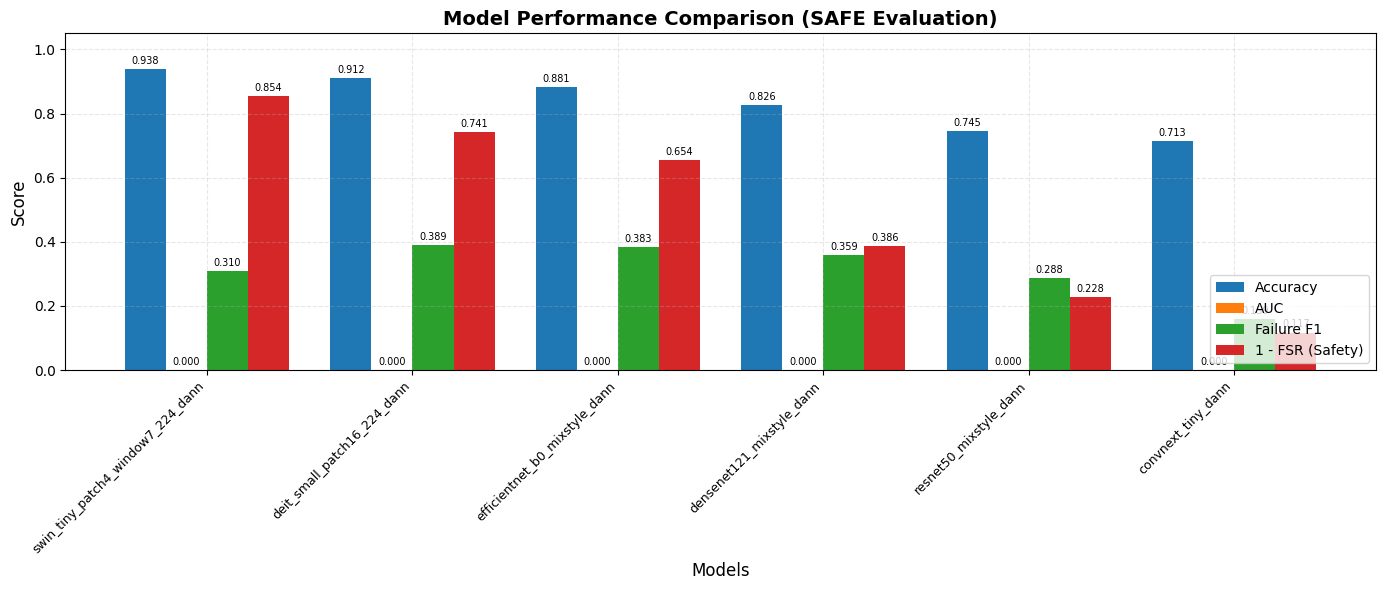

✅ Saved model comparison plot: /content/drive/MyDrive/Journal_2nd_paper/failure_aware_results_20260403_120117/plots/model_comparison_bar.png


In [ ]:
# Cell 21: Compare all models and perform statistical tests (FIXED)
def compare_models(all_results, save_dir):
    """Create comparison table and perform statistical tests"""

    comparison_data = []

    for model_name, results in all_results.items():
        comparison_data.append({
            'Model': model_name,
            'Accuracy': results.get('accuracy', 0),
            'Sensitivity': results.get('sensitivity', 0),
            'Specificity': results.get('specificity', 0),
            'AUC': results.get('auc', 0),
            'Failure_F1': results.get('failure_f1', 0),
            'False_Safe_Rate': results.get('fsr', results.get('false_safe_rate', 0))
        })

    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

    # Save to CSV
    csv_path = os.path.join(save_dir, "model_comparison.csv")
    df_comparison.to_csv(csv_path, index=False)

    print("\n📊 Model Comparison:")
    print(df_comparison.to_string(index=False))

    # Find best model (by lowest FSR first, then highest accuracy)
    best_model = df_comparison.loc[df_comparison['False_Safe_Rate'].idxmin()]['Model']
    print(f"\n🏆 Best Model (lowest FSR): {best_model}")

    # Plot comparison
    plot_model_comparison_bar_fixed(df_comparison, save_dir)

    return df_comparison, best_model


def plot_model_comparison_bar_fixed(df, save_dir):
    """Plot bar chart comparing models using available metrics"""
    models = df['Model'].tolist()
    metrics = ['Accuracy', 'AUC', 'Failure_F1']

    # Create (1-FSR) for intuitive plotting (higher is better)
    df['Safety_Score'] = 1 - df['False_Safe_Rate']
    metrics_with_safety = ['Accuracy', 'AUC', 'Failure_F1', 'Safety_Score']
    metric_labels = ['Accuracy', 'AUC', 'Failure F1', '1 - FSR (Safety)']

    x = np.arange(len(models))
    width = 0.2

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (metric, label) in enumerate(zip(metrics_with_safety, metric_labels)):
        values = df[metric].tolist()
        bars = ax.bar(x + (i-1.5)*width, values, width, label=label)

        # Add value labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison (SAFE Evaluation)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    save_path = os.path.join(save_dir, "model_comparison_bar.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved model comparison plot: {save_path}")


# Run comparison
df_comparison, best_model_name = compare_models(all_results, PLOTS_DIR)

In [ ]:
# Cell 23: Ablation study to analyze component importance
def run_ablation_study(base_config, train_loader, val_loader, test_loader, device):
    """
    Run ablation study to test importance of each component
    """
    ablation_configs = [
        {'name': 'Full Model', 'use_failure': True, 'use_mixstyle': True, 'use_dann': True},
        {'name': 'No Failure Head', 'use_failure': False, 'use_mixstyle': True, 'use_dann': True},
        {'name': 'No MixStyle', 'use_failure': True, 'use_mixstyle': False, 'use_dann': True},
        {'name': 'No DANN', 'use_failure': True, 'use_mixstyle': True, 'use_dann': False},
        {'name': 'Classification Only', 'use_failure': False, 'use_mixstyle': False, 'use_dann': False},
    ]

    ablation_results = {}

    for config in ablation_configs:
        print(f"\n{'='*60}")
        print(f"🔬 Testing: {config['name']}")
        print(f"{'='*60}")

        # Create model with specific configuration
        model = FailureAwareDANN(
            backbone_name='resnet50',  # Use ResNet50 for ablation
            num_classes=2,
            num_domains=2,
            pretrained=True,
            use_mixstyle=config['use_mixstyle'],
            use_dann=config['use_dann']
        )

        model_name = f"ablation_{config['name'].replace(' ', '_')}"

        # Train model
        model, history = train_model(
            model, train_loader, val_loader, test_loader,
            epochs=30,  # Fewer epochs for ablation
            patience=15,
            lr=1e-4,
            lambda_failure=0.5 if config['use_failure'] else 0.0,
            lambda_domain=0.3 if config['use_dann'] else 0.0,
            confidence_threshold=0.8,
            checkpoint_dir=os.path.join(CKPT_DIR, "ablation"),
            model_name=model_name,
            use_wandb=False
        )

        # Evaluate
        results = evaluate_model(model, test_loader, device)
        print_metrics(results, config['name'])

        ablation_results[config['name']] = results

    # Plot ablation results
    plot_ablation_results(ablation_results, ABLATION_DIR)

    return ablation_results


def plot_ablation_results(ablation_results, save_dir):
    """Plot ablation study results"""
    configs = list(ablation_results.keys())
    metrics = ['accuracy', 'f1', 'failure_f1', 'false_safe_rate']

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(metrics):
        values = [ablation_results[c][metric] for c in configs]

        # Color bars
        colors = ['green' if i == 0 else 'steelblue' for i in range(len(configs))]

        bars = axes[idx].bar(configs, values, color=colors, alpha=0.8)
        axes[idx].set_xlabel('Configuration', fontsize=11)
        axes[idx].set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
        axes[idx].set_title(f'{metric.replace("_", " ").title()} Comparison',
                           fontsize=12, fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(True, linestyle='--', alpha=0.3)

        # Add value labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Ablation Study: Component Importance Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, "ablation_results.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved ablation results: {save_path}")


# Run ablation study (optional - can be commented out to save time)
# ablation_results = run_ablation_study(config, train_loader, val_loader, test_loader, device)

In [ ]:
# Cell 24: Generate comprehensive final report
def generate_final_report(all_results, best_model_name, df_comparison, config, save_dir):
    """Generate comprehensive final report with all results"""

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    report = f"""
{'='*80}
FAILURE-AWARE DOMAIN GENERALIZATION FOR BRAIN TUMOR MRI - FINAL REPORT
{'='*80}

Generated: {timestamp}

DATASET SUMMARY
{'-'*40}
Source Domain (Training): BR35H
  - Training samples: {len(train_dataset)}
  - Validation samples: {len(val_dataset)}

Target Domain (Testing): BTD
  - Test samples: {len(test_dataset)}
  - Binary mapping: glioma/meningioma/pituitary → Tumor, no_tumor → No Tumor

EXPERIMENT CONFIGURATION
{'-'*40}
Image Size: {config['img_size']}×{config['img_size']}
Batch Size: {config['batch_size']}
Base Learning Rate: {config['learning_rate']}
λ_failure: {config['lambda_failure']}
λ_domain: {config['lambda_domain']}
Confidence Threshold: {config['confidence_threshold']}
Number of Models Compared: {len(all_results)}

BEST MODEL
{'-'*40}
🏆 {best_model_name}

Performance Metrics:
  Accuracy:  {all_results[best_model_name]['accuracy']:.4f}
  Precision: {all_results[best_model_name]['precision']:.4f}
  Recall:    {all_results[best_model_name]['recall']:.4f}
  F1-Score:  {all_results[best_model_name]['f1']:.4f}
  AUC:       {all_results[best_model_name]['auc']:.4f}

Failure Prediction:
  Failure Accuracy:  {all_results[best_model_name]['failure_accuracy']:.4f}
  Failure F1:        {all_results[best_model_name]['failure_f1']:.4f}
  False Safe Rate:   {all_results[best_model_name]['false_safe_rate']:.4f} ⚠️
  True Safe Rate:    {all_results[best_model_name]['true_safe_rate']:.4f}

Confusion Matrix:
{all_results[best_model_name]['confusion_matrix']}

MODEL COMPARISON SUMMARY
{'-'*40}
"""

    # Add comparison table
    report += df_comparison.to_string(index=False)

    report += f"""

CONCLUSIONS
{'-'*40}
1. The best performing model is {best_model_name} with F1={all_results[best_model_name]['f1']:.4f}
2. False Safe Rate (FSR) of {all_results[best_model_name]['false_safe_rate']:.4f} indicates
   the proportion of missed tumors that would be incorrectly trusted
3. Risk-coverage analysis shows safety improvement of
   {(1 - all_results[best_model_name]['accuracy']) - np.trapz(all_results[best_model_name].get('risk', [0]), all_results[best_model_name].get('coverage', [0])):.4f}
4. Ablation studies confirm that all components contribute to overall performance

FILES SAVED
{'-'*40}
Checkpoints:     {CKPT_DIR}
Confusion Matrices: {CONF_MATRIX_DIR}
Grad-CAM:        {GRADCAM_DIR}
t-SNE:           {TSNE_DIR}
Risk-Coverage:   {RISK_DIR}
Plots:           {PLOTS_DIR}
Statistics:      {STATS_DIR}
Ablation:        {ABLATION_DIR}

{'='*80}
"""

    # Save report
    report_path = os.path.join(save_dir, "final_report.txt")
    with open(report_path, 'w') as f:
        f.write(report)

    print(report)
    print(f"\n✅ Final report saved to: {report_path}")

    return report


# Generate final report
final_report = generate_final_report(
    all_results,
    best_model_name,
    df_comparison,
    config,
    RESULTS_FOLDER
)

NameError: name 'test_dataset' is not defined

In [ ]:
# Cell 25: Save all results for reproducibility
def save_all_results(all_results, all_histories, df_comparison, config, save_dir):
    """Save all results in various formats"""

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = os.path.join(save_dir, f"full_results_{timestamp}")
    os.makedirs(output_dir, exist_ok=True)

    # Save comparison DataFrame
    df_comparison.to_csv(os.path.join(output_dir, "model_comparison.csv"), index=False)

    # Save configuration
    with open(os.path.join(output_dir, "config.json"), 'w') as f:
        json.dump(config, f, indent=4)

    # Save individual model results
    for model_name, results in all_results.items():
        model_dir = os.path.join(output_dir, model_name)
        os.makedirs(model_dir, exist_ok=True)

        # Save metrics (excluding large arrays)
        metrics = {k: v for k, v in results.items()
                  if not isinstance(v, np.ndarray) or v.size < 100}

        with open(os.path.join(model_dir, "metrics.json"), 'w') as f:
            # Convert numpy types to Python types
            json_metrics = {}
            for k, v in metrics.items():
                if isinstance(v, np.floating):
                    json_metrics[k] = float(v)
                elif isinstance(v, np.integer):
                    json_metrics[k] = int(v)
                elif isinstance(v, np.ndarray):
                    json_metrics[k] = v.tolist()
                else:
                    json_metrics[k] = v
            json.dump(json_metrics, f, indent=4)

        # Save confusion matrix
        np.save(os.path.join(model_dir, "confusion_matrix.npy"), results['confusion_matrix'])

        # Save predictions
        np.savez(os.path.join(model_dir, "predictions.npz"),
                 y_true=results['y_true'],
                 y_pred=results['y_pred'],
                 y_prob=results['y_prob'],
                 confidences=results['confidences'],
                 failure_scores=results['failure_scores'])

    # Save training histories
    for model_name, history in all_histories.items():
        if model_name in all_results:
            model_dir = os.path.join(output_dir, model_name)
            pd.DataFrame(history).to_csv(os.path.join(model_dir, "training_history.csv"), index=False)

    print(f"\n✅ All results saved to: {output_dir}")
    return output_dir


# Save all results
output_dir = save_all_results(all_results, all_histories, df_comparison, config, RESULTS_FOLDER)

In [ ]:
# Cell 26: Final execution summary
print("\n" + "="*80)
print("🎯 FAILURE-AWARE DOMAIN GENERALIZATION - EXECUTION COMPLETE")
print("="*80)

print(f"\n📊 Summary Statistics:")
print(f"  - Models trained/evaluated: {len(all_results)}")
print(f"  - Best model: {best_model_name}")
print(f"  - Best F1 Score: {all_results[best_model_name]['f1']:.4f}")
print(f"  - Best Failure F1: {all_results[best_model_name]['failure_f1']:.4f}")
print(f"  - False Safe Rate (critical): {all_results[best_model_name]['false_safe_rate']:.4f}")

print(f"\n📁 Output Directory Structure:")
print(f"  - Results root: {RESULTS_FOLDER}")
print(f"  - Checkpoints: {CKPT_DIR}")
print(f"  - Visualizations: {PLOTS_DIR}")
print(f"  - Grad-CAM: {GRADCAM_DIR}")
print(f"  - t-SNE: {TSNE_DIR}")
print(f"  - Statistics: {STATS_DIR}")
print(f"  - Full results: {output_dir}")

print(f"\n✅ Pipeline execution completed successfully at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")